dane są pozmieniane ale nie są przygotowane do treningu (poprzerzucać wartości kolumn do meczy bo jest teraz wiersz z emczem-kursami na niego i wynikiem meczu i statystyk po tym meczu)

# 1. Initial setup

Import of libraries, global parameters.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
import json

In [2]:
df1 = pd.read_csv(r"..\data\extracted_data\20_21_final.csv")
df2 = pd.read_csv(r"..\data\extracted_data\21_22_final.csv")
df3 = pd.read_csv(r"..\data\extracted_data\22_23_final.csv")
df4 = pd.read_csv(r"..\data\extracted_data\23_24_final.csv")

df_list = [df1, df2, df3, df4]

In [3]:
joined_df = pd.concat(df_list, ignore_index=True)

# 2. Data exploration

## General overview

In this chapter, we take an initial look at the football match data that forms the foundation of our analysis. We'll explore the structure of the dataset, review the types of information it contains, and highlight key statistics. This overview sets the stage for deeper analytical work in the following chapters by helping us understand the basic characteristics and quality of the data.

Leagues in the collected dataset

In [96]:
for league in joined_df['league'].unique():
    print(f"{league}: " , joined_df.loc[joined_df['league'] == league].shape[0])

Tipico Bundesliga:  192
PKO BP Ekstraklasa:  1158
Eredivisie:  1224
Jupiler League:  1302
LaLiga:  1520
Ligue 1:  1446
Premier Liga:  960
Premiership:  912
Primeira Liga:  306
Serie A:  1520
Super League:  768
Super Lig:  1522
Bundesliga:  576
Liga Portugal:  918


In [97]:
for df in df_list:
    for league in df['league'].unique():
        print(f"{league}: " , df.loc[df['league'] == league].shape[0])
    print('==============')

Tipico Bundesliga:  192
PKO BP Ekstraklasa:  240
Eredivisie:  306
Jupiler League:  330
LaLiga:  380
Ligue 1:  380
Premier Liga:  240
Premiership:  228
Primeira Liga:  306
Serie A:  380
Super League:  180
Super Lig:  420
Bundesliga:  192
PKO BP Ekstraklasa:  306
Eredivisie:  306
Jupiler League:  330
LaLiga:  380
Ligue 1:  380
Premier Liga:  240
Premiership:  228
Liga Portugal:  306
Serie A:  380
Super League:  180
Super Lig:  380
Bundesliga:  192
PKO BP Ekstraklasa:  306
Eredivisie:  306
Jupiler League:  330
LaLiga:  380
Ligue 1:  380
Premier Liga:  240
Premiership:  228
Liga Portugal:  306
Serie A:  380
Super League:  180
Super Lig:  342
Bundesliga:  192
PKO BP Ekstraklasa:  306
Eredivisie:  306
Jupiler League:  312
LaLiga:  380
Ligue 1:  306
Premier Liga:  240
Premiership:  228
Liga Portugal:  306
Serie A:  380
Super League:  228
Super Lig:  380


Dataset characteristics

In [98]:
season_labels = ['20_21', '21_22', '22_23', '23_24']
total_matches = sum(len(df) for df in df_list)
total_columns = df1.shape[1]
leagues = df1['league'].unique()

print("="*60)
print("Data characteristics")
print("="*60)
print(f"Number of all matches: {total_matches}")
print(f"Number of seasons: {len(df_list)}")
print(f"Number of leagues: {len(leagues)}")
print(f"Leagues: {', '.join(leagues)}")
print(f"Column number: {total_columns}")
print("\nSchedule of matches per season:")
for label, df in zip(season_labels, df_list):
    print(f"  {label}: {len(df)} matches")

Data characteristics
Number of all matches: 14324
Number of seasons: 4
Number of leagues: 12
Leagues: Tipico Bundesliga, PKO BP Ekstraklasa, Eredivisie, Jupiler League, LaLiga, Ligue 1, Premier Liga, Premiership, Primeira Liga, Serie A, Super League, Super Lig
Column number: 113

Schedule of matches per season:
  20_21: 3582 matches
  21_22: 3608 matches
  22_23: 3570 matches
  23_24: 3564 matches


Matches per season and league

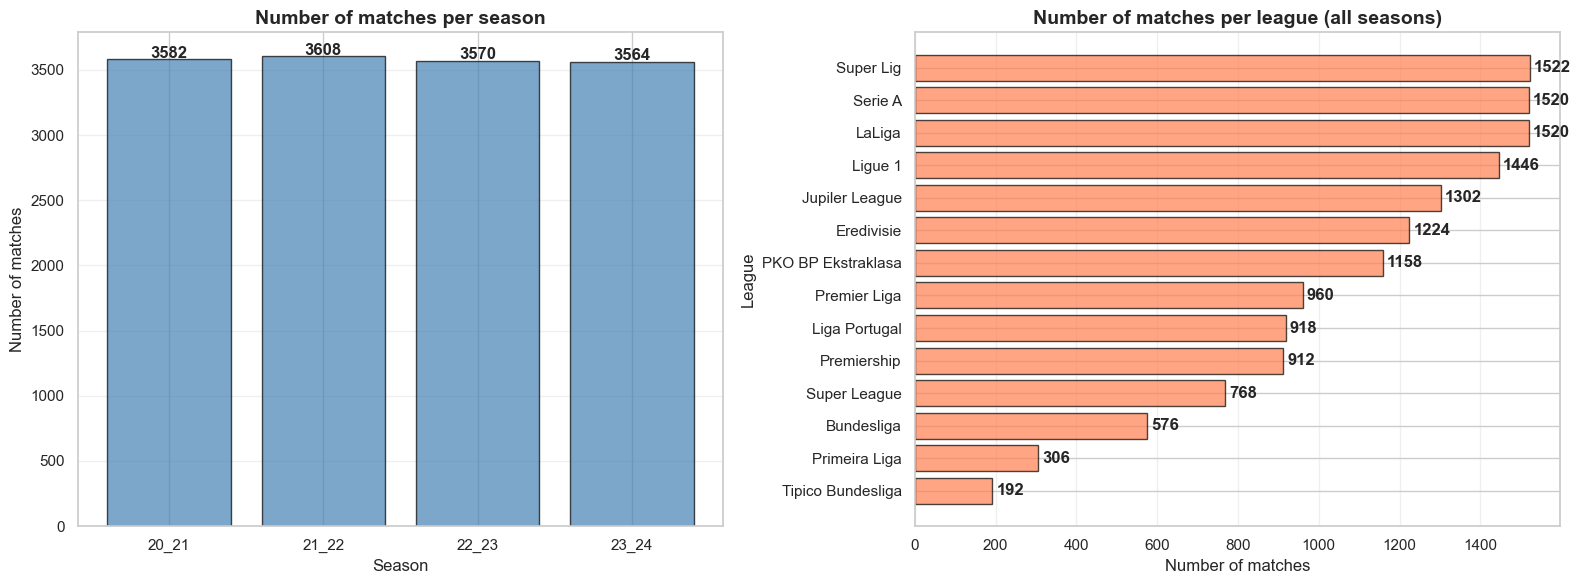

In [99]:
# Visualization: number of matches per season and league
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Matches per season
season_counts = [len(df) for df in df_list]
axes[0].bar(season_labels, season_counts, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Number of matches per season', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Season', fontsize=12)
axes[0].set_ylabel('Number of matches', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(season_counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Plot 2: Matches per league (aggregated across all seasons)
all_leagues = pd.concat([df['league'] for df in df_list])
league_counts = all_leagues.value_counts().sort_values(ascending=True)
axes[1].barh(league_counts.index, league_counts.values, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Number of matches per league (all seasons)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of matches', fontsize=12)
axes[1].set_ylabel('League', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
for i, (idx, v) in enumerate(league_counts.items()):
    axes[1].text(v + 10, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Primeira Liga seems suspicious so we need take a closer look

In [100]:
joined_df['team_1'].loc[joined_df['league'] == 'Primeira Liga'].unique()
joined_df['team_1'].loc[joined_df['league'] == 'Tipico Bundesliga'].unique()

array(['RB Salzburg', 'Rapid Wiedeń', 'Wolfsberger', 'Admira', 'Ried',
       'St. Polten', 'LASK', 'Sturm Graz', 'Tirol', 'Altach',
       'Austria Wiedeń', 'Hartberg', 'SK Rapid'], dtype=object)

After comparing with other leagues it seems that Pripeira Liga is Portugal league. So we perform hotfix

In [101]:
for df in df_list:
    df.loc[df['league'] == 'Primeira Liga', 'league'] = 'Liga Portugal'
    df.loc[df['league'] == 'Bundesliga', 'league'] = 'Tipico Bundesliga'

We should ensure there is consistent naming in the teams - best suited will be plot, rather than numbers to compare (at this stage)

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


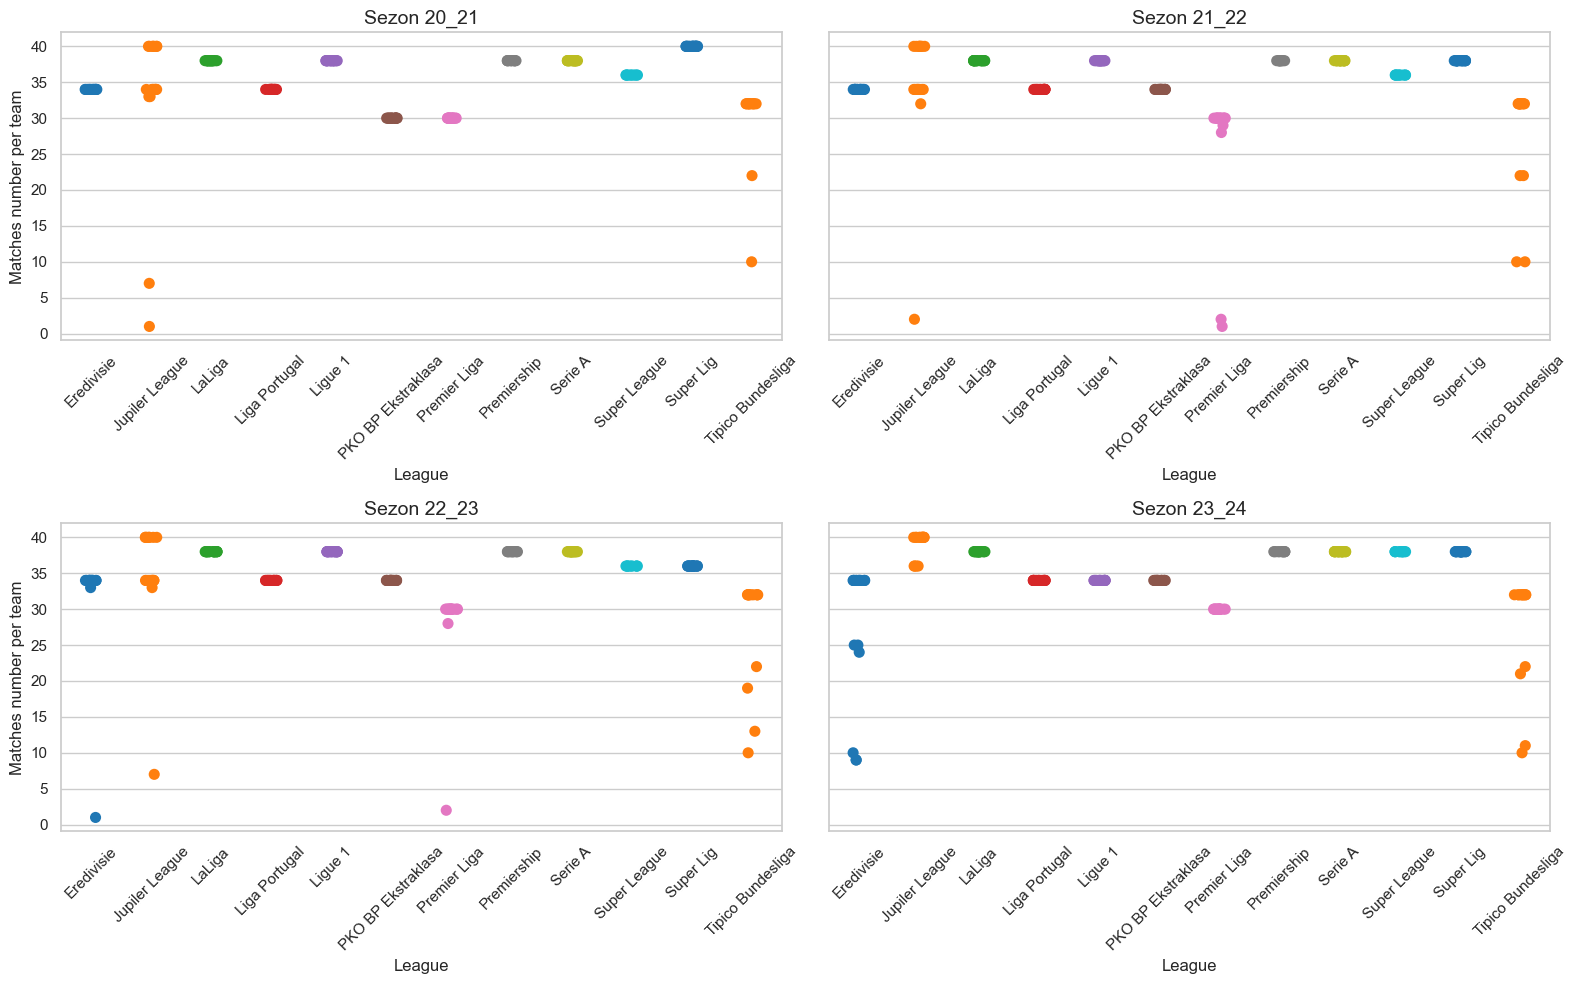

In [102]:
sns.set(style="whitegrid")

num_seasons = len(df_list)
fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True)
axes = axes.flatten()

for i, df in enumerate(df_list):
    all_results = []

    for league_name, group in df.groupby('league'):
        teams = pd.concat([group['team_1'], group['team_2']])
        counts = teams.value_counts().reset_index()
        counts.columns = ['team', 'count']
        counts['league'] = league_name
        all_results.append(counts)

    season_df = pd.concat(all_results, ignore_index=True)

    sns.stripplot(
        x='league', y='count', data=season_df,
        jitter=True, size=8, palette="tab10", ax=axes[i]
    )

    axes[i].set_title(f'Sezon {season_labels[i]}', fontsize=14)
    axes[i].set_xlabel('League', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    if i % 2 == 0:
        axes[i].set_ylabel('Matches number per team', fontsize=12)
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

non-numeric columns include:
-	 match_id
-	 date
-	 league
-	 team_X
-    possession (due to % symbol at the end)
-	 team_X_formation
-	 team_X_line_Y

Note X represents 1 and 2, Y ranges from 1 to 5

In [103]:
for col in joined_df.columns:
    if joined_df[col].dtype != float: 
        print('\t', col)

	 match_id
	 date
	 league
	 team_1
	 team_2
	 possession_1
	 possession_2
	 team_1_formation
	 team_2_formation
	 team_1_line_1
	 team_1_line_2
	 team_1_line_3
	 team_2_line_1
	 team_2_line_2
	 team_2_line_3
	 team_2_line_4
	 team_1_line_4
	 team_1_line_5
	 team_2_line_5


In [104]:
home_wins = ((joined_df['goals_1'] > joined_df['goals_2'])).sum()
draws = ((joined_df['goals_1'] == joined_df['goals_2'])).sum()
away_wins = ((joined_df['goals_1'] < joined_df['goals_2'])).sum()

total_matches = len(joined_df)

print(f"Total matches:     {total_matches}")
print(f"Home wins:         {home_wins}")
print(f"Draws:             {draws}")
print(f"Away wins:         {away_wins}")


Total matches:     14324
Home wins:         6142
Draws:             3667
Away wins:         4515


We have access to standard match statistics:

In [105]:
joined_df[[col for col in joined_df.columns if not (col.startswith('bet_') or col.startswith('team_'))]].columns

Index(['match_id', 'date', 'league', 'turn', 'goals_1', 'goals_2', 'winner',
       'possession_1', 'possession_2', 'goal_chances_1', 'goal_chances_2',
       'shots_on_target_1', 'shots_on_target_2', 'shots_off_target_1',
       'shots_off_target_2', 'blocked_shots_1', 'blocked_shots_2',
       'offsides_1', 'offsides_2', 'goalkeeper_saves_1', 'goalkeeper_saves_2',
       'fouls_1', 'fouls_2', 'attacks_1', 'attacks_2', 'dangerous_attacks_1',
       'dangerous_attacks_2', 'red_cards_1', 'red_cards_2', 'free_kicks_1',
       'free_kicks_2', 'throw_ins_1', 'throw_ins_2', 'expected_goals_1',
       'expected_goals_2'],
      dtype='object')

In [106]:
joined_df[[col for col in joined_df.columns if not (col.startswith('bet_') or col.startswith('team_') or col == 'turn')]].describe().round(2)

,goals_1,goals_2,winner,goal_chances_1,goal_chances_2,shots_on_target_1,shots_on_target_2,shots_off_target_1,shots_off_target_2,blocked_shots_1,...,dangerous_attacks_1,dangerous_attacks_2,red_cards_1,red_cards_2,free_kicks_1,free_kicks_2,throw_ins_1,throw_ins_2,expected_goals_1,expected_goals_2
count,14324.00,14324.00,14324.00,14287.00,14287.00,14287.00,14287.00,14287.00,14287.00,12086.00,...,10906.00,10906.00,2923.00,2923.00,10509.00,10509.00,9102.00,9102.00,4116.00,4116.00
mean,1.52,1.25,1.06,13.36,11.30,4.78,4.01,5.73,4.89,3.36,...,54.25,47.55,0.54,0.61,13.89,13.96,20.98,20.07,1.46,1.17
std,1.29,1.17,0.75,5.40,4.89,2.59,2.38,3.16,2.85,2.31,...,20.96,19.62,0.57,0.57,4.78,4.72,6.33,6.14,0.86,0.76
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,9.00,8.00,3.00,2.00,3.00,3.00,2.00,...,39.00,33.00,0.00,0.00,11.00,11.00,17.00,16.00,0.82,0.60
50%,1.00,1.00,1.00,13.00,11.00,4.00,4.00,5.00,4.00,3.00,...,52.00,45.00,1.00,1.00,13.00,14.00,21.00,20.00,1.32,1.03
75%,2.00,2.00,2.00,17.00,14.00,6.00,5.00,7.00,6.00,5.00,...,67.00,59.00,1.00,1.00,17.00,17.00,25.00,24.00,1.94,1.58
max,9.00,13.00,2.00,46.00,45.00,23.00,23.00,29.00,25.00,18.00,...,163.00,171.00,3.00,3.00,45.00,39.00,51.00,53.00,6.41,5.61


In [ ]:
temp_df = pd.concat(df_list, ignore_index=True)

temp_df["Goals_total"] = temp_df["goals_1"] + temp_df["goals_2"]
temp_df["Shots_on_target_total"] = temp_df["shots_on_target_1"] + temp_df["shots_on_target_2"]
temp_df["Blocked_shots_total"] = temp_df["blocked_shots_1"] + temp_df["blocked_shots_2"]
temp_df["Goalkeeper_saves_total"] = temp_df["goalkeeper_saves_1"] + temp_df["goalkeeper_saves_2"]
temp_df["Attacks_total"] = temp_df["attacks_1"] + temp_df["attacks_2"]
temp_df["Dangerous_attacks_total"] = temp_df["dangerous_attacks_1"] + temp_df["dangerous_attacks_2"]
temp_df["Expected_goals_total"] = temp_df["expected_goals_1"] + temp_df["expected_goals_2"]



C:\Users\Prezes\AppData\Local\Temp\ipykernel_11680\3448750942.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp_df["Goals_total"] = temp_df["goals_1"] + temp_df["goals_2"]
C:\Users\Prezes\AppData\Local\Temp\ipykernel_11680\3448750942.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp_df["Shots_on_target_total"] = temp_df["shots_on_target_1"] + temp_df["shots_on_target_2"]
C:\Users\Prezes\AppData\Local\Temp\ipykernel_11680\3448750942.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resul

In [8]:
temp_df[[
    "Goals_total",
    "Shots_on_target_total",
    "Blocked_shots_total",
    "Goalkeeper_saves_total",
    "Attacks_total",
    "Dangerous_attacks_total",
    "Expected_goals_total"
]].describe()

,Goals_total,Shots_on_target_total,Blocked_shots_total,Goalkeeper_saves_total,Attacks_total,Dangerous_attacks_total,Expected_goals_total
count,14324.000000,14287.000000,12086.000000,14287.000000,10905.000000,10906.000000,4116.000000
mean,2.771223,8.797088,6.195515,6.051305,202.156625,101.805795,2.628644
std,1.667655,3.233664,2.888280,2.707436,31.727614,26.905838,1.049667
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,6.000000,4.000000,4.000000,185.000000,83.000000,1.870000
50%,3.000000,9.000000,6.000000,6.000000,205.000000,97.000000,2.540000
75%,4.000000,11.000000,8.000000,8.000000,223.000000,118.000000,3.260000
max,13.000000,24.000000,20.000000,23.000000,381.000000,242.000000,7.440000


In [107]:
df_temp = joined_df.copy()

df_temp['possession_1'] = df_temp['possession_1'].str.replace('%', '').astype(float)
df_temp['possession_2'] = df_temp['possession_2'].str.replace('%', '').astype(float)

metrics = [
    'goals',
    'possession',
    'goal_chances',
    'shots_on_target',
    'shots_off_target',
    'blocked_shots',
    'offsides',
    'goalkeeper_saves',
    'fouls',
    'attacks',
    'dangerous_attacks',
    'red_cards',
    'free_kicks',
    'throw_ins',
    'expected_goals'
]

for m in metrics:
    col_1 = f'{m}_1'
    col_2 = f'{m}_2'
    
    
    if col_1 in df_temp.columns and col_2 in df_temp.columns:
        
        df_temp[col_1] = pd.to_numeric(df_temp[col_1], errors='coerce')
        df_temp[col_2] = pd.to_numeric(df_temp[col_2], errors='coerce')
        
        df_temp[f'{m}'] = df_temp[col_1] + df_temp[col_2]

# usunięcie surowych kolumn
cols_to_drop = []
for m in metrics:
    cols_to_drop += [f'{m}_1', f'{m}_2']

df_temp = df_temp.drop(columns=[c for c in cols_to_drop if c in df_temp.columns])

df_temp[[col for col in df_temp.columns if not (col.startswith('bet_') or col.startswith('team_') or col == 'turn')]].describe().round(2)

,winner,goals,possession,goal_chances,shots_on_target,shots_off_target,blocked_shots,offsides,goalkeeper_saves,fouls,attacks,dangerous_attacks,red_cards,free_kicks,throw_ins,expected_goals
count,14324.00,14324.00,14275.00,14287.00,14287.00,14287.00,12086.00,14238.00,14287.00,14239.00,10905.00,10906.00,2923.00,10509.00,9102.00,4116.00
mean,1.06,2.77,100.00,24.66,8.80,10.63,6.20,3.56,6.05,24.94,202.16,101.81,1.16,27.84,41.05,2.63
std,0.75,1.67,0.01,6.07,3.23,4.12,2.89,2.16,2.71,6.11,31.73,26.91,0.44,7.56,9.85,1.05
min,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2.00,3.00,0.00
25%,0.00,2.00,100.00,20.00,6.00,8.00,4.00,2.00,4.00,21.00,185.00,83.00,1.00,23.00,34.00,1.87
50%,1.00,3.00,100.00,24.00,9.00,10.00,6.00,3.00,6.00,25.00,205.00,97.00,1.00,27.00,41.00,2.54
75%,2.00,4.00,100.00,29.00,11.00,13.00,8.00,5.00,8.00,29.00,223.00,118.00,1.00,32.00,47.00,3.26
max,2.00,13.00,101.00,51.00,24.00,34.00,20.00,17.00,23.00,53.00,381.00,242.00,5.00,71.00,85.00,7.44


We also have team lineups with individual player ratings, stored in the columns team_X_line_Y

In [108]:
print(joined_df['team_2_formation'].unique().size)
joined_df['team_1_formation'].unique()

33


array(['4 - 3 - 3', '3 - 4 - 1 - 2', '4 - 3 - 1 - 2', '5 - 4 - 1',
       '3 - 4 - 2 - 1', '3 - 4 - 3', '4 - 4 - 2', '4 - 2 - 3 - 1',
       '5 - 3 - 2', '4 - 1 - 4 - 1', '4 - 1 - 2 - 1 - 2', '4 - 1 - 3 - 2',
       '4 - 4 - 1 - 1', '3 - 5 - 2', '4 - 5 - 1', '3 - 1 - 4 - 2',
       '4 - 2 - 2 - 2', '4 - 3 - 2 - 1', '3 - 2 - 4 - 1', '5 - 2 - 3',
       '4 - 2 - 1 - 3', '3 - 3 - 2 - 2', '3 - 5 - 1 - 1', '4 - 1 - 2 - 3',
       nan, '4 - 1 - 2 - 2 - 1', '5 - 3 - 1 - 1', '3 - 3 - 1 - 3',
       '3 - 3 - 3 - 1'], dtype=object)

In [109]:
lineup_cols = [f"team_1_line_{i}" for i in range(6)]
joined_df[lineup_cols].head()

,team_1_line_0,team_1_line_1,team_1_line_2,team_1_line_3,team_1_line_4,team_1_line_5
0,7.1,6.8-7.4-6.9-7.7,8.3-8.5-7.7,7.6-9.4-7.3,NaN,NaN
1,7.2,7.5-7.6-7.4,7.4-7.1-7.0-7.4,7.3,6.7-8.1,NaN
2,7.9,6.4-6.4-6.6-6.0,6.3-6.4-6.0,6.6,4.6-7.3,NaN
3,7.0,6.7-6.9-7.0-7.3-7.9,6.1-7.3-6.8-7.0,7.0,NaN,NaN
4,6.6,6.9-6.9-6.9,6.7-6.7-7.6-7.0,8.4-7.6,7.8,NaN


## Bet overwiev

This section provides a visual overview of the betting-related columns (those starting with *bet_*). To enable a clear and informative presentation of the data, minimal preprocessing was applied to the dataframe — such as handling missing or invalid odds. The goal is to understand the structure, availability, and basic characteristics of the betting data before deeper analysis.

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter

For some odds there maybe incorrect values/placecholders

In [111]:
def clean_bet_columns(df, name="df"):
    
    bet_cols = [col for col in df.columns if col.startswith('bet_')]
    
    print(f"\n=== Processing {name} ===")

    for col in bet_cols:
        
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
        bad_values = df.loc[df[col] < 1, col].dropna().unique()
        
        if len(bad_values) > 0:
            print(f"\nColumn: {col}")
            print("Values < 1.00:", bad_values)
            
            df.loc[df[col] < 1, col] = np.nan
    
    return df

In [112]:
# dla listy DF
df_list = [clean_bet_columns(df, f"df_{i}") for i, df in enumerate(df_list)]

# dla joined_df
joined_df = clean_bet_columns(joined_df, "joined_df")


=== Processing df_0 ===

Column: bet_below_0.5
Values < 1.00: [-1.]

Column: bet_below_1.5
Values < 1.00: [-1.]

Column: bet_below_4.5
Values < 1.00: [-1.]

Column: bet_below_5.5
Values < 1.00: [-1.]

Column: bet_below_6.5
Values < 1.00: [-1.]

Column: bet_handicap-_2
Values < 1.00: [-1.]

Column: bet_below_7.5
Values < 1.00: [-1.]

Column: bet_below_8.5
Values < 1.00: [-1.]

Column: bet_handicap-2_2
Values < 1.00: [-1.]

Column: bet_handicap-1.5_2
Values < 1.00: [-1.]

Column: bet_handicap-1_2
Values < 1.00: [-1.]

Column: bet_handicap+1_2
Values < 1.00: [-1.]

Column: bet_handicap+1.5_2
Values < 1.00: [-1.]

Column: bet_handicap+2_2
Values < 1.00: [-1.]

Column: bet_below_1
Values < 1.00: [-1.]

Column: bet_handicap-2.5_2
Values < 1.00: [-1.]

Column: bet_handicap+2.5_2
Values < 1.00: [-1.]

Column: bet_handicap-3_2
Values < 1.00: [-1.]

Column: bet_below_5
Values < 1.00: [-1.]

Column: bet_below_6
Values < 1.00: [-1.]

Column: bet_handicap-3.5_2
Values < 1.00: [-1.]

Column: bet_ha

General overwiev - distribution of odds

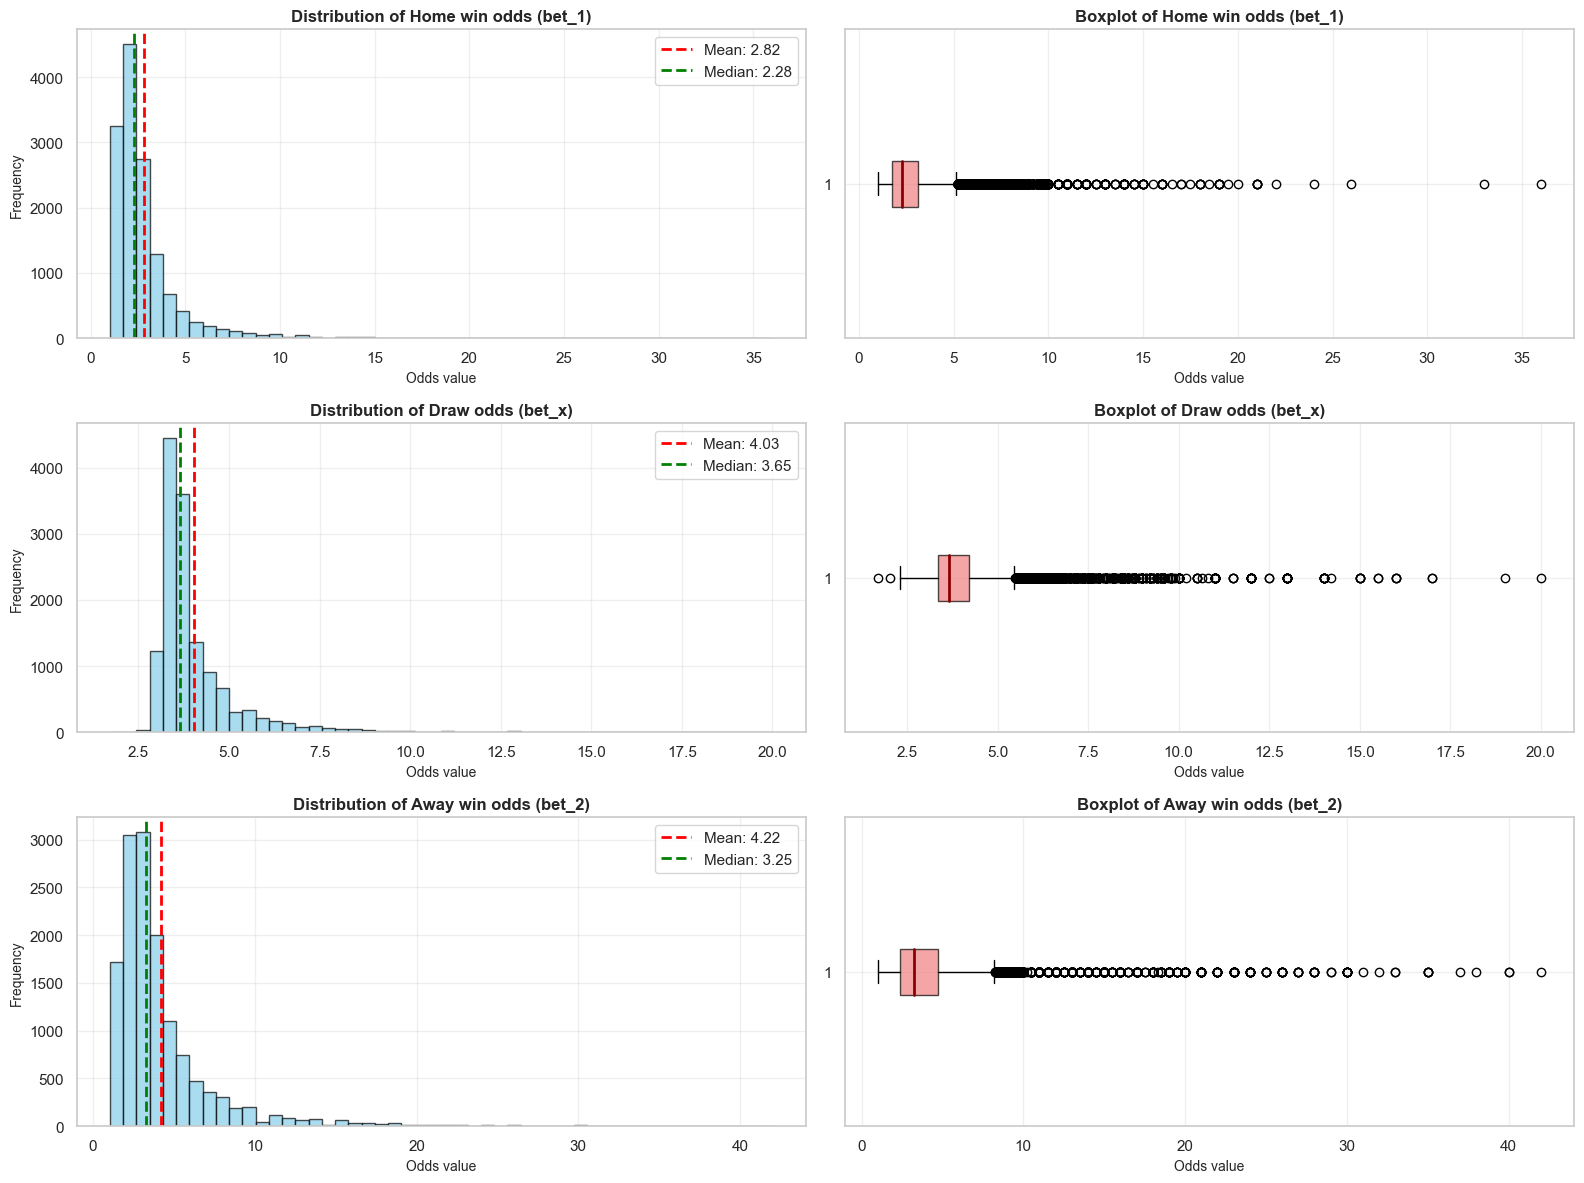


Statistics of betting odds:
          bet_1     bet_x     bet_2
count  13962.00  13962.00  13962.00
mean       2.82      4.03      4.22
std        1.94      1.25      3.41
min        1.02      1.71      1.04
25%        1.75      3.35      2.35
50%        2.28      3.65      3.25
75%        3.10      4.20      4.70
max       36.00     20.00     42.00


In [113]:
# Distribution of betting odds
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

bet_cols = ['bet_1', 'bet_x', 'bet_2']
bet_labels = [
    'Home win odds (bet_1)',
    'Draw odds (bet_x)',
    'Away win odds (bet_2)'
]

for i, (col, label) in enumerate(zip(bet_cols, bet_labels)):
    
    # Histogram
    axes[2*i].hist(joined_df[col].dropna(), bins=50, color='skyblue', alpha=0.7, edgecolor='black')
    axes[2*i].set_title(f'Distribution of {label}', fontsize=12, fontweight='bold')
    axes[2*i].set_xlabel('Odds value', fontsize=10)
    axes[2*i].set_ylabel('Frequency', fontsize=10)
    axes[2*i].axvline(joined_df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {joined_df[col].mean():.2f}')
    axes[2*i].axvline(joined_df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {joined_df[col].median():.2f}')
    axes[2*i].legend()
    axes[2*i].grid(alpha=0.3)
    
    # Boxplot
    axes[2*i + 1].boxplot(joined_df[col].dropna(), vert=False, patch_artist=True,
                          boxprops=dict(facecolor='lightcoral', alpha=0.7),
                          medianprops=dict(color='darkred', linewidth=2))
    axes[2*i + 1].set_title(f'Boxplot of {label}', fontsize=12, fontweight='bold')
    axes[2*i + 1].set_xlabel('Odds value', fontsize=10)
    axes[2*i + 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nStatistics of betting odds:")
print(joined_df[bet_cols].describe().round(2))

On the website, unavailable bets were marked with a value of -1. In such cases, we replace these values with NaN to ensure a clear and accurate overview of the data

In [114]:
for df in df_list:
    bet_cols = [col for col in df.columns if col.startswith('bet_')]
    for col in bet_cols:
        df[col] = df[col].apply(lambda x: np.nan if pd.notna(x) and x < 0 else x)


Minor renaming was applied to prevent errors related to the handicap bet columns.

In [115]:
for _df in df_list:
    new_cols = {}
    for col in _df.columns:
        if col.startswith('bet_handicap-_'):
            new_col = col.replace('bet_handicap-_', 'bet_handicap-0_')
            new_cols[col] = new_col
    _df.rename(columns=new_cols, inplace=True)

Global search for the best-performing ranges in specified bet types (excluding 'above/below' and handicap due to their different structure). While this analysis could be performed per league, doing so would result in few hundreds lines of data to process. Therefore, we start with a global overview, followed by an automated algorithm to filter out 2–4 leagues with lower consistency

In [116]:
def calculate_profits_for_bet_column(df, bet_col, winning_values):
    original_values = []
    profits = []

    for _, row in df.iterrows():
        odds = row[bet_col]
        winner = float(row['winner'])
        original_values.append(odds)

        if winner in winning_values:
            profits.append(round(odds - 1, 2))
        else:
            profits.append(-1)

    return original_values, profits

In [117]:
def simple_bet_range(df, _range=1.0, bet_types=None, range_min=None, range_max=None):
    bet_winner = {
        'bet_1': {1.0},
        'bet_2': {2.0},
        'bet_x': {0.0},
        'bet_1x': {1.0, 0.0},
        'bet_12': {1.0, 2.0},
        'bet_x2': {0.0, 2.0}
    }

    if bet_types is None:
        bet_types = list(bet_winner.keys())

    results = []

    for bet_col in bet_types:
        if bet_col not in df.columns:
            continue

        filtered_df = df.copy()

        if range_min is not None:
            filtered_df = filtered_df[filtered_df[bet_col] >= range_min]
        if range_max is not None:
            filtered_df = filtered_df[filtered_df[bet_col] <= range_max]

        if filtered_df.empty or len(filtered_df) < 2:
            continue

        sorted_df = filtered_df.sort_values(by=bet_col)
        original_vals, profit_vals = calculate_profits_for_bet_column(
            sorted_df, bet_col, bet_winner[bet_col]
        )

        range_size = int(len(profit_vals) * _range)

        if range_size < 2:
            continue

        # Sliding window
        range_avg_profit = []
        for i in range(len(profit_vals) - range_size + 1):
            avg = round(sum(profit_vals[i:i + range_size]) / range_size, 3)
            range_avg_profit.append(avg)

        if not range_avg_profit:
            continue

        max_avg_profit = max(range_avg_profit)
        best_index = range_avg_profit.index(max_avg_profit)
        best_range = (
            original_vals[best_index],
            original_vals[best_index + range_size - 1]
        )

        print(f"Bet: {bet_col}")
        print(f"Highest expected value: {max_avg_profit}, Bet range: {best_range}")
        print("---------------------------------------------------------------")

        results.append({
            "bet": bet_col,
            "max_avg_profit": max_avg_profit,
            "range": best_range
        })

    return results


In [118]:
simple_bet_range(joined_df, _range=0.2)

Bet: bet_1
Highest expected value: -0.002, Bet range: (1.02, 1.66)
---------------------------------------------------------------
Bet: bet_2
Highest expected value: 0.02, Bet range: (1.3, 2.24)
---------------------------------------------------------------
Bet: bet_x
Highest expected value: 0.043, Bet range: (3.45, 3.7)
---------------------------------------------------------------
Bet: bet_1x
Highest expected value: -0.005, Bet range: (1.22, 1.36)
---------------------------------------------------------------
Bet: bet_12
Highest expected value: -0.025, Bet range: (1.07, 1.23)
---------------------------------------------------------------
Bet: bet_x2
Highest expected value: 0.001, Bet range: (1.03, 1.36)
---------------------------------------------------------------


[{'bet': 'bet_1', 'max_avg_profit': -0.002, 'range': (1.02, 1.66)},
 {'bet': 'bet_2', 'max_avg_profit': 0.02, 'range': (1.3, 2.24)},
 {'bet': 'bet_x', 'max_avg_profit': 0.043, 'range': (3.45, 3.7)},
 {'bet': 'bet_1x', 'max_avg_profit': -0.005, 'range': (1.22, 1.36)},
 {'bet': 'bet_12', 'max_avg_profit': -0.025, 'range': (1.07, 1.23)},
 {'bet': 'bet_x2', 'max_avg_profit': 0.001, 'range': (1.03, 1.36)}]

Because this process is not yet automated, we manually copy the results into the *ranges* variable. Our goal is to identify the leagues with the poorest data quality or least reliable patterns for further analysis.

In [119]:
ranges = {
    'bet_1': [1.02, 1.66],
    'bet_2': [1.3, 2.24],
    'bet_x': [3.45, 3.7],
    'bet_1x': [1.23, 1.37],
    'bet_12': [1.07, 1.23],
    'bet_x2': [1.04, 1.36]
}
bet_types = list(ranges.keys())

all_results = {bet: [] for bet in bet_types}
leagues = joined_df['league'].unique()

for league in leagues:
    league_df = joined_df[joined_df['league'] == league]

    for bet_type in bet_types:
        range_min, range_max = ranges[bet_type]

        results = simple_bet_range(
            league_df,
            bet_types=[bet_type],
            range_min=range_min,
            range_max=range_max
        )

        for res in results:
            all_results[bet_type].append({
                "league": league,
                "max_avg_profit": res["max_avg_profit"],
                "range": res["range"]
            })


for bet_type in bet_types:
    print(f"\n=== Worst leagues: {bet_type} ===")
    sorted_leagues = sorted(all_results[bet_type], key=lambda x: x["max_avg_profit"])
    for entry in sorted_leagues[:3]:
        print(f"League: {entry['league']}, Average profit: {entry['max_avg_profit']}, Range: {entry['range']}")


Bet: bet_1
Highest expected value: -0.05, Bet range: (1.05, 1.65)
---------------------------------------------------------------
Bet: bet_2
Highest expected value: 0.057, Bet range: (1.3, 2.23)
---------------------------------------------------------------
Bet: bet_x
Highest expected value: 0.136, Bet range: (3.45, 3.7)
---------------------------------------------------------------
Bet: bet_1x
Highest expected value: 0.036, Bet range: (1.23, 1.37)
---------------------------------------------------------------
Bet: bet_12
Highest expected value: -0.065, Bet range: (1.07, 1.23)
---------------------------------------------------------------
Bet: bet_x2
Highest expected value: 0.045, Bet range: (1.06, 1.36)
---------------------------------------------------------------
Bet: bet_1
Highest expected value: 0.046, Bet range: (1.18, 1.66)
---------------------------------------------------------------
Bet: bet_2
Highest expected value: -0.089, Bet range: (1.36, 2.24)
---------------------

Selecting/finding the three leagues with the poorest performance

In [120]:
worst_counter = Counter()

for bet_type in bet_types:
    sorted_leagues = sorted(all_results[bet_type], key=lambda x: x["max_avg_profit"])
    worst_3 = sorted_leagues[:3]

    for entry in worst_3:
        worst_counter[entry["league"]] += 1

for league, count in worst_counter.most_common():
    print(f"League: {league}, Counter: {count}")

League: Premier Liga, Counter: 4
League: Jupiler League, Counter: 3
League: Super League, Counter: 3
League: Eredivisie, Counter: 2
League: Bundesliga, Counter: 1
League: Tipico Bundesliga, Counter: 1
League: Premiership, Counter: 1
League: Primeira Liga, Counter: 1
League: Liga Portugal, Counter: 1
League: Ligue 1, Counter: 1


In [121]:
leagues_to_exclude = ['Premier Liga', 'Jupiler League', 'Super League']

Having identified the leagues with the worst performance, we can exclude them from the analysis. This should improve the overall data quality for our basic analysis. As a result, charts will be generated both including all leagues and excluding the filtered ones. This will allow us to compare the impact of removing these leagues on the analysis outcomes.

In [122]:
def base_bet_condition(winner, winner_type):
    if winner_type == '1':
        return winner == 1.0
    elif winner_type == '2':
        return winner == 2.0
    elif winner_type == 'x':
        return winner == 0.0
    elif winner_type == '1x':
        return winner in [1.0, 0.0]
    elif winner_type == '12':
        return winner in [1.0, 2.0]
    elif winner_type == 'x2':
        return winner in [0.0, 2.0]
    else:
        return False

In [123]:
def plot_base_bets(bet_type, range_min=1.0, range_max=3.0, step=0.2, nameprefix='', df_list=df_list):
    season_years = {
        0: '2020-2021',
        1: '2021-2022',
        2: '2022-2023',
        3: '2023-2024'
    }
    
    winner_type = str(bet_type).split('_')[1]
    bins = np.arange(range_min, range_max + step, step)
    labels = [f"{round(b, 2)}–{round(b+step, 2)}" for b in bins[:-1]]

    num_plots = len(df_list)
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 6 * num_plots))

    if num_plots == 1:
        axes = [axes]

    for i, df in enumerate(df_list):
        df = df.copy()
        df['bin'] = pd.cut(df[bet_type], bins=bins, labels=labels, include_lowest=True)

        hits = df['winner'].apply(lambda x: base_bet_condition(x, winner_type))
        green = df[hits].groupby('bin').size().reindex(labels, fill_value=0)
        red = df[~hits].groupby('bin').size().reindex(labels, fill_value=0)

        def avg_profit(grupa):
            hits = grupa['winner'].apply(lambda x: base_bet_condition(x, winner_type))
            score = ((grupa[bet_type] - 1).where(hits, -1)).sum()
            return score / len(grupa) if len(grupa) > 0 else 0

        profit = df.groupby('bin').apply(avg_profit).reindex(labels, fill_value=0)

        x = np.arange(len(labels))
        width = 0.35

        ax1 = axes[i]
        ax1.bar(x - width / 2, green, width=width, color='green', label='Win')
        ax1.bar(x + width / 2, red, width=width, color='red', label='Lost')
        ax1.set_ylabel('Number of bets')
        ax1.set_title(f'DF {i} — {bet_type} vs winner')
        ax1.set_title(f'Season {season_years[i]} — Zakłady typu: {bet_type}')

        ax2 = ax1.twinx()
        ax2.bar(x, profit, width=width / 2, color='blue', alpha=0.5, label='Average profit')
        ax2.axhline(y=0, color='black', linewidth=2, linestyle='--')

        ax1.set_xticks(x)
        ax1.set_xticklabels(labels, rotation=45)
        ax1.grid(True, alpha=0.4)

        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc='best')

        # plt.tight_layout()
        plt.savefig(f"../charts/{nameprefix}{bet_type}_{range_min}_to_{range_max}_step{step}.png", dpi=400, bbox_inches='tight')
    plt.show()

In [124]:
def plot_joined_bets(bet_type, range_min=1.0, range_max=3.0, step=0.2, nameprefix='', df=joined_df):
    
    winner_type = str(bet_type).split('_')[1]
    
    bins = np.arange(range_min, range_max + step, step)
    labels = [f"{round(b, 2)}–{round(b+step, 2)}" for b in bins[:-1]]

    df = df.copy()
    df['bin'] = pd.cut(df[bet_type], bins=bins, labels=labels, include_lowest=True)

    hits = df['winner'].apply(lambda x: base_bet_condition(x, winner_type))

    green = df[hits].groupby('bin').size().reindex(labels, fill_value=0)
    red = df[~hits].groupby('bin').size().reindex(labels, fill_value=0)

    def avg_profit(grupa):
        hits_local = grupa['winner'].apply(lambda x: base_bet_condition(x, winner_type))
        score = ((grupa[bet_type] - 1).where(hits_local, -1)).sum()
        return score / len(grupa) if len(grupa) > 0 else 0

    profit = df.groupby('bin').apply(avg_profit).reindex(labels, fill_value=0)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    x = np.arange(len(labels))
    width = 0.35

    ax1.bar(x - width / 2, green, width=width, color='green', label='Win')
    ax1.bar(x + width / 2, red, width=width, color='red', label='Loss')

    ax1.set_ylabel('Number of bets')
    ax1.set_title(f'{bet_type} — Win/Loss distribution (joined dataset)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45)
    ax1.grid(alpha=0.4)

    ax2 = ax1.twinx()
    ax2.bar(x, profit, width=width / 2, color='blue', alpha=0.4, label='Avg profit')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)

    # legend merge
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='best')

    plt.tight_layout()

    plt.savefig(
        f"../charts/{nameprefix}{bet_type}_{range_min}_to_{range_max}_step{step}.png",
        dpi=400,
        bbox_inches='tight'
    )

    plt.show()

Here we run the plotting function and modify commented lines to view or save the plots. We repeat this process for the bet types: *bet_1*, *bet_x*, *bet_2*, *bet_1x*, *bet_12*, and *bet_x2*.

In [125]:
# plot_joined_bets('bet_12', 1.0, 2.4, 0.2)
# plot_joined_bets('bet_1',  1.0, 2.4, 0.2)
# plot_joined_bets('bet_2',  1.0, 2.4, 0.2)
# plot_joined_bets('bet_x2', 1.0, 2.4, 0.2)
# plot_joined_bets('bet_1x', 1.0, 2.4, 0.2)
# plot_joined_bets('bet_x',  2.4, 3.8, 0.2)

In [126]:
filtered_df_list = []
for df in df_list:
    filtered_df = df[~df['league'].isin(leagues_to_exclude)].copy()
    filtered_df_list.append(filtered_df)

# plot_base_bets('bet_12', 1.0, 1.6, 0.05, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_1', 1.0, 3.0, 0.2, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_2', 1.0, 3.0, 0.2, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_x2', 1.0, 1.6, 0.05, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_1x', 1.0, 1.6, 0.05, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_x', 2.6, 4.6, 0.2, nameprefix='filtered_', df_list=filtered_df_list)

Now let’s take a closer look at the bet types: above, below, and handicap

In [127]:
def advanced_bet_condition(col_name, goals_1, goals_2) -> bool:
    if 'handicap' in col_name:
        try:
            suffix = col_name.replace('bet_handicap', '')
            additional_goals_str, winner_str = suffix.split('_')
            
            if additional_goals_str in ["-", "", "+", " "]:
                additional_goals = 0.0
            else:
                additional_goals = float(additional_goals_str)
    
            winner = int(winner_str)
            not_winner = 1 if winner == 2 else 2

            goals_map = {1: goals_1, 2: goals_2}
            return (goals_map[winner] + additional_goals) > goals_map[not_winner]

        except:
            return False
    
    if 'above' in col_name:
        try:
            value = float(col_name.split("_")[-1])
        except:
            return False
        
        return (goals_1 + goals_2) > value
    
    if 'below' in col_name:
        try:
            value = float(col_name.split("_")[-1])
        except:
            return False
        
        return (goals_1 + goals_2) < value
    
    return False

In [128]:
def plot_bet_results_by_type(prefix, handicap_team=1, save=True):
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 5), constrained_layout=True)

    bet_cols = [col for col in joined_df.columns if col.startswith(prefix)]
    if prefix == 'bet_handicap':
        bet_cols = [col for col in bet_cols if col.endswith(f"_{handicap_team}")]

    stats = {}
    results = defaultdict(list)

    for col in bet_cols:
        if prefix != 'bet_handicap':
            bet_value = col.split('_')[-1]
        else:
            raw = col.replace(prefix, "").split('_')[0]
            try:
                bet_value = float(raw)
            except:
                bet_value = '0.0'

        for _, row in joined_df.iterrows():
            if pd.isna(row[col]):
                continue
            val = pd.to_numeric(row[col], errors='coerce')
            if pd.isna(val):
                continue
            res = advanced_bet_condition(col, row['goals_1'], row['goals_2'])
            profit = val - 1 if res else -1
            results[bet_value].append(profit)


    for bet_value, profit_list in results.items():
        if not profit_list:
            continue

        green = sum(1 for p in profit_list if p > 0)
        red = profit_list.count(-1)
        avg_profit = sum(profit_list) / len(profit_list)
        stats[bet_value] = {'green': green, 'red': red, 'profit': avg_profit}


    def safe_sort_key(x):
        try:
            return float(str(x).replace('+', ''))
        except:
            return 0.0

    labels = sorted(stats.keys(), key=safe_sort_key)

    # labels = sorted(stats.keys(), key=lambda x: float(x.replace('+', '')) if x not in ['-', '', None] else 0.0)
    green_vals = [stats[label]['green'] for label in labels]
    red_vals = [stats[label]['red'] for label in labels]
    blue_vals = [stats[label]['profit'] for label in labels]

    x = np.arange(len(labels))
    width = 0.35

    # Left axis - total matches
    ax1.bar(x - width / 2, green_vals, width=width, color='green', label='Win')
    ax1.bar(x + width / 2, red_vals, width=width, color='red', label='Lost')
    ax1.set_ylabel('Number of bets')
    ax1.set_xlabel('Bet value')
    ax1.set_title(f'Zakłady typu: {prefix}')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45)
    ax1.grid(True, alpha=0.3)

    # Right axis - profits
    ax2 = ax1.twinx()
    ax2.axhline(y=0, color='black', linewidth=2, linestyle='--')
    ax2.bar(x, blue_vals, width=width / 2, color='blue', alpha=0.5, label='Average profit')

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='best')

    if save:
        prefix = f'{prefix}_{handicap_team}' if prefix == 'bet_handicap' else prefix
        os.makedirs("charts", exist_ok=True)
        plt.savefig(f"../charts/{prefix}.png", dpi=400, bbox_inches='tight')

    plt.show()

In [129]:
# plot_bet_results_by_type('bet_above')

In [130]:
# plot_bet_results_by_type('bet_below')

In [131]:
# plot_bet_results_by_type('bet_handicap', 1)

In [132]:
# plot_bet_results_by_type('bet_handicap', 2)

As observed, there is an issue with the *handicap* bets. After reviewing the CSV data and comparing it to the website, we discovered data leakage. Therefore, we will exclude handicap bets from our analysis until this issue is resolved, for example, by re-downloading the data.

## Time and Seasonality Analysis

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1668739428.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day_of_week'] = df['date'].dt.dayofweek
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1668739428.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['month'] = df['date'].dt.month
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1668739428.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

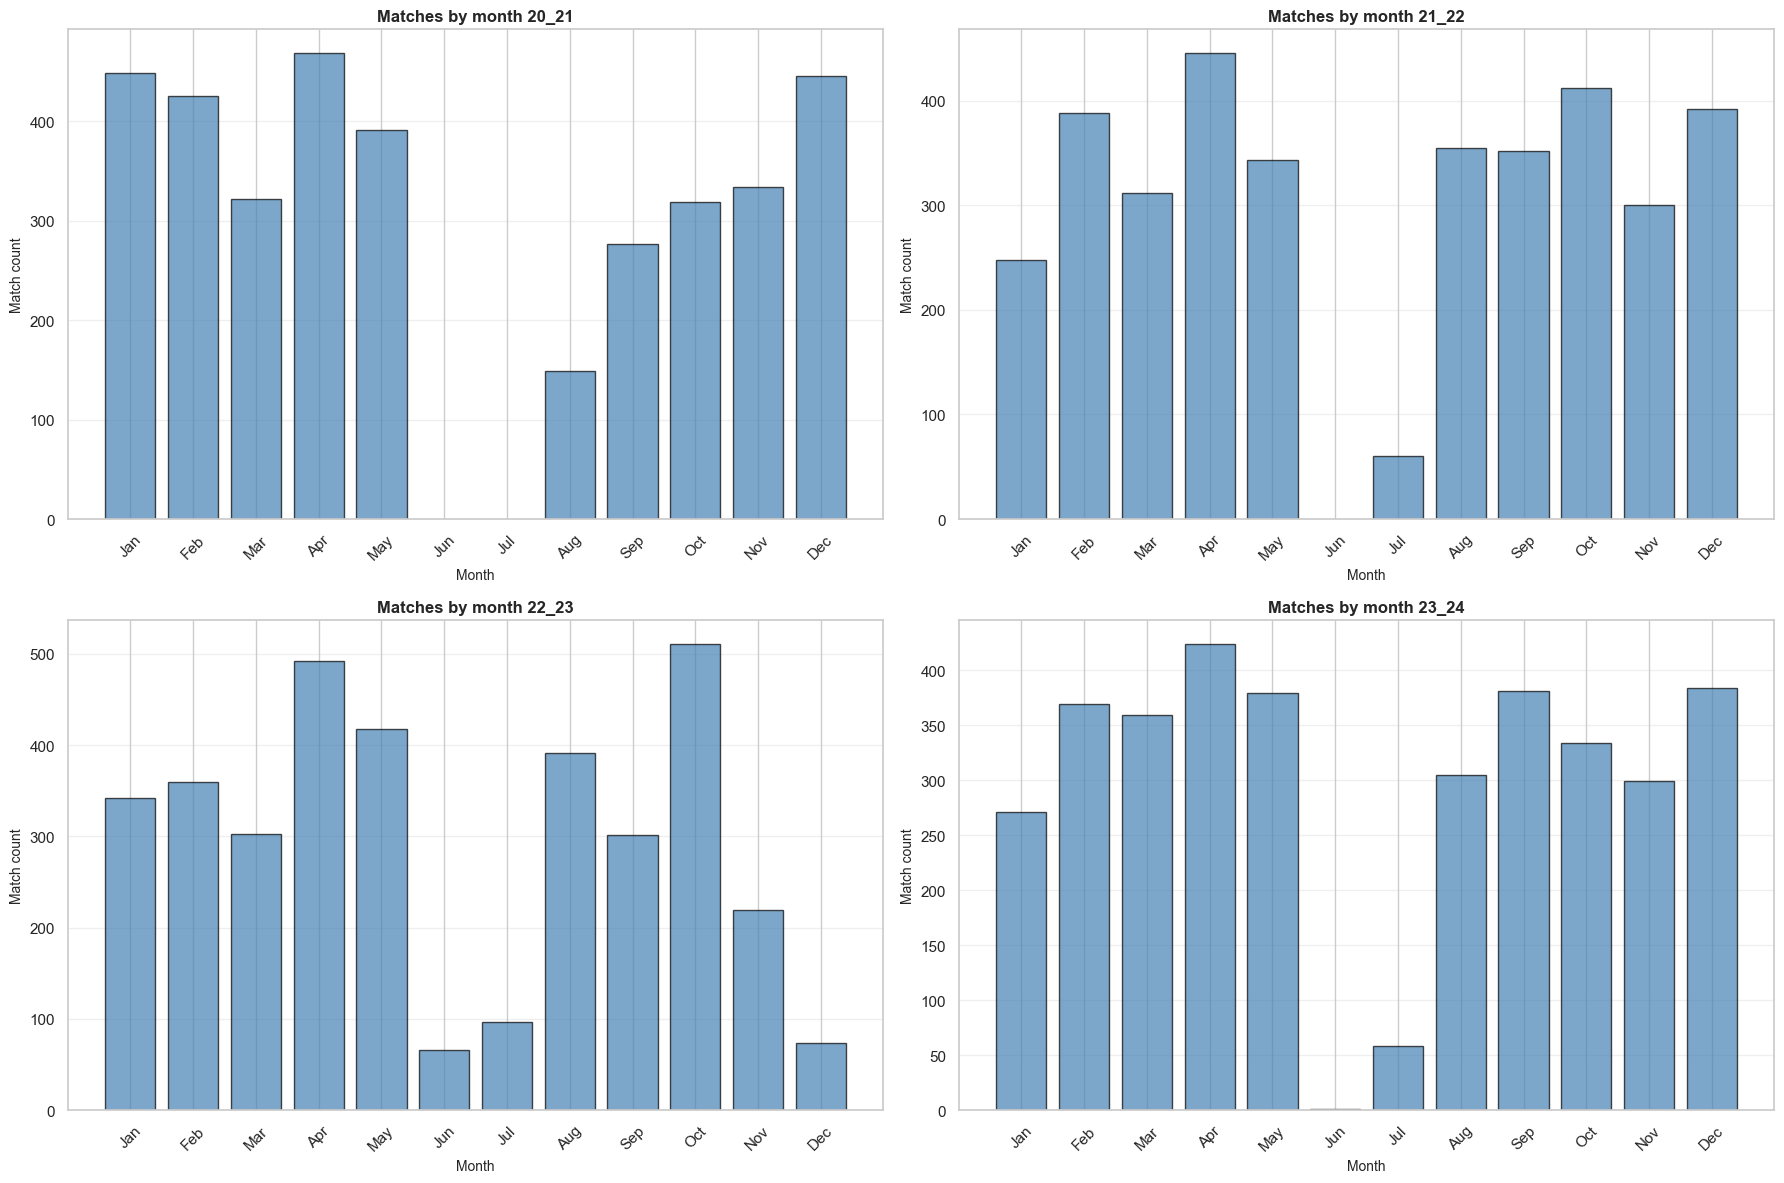

In [133]:
for df in df_list:
    df['date'] = pd.to_datetime(df['date'], format="%d.%m.%Y %H:%M")
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (df, label) in enumerate(zip(df_list, season_labels)):
    month_counts = df['month'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    axes[i].bar(month_counts.index, month_counts.values, 
                color='steelblue', alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Matches by month {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Month', fontsize=10)
    axes[i].set_ylabel('Match count', fontsize=10)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels([month_names[m-1] for m in range(1, 13)], rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Small feature engineering and formatting

In [134]:
for df in df_list:
    df['shots_1'] = df['shots_on_target_1'] + df['shots_off_target_1']
    df['shots_2'] = df['shots_on_target_2'] + df['shots_off_target_2']
    df['possession_1'] = df['possession_1'].str.replace('%','').astype(float)
    df['possession_2'] = df['possession_2'].str.replace('%','').astype(float)

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3760346085.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['shots_1'] = df['shots_on_target_1'] + df['shots_off_target_1']
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3760346085.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['shots_2'] = df['shots_on_target_2'] + df['shots_off_target_2']
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3760346085.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert

In [135]:
df[['shots_1', 'shots_off_target_1', 'shots_on_target_1']].mean()

shots_1               11.134999
shots_off_target_1     6.278978
shots_on_target_1      4.856020
dtype: float64

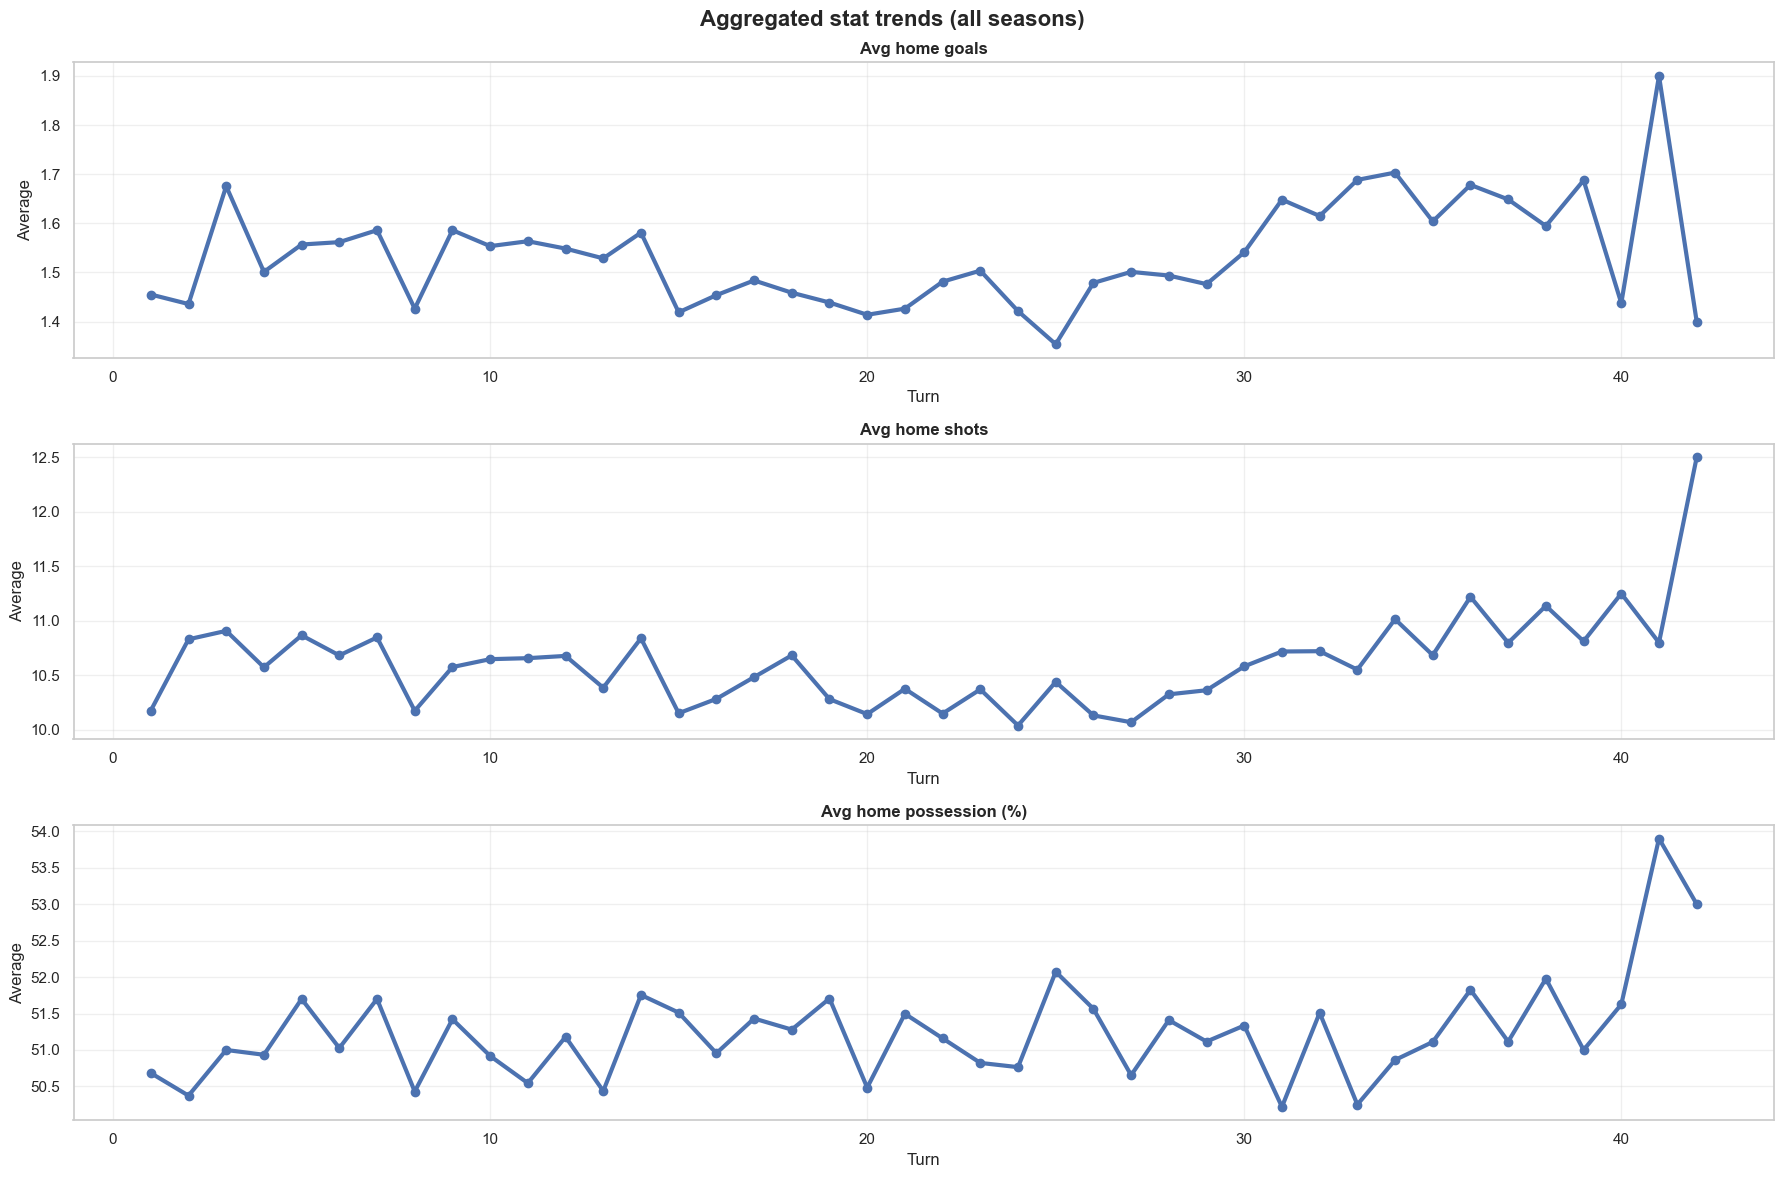

In [136]:
df_all = pd.concat(df_list)

stats_to_plot = ['goals_1', 'shots_1', 'possession_1']
stat_labels = ['Avg home goals', 'Avg home shots',
               'Avg home possession (%)']

fig, axes = plt.subplots(3, 1, figsize=(18, 12))

for i, (stat, stat_label) in enumerate(zip(stats_to_plot, stat_labels)):
    temp = df_all.copy()
    temp[stat] = pd.to_numeric(temp[stat], errors='coerce')

    trend = temp.groupby('turn')[stat].mean()

    axes[i].plot(trend.index, trend.values, marker='o', linewidth=3)

    axes[i].set_title(stat_label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Turn')
    axes[i].set_ylabel('Average')
    axes[i].grid(alpha=0.3)

plt.suptitle('Aggregated stat trends (all seasons)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

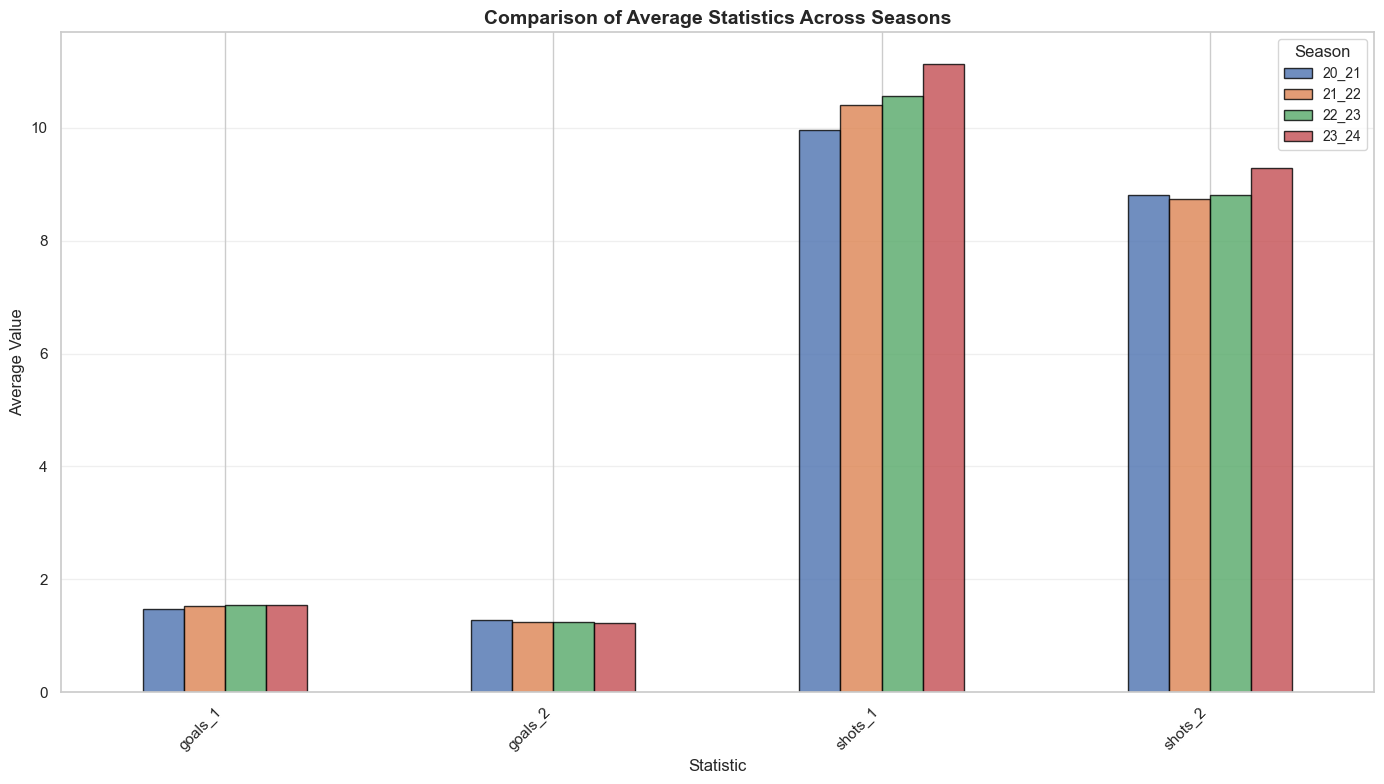


Average values per season:
        goals_1  goals_2  shots_1  shots_2
season                                    
20_21      1.47     1.28     9.96     8.81
21_22      1.52     1.24    10.41     8.73
22_23      1.55     1.25    10.57     8.80
23_24      1.54     1.23    11.13     9.29


In [137]:
comparison_stats = ['goals_1', 'goals_2', 'shots_1', 'shots_2']
comparison_stats = [col for col in comparison_stats if col in df_all.columns]

season_means = []
for df, label in zip(df_list, season_labels):
    means = df[comparison_stats].mean()
    means['season'] = label
    season_means.append(means)

season_means_df = pd.DataFrame(season_means)
season_means_df = season_means_df.set_index('season')

fig, ax = plt.subplots(figsize=(14, 8))
season_means_df.T.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='black')

ax.set_title('Comparison of Average Statistics Across Seasons', fontsize=14, fontweight='bold')
ax.set_xlabel('Statistic', fontsize=12)
ax.set_ylabel('Average Value', fontsize=12)

ax.legend(title='Season', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nAverage values per season:")
print(season_means_df.round(2))

# 3. Missing data handling

After running *quality.ipynb*, most of the data has been filled. However, some specific values might still be missing due to their absence on the source web page. Let's now proceed with filling in the missing values.

Let's assume that in some cases of a match statistic are NaN (e.g., red cards), it means that the event did not occur. Therefore, some cases will be filled with 0.

Important: match header data — date, teams, and goals — are always provided.

## Match statistics

In [138]:
def check_nans_by_columns(columns: list, threshold=0.2):
    for i, _df in enumerate(df_list):
        print(f'\n===== DATAFRAME {i} =====')
        total_rows = len(_df)

        for _col in columns:
            for suffix in ['_1', '_2', '']:
                col_name = f'{_col}{suffix}' if suffix else _col
                
                if col_name in _df.columns:
                    na_count = _df[col_name].isna().sum()
                    
                    if na_count == 0:
                        continue
                    
                    na_pct = na_count / total_rows * 100
                    flag = ' >20%' if na_pct > threshold * 100 else ''
                    
                    print(f'{col_name:<25} | NA: {na_count:<5} | {na_pct:>6.2f}% {flag}')

In [139]:
# chunk 1 info
check_nans_by_columns(['match_id','date','league','turn','team_1','team_2','goals_1','goals_2','winner'])


===== DATAFRAME 0 =====

===== DATAFRAME 1 =====

===== DATAFRAME 2 =====

===== DATAFRAME 3 =====


In [140]:
# chunk 2 info
check_nans_by_columns(['shots','expected_goals','possession','goal_chances','shots_on_target','shots_off_target','blocked_shots', 'free_kicks','offsides','throw_ins','goalkeeper_saves','fouls', 'red_cards','attacks','dangerous_attacks'])


===== DATAFRAME 0 =====
shots_1                   | NA: 4     |   0.11% 
shots_2                   | NA: 4     |   0.11% 
possession_1              | NA: 11    |   0.31% 
possession_2              | NA: 11    |   0.31% 
goal_chances_1            | NA: 4     |   0.11% 
goal_chances_2            | NA: 4     |   0.11% 
shots_on_target_1         | NA: 4     |   0.11% 
shots_on_target_2         | NA: 4     |   0.11% 
shots_off_target_1        | NA: 4     |   0.11% 
shots_off_target_2        | NA: 4     |   0.11% 
blocked_shots_1           | NA: 605   |  16.89% 
blocked_shots_2           | NA: 605   |  16.89% 
free_kicks_1              | NA: 1479  |  41.29%  >20%
free_kicks_2              | NA: 1479  |  41.29%  >20%
offsides_1                | NA: 11    |   0.31% 
offsides_2                | NA: 11    |   0.31% 
throw_ins_1               | NA: 2939  |  82.05%  >20%
throw_ins_2               | NA: 2939  |  82.05%  >20%
goalkeeper_saves_1        | NA: 4     |   0.11% 
goalkeeper_saves_2      

Filling match statistics

In [141]:
def fill_missing_by_team_mean(df, team_col, value_col, default_value=0):
    team_avg = df.groupby(team_col)[value_col].mean()

    def fill_func(row):
        if pd.isna(row[value_col]):
            return team_avg.get(row[team_col], default_value)
        else:
            return row[value_col]
    
    df[value_col] = df.apply(fill_func, axis=1)

def adjust_possession(row):
    p1 = row['possession_1']
    p2 = row['possession_2']
    
    if pd.isna(p1) and pd.isna(p2):
        return pd.Series([50, 50])
    if pd.isna(p1):
        p1 = 100 - p2
    if pd.isna(p2):
        p2 = 100 - p1

    total = p1 + p2
    if total == 0:
        return pd.Series([50, 50])
    
    factor = 100 / total
    p1_scaled = round(p1 * factor)
    p2_scaled = 100 - p1_scaled

    return pd.Series([p1_scaled, p2_scaled])

In [142]:
for _df in df_list:    
    # possession
    fill_missing_by_team_mean(_df, team_col='team_1', value_col='possession_1', default_value=50)
    fill_missing_by_team_mean(_df, team_col='team_2', value_col='possession_2', default_value=50)
    # scaling possession
    _df[['possession_1', 'possession_2']] = _df.apply(adjust_possession, axis=1)

    # fouls
    _df['fouls_1'] = _df['fouls_1'].fillna(_df.groupby('team_1')['fouls_1'].transform('median')).fillna(0)
    _df['fouls_2'] = _df['fouls_2'].fillna(_df.groupby('team_2')['fouls_2'].transform('median')).fillna(0)
    
    # offsides (spalone)
    _df['offsides_1'] = _df['offsides_1'].fillna(_df.groupby('team_1')['offsides_1'].transform('median')).fillna(0)
    _df['offsides_2'] = _df['offsides_2'].fillna(_df.groupby('team_2')['offsides_2'].transform('median')).fillna(0)

    # red cards
    _df['red_cards_1'].fillna(0, inplace=True)
    _df['red_cards_2'].fillna(0, inplace=True)


In [143]:
for _df in df_list:
    for _col in ['goal_chances', 'shots_on_target', 'shots_off_target', 'goalkeeper_saves', 'attacks', 'dangerous_attacks']:
        _df[f'{_col}_1'] = _df[f'{_col}_1'].fillna(_df.groupby('team_1')[f'{_col}_1'].transform('median')).fillna(0)
        _df[f'{_col}_2'] = _df[f'{_col}_2'].fillna(_df.groupby('team_2')[f'{_col}_2'].transform('median')).fillna(0)

Below removed columns due to excessive missing values; filling NAs would not be accurate. Resolving this issue requires a different scraper and data source.

In [144]:
for _df in df_list:
    _df.drop(columns=['expected_goals_1', 'expected_goals_2', 'throw_ins_1', 'throw_ins_2', 'free_kicks_1', 'free_kicks_2', 'blocked_shots_1', 'blocked_shots_2'], axis=1, inplace=True, errors='ignore')

Refresh shots column

In [145]:
for df in df_list:
    df['shots_1'] = df['shots_on_target_1'] + df['shots_off_target_1']
    df['shots_2'] = df['shots_on_target_2'] + df['shots_off_target_2']

Ensure the filling process went correctly

In [146]:
# chunk 2 info
check_nans_by_columns(['shots','expected_goals','possession','goal_chances','shots_on_target','shots_off_target','blocked_shots', 'free_kicks','offsides','throw_ins','goalkeeper_saves','fouls', 'red_cards','attacks','dangerous_attacks'])


===== DATAFRAME 0 =====

===== DATAFRAME 1 =====

===== DATAFRAME 2 =====

===== DATAFRAME 3 =====


## Team setups and player ratings

Checking for NANs in team formations

In [147]:
for _df in df_list:
    print('=================')
    print(_df['team_1_formation'].isna().sum())
    print(_df['team_2_formation'].isna().sum())

2
2
2
2
36
36
1
0


Filling missing values with the most popular formation for each team

In [148]:
for _df in df_list:
    _df['team_1_formation'] = _df['team_1_formation'].fillna(
        _df.groupby('team_1')['team_1_formation'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    )
    _df['team_2_formation'] = _df['team_2_formation'].fillna(
        _df.groupby('team_2')['team_2_formation'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    )

In [149]:
for _df in df_list:
    print('=================')
    print(_df['team_1_formation'].isna().sum())
    print(_df['team_2_formation'].isna().sum())

0
0
0
0
0
0
0
0


Handling player ratings stored as line-format strings (e.g., "6.2-6.7-4.3") is inconvenient. A better approach is to aggregate these ratings into a single value, categorize them into defense/support/offense ratings, or split them into separate ratings for each player. The most flexible solution is the last one—splitting the ratings per player. Therefore, we will transform the DataFrame accordingly and handle missing values in one centralized step.

In [150]:
def extract_scores(row, prefix, formation):
    scores = []
    val = row.get(f'{prefix}_line_0')

    if pd.isna(val):
        return [np.nan] * 11

    try:
        scores.append(float(val))
    except:
        scores.append(0.0)

    for i, expected_count in enumerate(formation, start=1):
        val = row.get(f'{prefix}_line_{i}')
        if pd.isna(val):
            line_scores = [0.0] * expected_count
        else:
            parts = []
            for p in str(val).split('-'):
                try:
                    parts.append(float(p.strip()))
                except:
                    pass

            if len(parts) < expected_count:
                insert_pos = len(parts) // 2
                parts.insert(insert_pos, 0.0)
            line_scores = parts

        scores.extend(line_scores)

    return scores

In [151]:
for _df in df_list:
    for index, row in _df.iterrows():
        try:
            formation_1 = [int(x.strip()) for x in str(row['team_1_formation']).split('-')]
            formation_2 = [int(x.strip()) for x in str(row['team_2_formation']).split('-')]
        except:
            continue

        scores_1 = extract_scores(row, 'team_1', formation_1)
        scores_2 = extract_scores(row, 'team_2', formation_2)

        if len(scores_1) != 11:
            print('team_1 problem (match_id):', _df.at[index, 'match_id'], '| found:', len(scores_1))
        if len(scores_2) != 11:
            print('team_2 problem (match_id):', _df.at[index, 'match_id'], '| found:', len(scores_2))

        for i in range(11):
            value = scores_1[i] if i < len(scores_1) else 0.0
            _df.at[index, f'player_{i}_team_1'] = value

            value = scores_2[i] if i < len(scores_2) else 0.0
            _df.at[index, f'player_{i}_team_2'] = value

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1555587034.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _df.at[index, f'player_{i}_team_2'] = value
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1555587034.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _df.at[index, f'player_{i}_team_1'] = value
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1555587034.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

In [152]:
# check case - 1 example
# team_1_player_3 should have 0.0 value
row = df1[df1['match_id'] == 'ju20wXAg']
if not row.empty:
    print(row[[f'player_{i}_team_1' for i in range(11)]])
else:
    print("Brak meczu o podanym match_id")

    player_0_team_1  player_1_team_1  player_2_team_1  player_3_team_1  \
34              6.9              7.1              7.8              0.0   

    player_4_team_1  player_5_team_1  player_6_team_1  player_7_team_1  \
34              6.6              6.7              6.7              7.3   

    player_8_team_1  player_9_team_1  player_10_team_1  
34              6.6              8.1               7.0  


Review of missing player ratings

In [153]:
for _df in df_list:
    print(_df['player_0_team_1'].isna().sum())
    print("===========")

241
245
40
1


Fills missing player ratings with team-winner group averages.

In [154]:
for _df in df_list:
    for team in [1, 2]:
        for player_idx in range(11):
            col = f'player_{player_idx}_team_{team}'
            group_col = f'team_{team}'

            mean_vals = _df.groupby([group_col, 'winner'])[col].mean()

            for idx, row in _df[_df[col].isna()].iterrows():
                key = (row[group_col], row['winner'])
                if key in mean_vals:
                    _df.at[idx, col] = mean_vals[key]


In [155]:
for i, _df in enumerate(df_list):
    print(f"DataFrame #{i}")
    for team in [1, 2]:
        for player_idx in range(11):
            col = f'player_{player_idx}_team_{team}'
            mask = _df[col].isna()
            missing = mask.sum()
            if missing > 0:
                leagues_with_nan = _df.loc[mask, 'league'].dropna().unique().tolist()
                print(f"  {col} -> missing: {missing} \tleagues: {leagues_with_nan}")
    print("===========")

DataFrame #0
  player_0_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_1_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_2_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_3_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_4_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_5_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_6_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_7_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_8_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_9_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_10_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_0_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_1_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_2_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_3_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_4_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_5

In [156]:
for df in df_list:
    print(f"Premier Liga: " , df.loc[df['league'] == 'Premier Liga'].shape[0])

Premier Liga:  240
Premier Liga:  240
Premier Liga:  240
Premier Liga:  240


`Premier Liga` is missing all team player ratings. Because of this, we can either drop the league or fill these missing values using global patterns. A simple approach would be to fill missing ratings with the median plus some noise based on match outcome (win/draw/lose). A more accurate—but potentially overly complex—solution would involve integrating team ratings into the dataset, which we haven’t done yet (this could be addressed after feature engineering).

In summary, I will apply a simple filling method with small noise for now.

Ultimately, we may decide to either exclude player ratings from model training, find and integrate data from another source, fill missing values (currently about 7% of data is missing), or drop the league entirely from further analysis and modeling.

In [157]:
rating_noise_choices = np.arange(-0.3, 0.4, 0.1)

for df in df_list:
    for team in [1, 2]:
        for i in range(11):
            col = f'player_{i}_team_{team}'
            group_cols = ['winner', 'goals_1', 'goals_2']

            mask_nan = df[col].isna()

            most_common = df.groupby(group_cols)[col].transform(
                lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
            )

            df[col] = df[col].fillna(most_common)

            noise_mask = mask_nan & df[col].notna()
            noise = np.random.choice(rating_noise_choices, size=noise_mask.sum())
            df.loc[noise_mask, col] += noise
            df[col] = df[col].clip(0, 10)

            # during this process one match isn't filled so we use this to slove the problem
            if df[col].isna().any():
                df[col].fillna(df[col].median(), inplace=True)

Double check

In [158]:
for i, _df in enumerate(df_list):
    print(f"DataFrame #{i}")
    for team in [1, 2]:
        for player_idx in range(11):
            col = f'player_{player_idx}_team_{team}'
            mask = _df[col].isna()
            missing = mask.sum()
            if missing > 0:
                leagues_with_nan = _df.loc[mask, 'league'].dropna().unique().tolist()
                print(f"  {col} -> missing: {missing} \tleagues: {leagues_with_nan}")
    print("===========")

DataFrame #0
DataFrame #1
DataFrame #2
DataFrame #3


## Bets missing values

In some cases (especially in certain leagues), not all data is available or provided (e.g., bet types, match results, team ratings). Note: Within each data chunk, there may be instances where some columns contain missing (NaN) values.

In betting, decimal odds represent the inverse of the bookmaker's estimated probability of an event — typically with an included margin (profit):

$$
\text{odds} = \frac{1}{\text{probability} \cdot (1 + \text{margin})}
$$

For example, if the fair (true) probability of a team winning is 0.5, and the bookmaker's margin is 5%, then the offered odds would be:

$$
\text{odds} = \frac{1}{0.5 \cdot (1 + 0.05)} = \frac{1}{0.525} \approx 1.90
$$

---

Some bets are combinations of outcomes:

- `1X`: either Team 1 wins or it's a Draw
- `12`: either Team 1 or Team 2 wins (no draw)
- `X2`: either Draw or Team 2 wins

Assuming independence and fair odds (ignoring margin), we can estimate combined odds using probabilities:

$$
\frac{1}{\text{bet\_1X}} = \frac{1}{\text{bet\_1}} + \frac{1}{\text{bet\_X}}
, 
\frac{1}{\text{bet\_X2}} = \frac{1}{\text{bet\_X}} + \frac{1}{\text{bet\_2}}
, 
\frac{1}{\text{bet\_12}} = \frac{1}{\text{bet\_1}} + \frac{1}{\text{bet\_2}}
$$

Then, to solve for the missing single odds:

$$
\text{bet\_1} = \left( \frac{1}{\text{bet\_1X}} - \frac{1}{\text{bet\_X}} \right)^{-1}
, 
\text{bet\_X} = \left( \frac{1}{\text{bet\_1X}} - \frac{1}{\text{bet\_1}} \right)^{-1}
, 
\text{bet\_2} = \left( \frac{1}{\text{bet\_X2}} - \frac{1}{\text{bet\_X}} \right)^{-1}
$$

Likewise, to infer missing combined bets from basic odds:

$$
\text{bet\_1X} = \left( \frac{1}{\text{bet\_1}} + \frac{1}{\text{bet\_X}} \right)^{-1}
, 
\text{bet\_X2} = \left( \frac{1}{\text{bet\_X}} + \frac{1}{\text{bet\_2}} \right)^{-1}
, 
\text{bet\_12} = \left( \frac{1}{\text{bet\_1}} + \frac{1}{\text{bet\_2}} \right)^{-1}
$$

These formulas assume *no margin*, but they are suitable for estimating or filling missing values where precision is not critical.

---

Bookmakers always apply a margin, so these formulas may not precisely reconstruct offered odds.

In [159]:
for _df in df_list:
    print('=================')
    bet_na_counter = _df[['bet_1', 'bet_2', 'bet_x']].isna().all(axis=1).sum()
    print("Bets 1, 2, x\t\t", bet_na_counter)
    if _df['bet_1'].isna().sum() != bet_na_counter:
        print(_df['bet_1'].isna().sum())
    if _df['bet_x'].isna().sum() != bet_na_counter:
        print(_df['bet_x'].isna().sum())
    if _df['bet_2'].isna().sum() != bet_na_counter:
        print(_df['bet_2'].isna().sum())
    
    bet_na_counter = _df[['bet_12', 'bet_x2', 'bet_1x']].isna().all(axis=1).sum()
    print('Bets 12, 1x, x2\t', bet_na_counter)
    if _df['bet_1x'].isna().sum() != bet_na_counter:
        print(_df['bet_1x'].isna().sum())
    if _df['bet_x2'].isna().sum() != bet_na_counter:
        print(_df['bet_x2'].isna().sum())
    if _df['bet_12'].isna().sum() != bet_na_counter:
        print(_df['bet_12'].isna().sum())

Bets 1, 2, x		 101
Bets 12, 1x, x2	 39
Bets 1, 2, x		 159
Bets 12, 1x, x2	 4
31
8
Bets 1, 2, x		 29
Bets 12, 1x, x2	 35
59
37
Bets 1, 2, x		 73
Bets 12, 1x, x2	 1257
1284
1259


Coś nie pykło, poniżej druga funkcja gites działa, jeszcze raz uruchomić i sprawdzić

In [160]:
def odds_inverse(x):
    return 1.0 / x

def odds_from_inverse(x):
    return round(1.0 / x, 2) if x > 0 else np.nan

for df in df_list:
    for idx, row in df.iterrows():
        b1, bx, b2 = row['bet_1'], row['bet_x'], row['bet_2']
        b1x, b12, bx2 = row['bet_1x'], row['bet_12'], row['bet_x2']
        # fill 1x, x2, 12 using 1, x, 2
        try:
            if pd.isna(b1x) and not pd.isna(b1) and not pd.isna(bx):
                df.at[idx, 'bet_1x'] = odds_from_inverse(odds_inverse(b1) + odds_inverse(bx))
            if pd.isna(bx2) and not pd.isna(b2) and not pd.isna(bx):
                df.at[idx, 'bet_x2'] = odds_from_inverse(odds_inverse(b2) + odds_inverse(bx))
            if pd.isna(b12) and not pd.isna(b1) and not pd.isna(b2):
                df.at[idx, 'bet_12'] = odds_from_inverse(odds_inverse(b1) + odds_inverse(b2))
        except:
            pass


In [161]:
def solve_odds(b1x, b12, bx2):
    if b1x == 0 or b12 == 0 or bx2 == 0:
        return np.nan, np.nan, np.nan
    if pd.isna(b1x) or pd.isna(b12) or pd.isna(bx2):
        return np.nan, np.nan, np.nan
    
    A = 1.0 / b1x
    B = 1.0 / b12
    C = 1.0 / bx2
    
    # A = 1/b1 + 1/bx
    # B = 1/b1 + 1/b2
    # C = 1/bx + 1/b2
    
    # (1/b1 + 1/bx) + (1/bx + 1/b2) = A + C
    # (1/b1 + 2/bx + 1/b2) = A + C
    # x = 1/b1, y = 1/bx, z = 1/b2
    
    # x + y = A
    # x + z = B
    # y + z = C
    
    # (x+y)+(x+z)= A + B => 2x + y + z = A + B
    # y + z = C
    # 2x + C = A + B => x = (A + B - C)/2
    x = (A + B - C) / 2
    y = A - x
    z = B - x
    
    bet_1 = 1 / x if x > 0 else np.nan
    bet_x = 1 / y if y > 0 else np.nan
    bet_2 = 1 / z if z > 0 else np.nan
    
    return round(bet_1, 2), round(bet_x, 2), round(bet_2, 2)

In [162]:
for df in df_list:
    for idx, row in df.iterrows():
        b1, bx, b2 = row['bet_1'], row['bet_x'], row['bet_2']
        b1x, b12, bx2 = row['bet_1x'], row['bet_12'], row['bet_x2']

        if pd.isna(b1) or pd.isna(bx) or pd.isna(b2):
            if not pd.isna(b1x) and not pd.isna(b12) and not pd.isna(bx2):
                b1_new, bx_new, b2_new = solve_odds(b1x, b12, bx2)
                if pd.isna(b1):
                    df.at[idx, 'bet_1'] = b1_new
                if pd.isna(bx):
                    df.at[idx, 'bet_x'] = bx_new
                if pd.isna(b2):
                    df.at[idx, 'bet_2'] = b2_new


In [96]:
for _df in df_list:
    print('=================')
    bet_na_counter = _df[['bet_1', 'bet_2', 'bet_x']].isna().all(axis=1).sum()
    print("Bets 1, 2, x\t\t", bet_na_counter)
    if _df['bet_1'].isna().sum() != bet_na_counter:
        print(_df['bet_1'].isna().sum())
    if _df['bet_x'].isna().sum() != bet_na_counter:
        print(_df['bet_x'].isna().sum())
    if _df['bet_2'].isna().sum() != bet_na_counter:
        print(_df['bet_2'].isna().sum())
    
    bet_na_counter = _df[['bet_12', 'bet_x2', 'bet_1x']].isna().all(axis=1).sum()
    print('Bets 12, 1x, x2\t', bet_na_counter)
    if _df['bet_1x'].isna().sum() != bet_na_counter:
        print(_df['bet_1x'].isna().sum())
    if _df['bet_x2'].isna().sum() != bet_na_counter:
        print(_df['bet_x2'].isna().sum())
    if _df['bet_12'].isna().sum() != bet_na_counter:
        print(_df['bet_12'].isna().sum())

Bets 1, 2, x		 1
Bets 12, 1x, x2	 1
Bets 1, 2, x		 0
Bets 12, 1x, x2	 0
Bets 1, 2, x		 29
Bets 12, 1x, x2	 29
Bets 1, 2, x		 30
Bets 12, 1x, x2	 29
30


As we can see, we have mostly filled the missing values using the correct algorithm. The bets *bet_1*, *bet_x*, and *bet_2* will be used as input data for training the algorithm.  Now let's fill missing data with grouping and mean (not perfect solution but size of each dataframe is ~3500rows, that gives <1% filled data)

In [163]:
for df in df_list:
    for team_col in ['team_1', 'team_2']:
        for col in ['bet_1', 'bet_x', 'bet_2', 'bet_1x', 'bet_12', 'bet_x2']:
            team_avg = df.groupby(team_col)[col].mean()
            mask = df[col].isna()
            df.loc[mask, col] = df.loc[mask, team_col].map(team_avg)


In [164]:
for _df in df_list:
    print('=================')
    bet_na_counter = _df[['bet_1', 'bet_2', 'bet_x']].isna().all(axis=1).sum()
    print("Bets 1, 2, x\t\t", bet_na_counter)
    if _df['bet_1'].isna().sum() != bet_na_counter:
        print(_df['bet_1'].isna().sum())
    if _df['bet_x'].isna().sum() != bet_na_counter:
        print(_df['bet_x'].isna().sum())
    if _df['bet_2'].isna().sum() != bet_na_counter:
        print(_df['bet_2'].isna().sum())
    
    bet_na_counter = _df[['bet_12', 'bet_x2', 'bet_1x']].isna().all(axis=1).sum()
    print('Bets 12, 1x, x2\t', bet_na_counter)
    if _df['bet_1x'].isna().sum() != bet_na_counter:
        print(_df['bet_1x'].isna().sum())
    if _df['bet_x2'].isna().sum() != bet_na_counter:
        print(_df['bet_x2'].isna().sum())
    if _df['bet_12'].isna().sum() != bet_na_counter:
        print(_df['bet_12'].isna().sum())

Bets 1, 2, x		 0
Bets 12, 1x, x2	 0
Bets 1, 2, x		 0
Bets 12, 1x, x2	 0
Bets 1, 2, x		 0
Bets 12, 1x, x2	 0
Bets 1, 2, x		 0
Bets 12, 1x, x2	 0


The bets above and below will be used after the AI models for bet-building purposes. As mentioned earlier, handicap bets will be removed. Therefore, in the end, we will not fill missing values in the *above*, *below*, and *handicap* columns.

In [165]:
def check_bet_v1(df, x=3):

    handicap_cols = [col for col in df.columns if col.startswith('bet_handicap')]
    above_cols = [col for col in df.columns if col.startswith('bet_above')]

    df['handicap_count'] = df[handicap_cols].notna().sum(axis=1)
    df['above_count'] = df[above_cols].notna().sum(axis=1)

    print('==============')
    print("Missing data in handicap:", (df['handicap_count'] < x).sum())
    print("Missing data in above/below:", (df['above_count'] < x).sum())
    
for _df in df_list:
    check_bet_v1(_df, 3)

Missing data in handicap: 2538
Missing data in above/below: 1
Missing data in handicap: 964
Missing data in above/below: 61
Missing data in handicap: 223
Missing data in above/below: 86
Missing data in handicap: 222
Missing data in above/below: 1488


C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\900436675.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['handicap_count'] = df[handicap_cols].notna().sum(axis=1)
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\900436675.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['above_count'] = df[above_cols].notna().sum(axis=1)
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\900436675.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

# 4. Data cleaning and transformation

## Cleaning and transformation

This stage includes removing unnecessary or irrelevant columns (such as redundant identifiers or columns with too many missing values) and transforming features into formats suitable for modeling

### Columns drop and cleaning

**FOR NOW: Removing BET ABOVE  and BELOW as bet above seems incorrect. Need to research this topic**. Removing of support columns for couting missing data

In [166]:
for df in df_list:
    df.drop([col for col in df.columns if 'bet_above' in col], axis = 1, inplace = True)
    df.drop([col for col in df.columns if 'bet_below' in col], axis = 1, inplace = True)
    df.drop(['above_count'], axis = 1, inplace = True)

Removing handicap from our dataframes

In [167]:
for df in df_list:
    df.drop([col for col in df.columns if 'handicap' in col], axis=1, inplace=True)

In chapter 3- team setups and player ratings we made new column based on player lines. Now we remove those lines.

In [168]:
for df in df_list:
    df.drop([col for col in df.columns if 'team_1_line' in col], axis=1, inplace=True)
    df.drop([col for col in df.columns if 'team_2_line' in col], axis=1, inplace=True)

In [183]:
for df in df_list:
    df.drop([col for col in df.columns if 'bet_1x' in col], axis = 1, inplace = True)
    df.drop([col for col in df.columns if 'bet_12' in col], axis = 1, inplace = True)
    df.drop([col for col in df.columns if 'bet_x2' in col], axis = 1, inplace = True)

In [103]:
# for df in df_list:
#     df.drop(columns=['match_id'], axis=1, inplace=True)

For model that won't be LSTM or something similar beneficial would be providing data from earlier matches. Based on general info provided at the internet we can try:

- making scores/memory of win/lose/draw in last 5 matches                               
- team/player rathing from last 5 or so matches (like previous for temporary team condition)
- making table with team points in each season
- cumulative columns of wins, loses and draws in each season
- making cumulative player rating from last few matches (preffered grouping for defence, offensive, support or whole team)
- providing previous and current team place at the end of a season

Note: not evry idea will be included

In [169]:
for i, df in enumerate(df_list):
    nan_counts = df.isna().sum()
    nan_counts = nan_counts[nan_counts > 0]
    if not nan_counts.empty:
        print(f"\ndf_list[{i}] NAN count:")
        print(nan_counts)


At the end we need to ensure team names are consistent. For this case data will be saved to temporary files to take a look and compare names

In [170]:
temp_counter = 1

for df in df_list:
    all_results = []
    
    for league_name, group in df.groupby('league'):
        
        teams = pd.concat([group['team_1'], group['team_2']])
        counts = teams.value_counts().reset_index()
        counts.columns = ['team', 'count']
        counts['league'] = league_name
        
        all_results.append(counts)
    
    season_df = pd.concat(all_results, ignore_index=True)
    season_df = season_df[['league', 'team', 'count']]
    season_df.to_csv(f"teams_counts_{temp_counter}.csv", index=False)
    
    temp_counter += 1

Observed outliers were put to `name_map` to adjust names

In [171]:
name_map = {
    'SK Rapid': 'Rapid Wiedeń',
    'Austria Klagenfurt': 'A. Klagenfurt',
    'Standard Liege': 'St. Liege',
    'OH Leuven': 'Leuven',
    'Zulte Waregem': 'Waregem',
    'Lokomotiw Moskwa': 'Lok. Moskwa',
    'Dynamo Moskwa': 'Dyn. Moskwa',
    'NEC Nijmegen': 'Nijmegen',
    'Fortuna Sittard': 'Sittard',
    'RKC Waalwijk': 'Waalwijk',
}


for df in df_list:
    df['team_1'] = df['team_1'].replace(name_map)
    df['team_2'] = df['team_2'].replace(name_map)

Review of the changes:

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


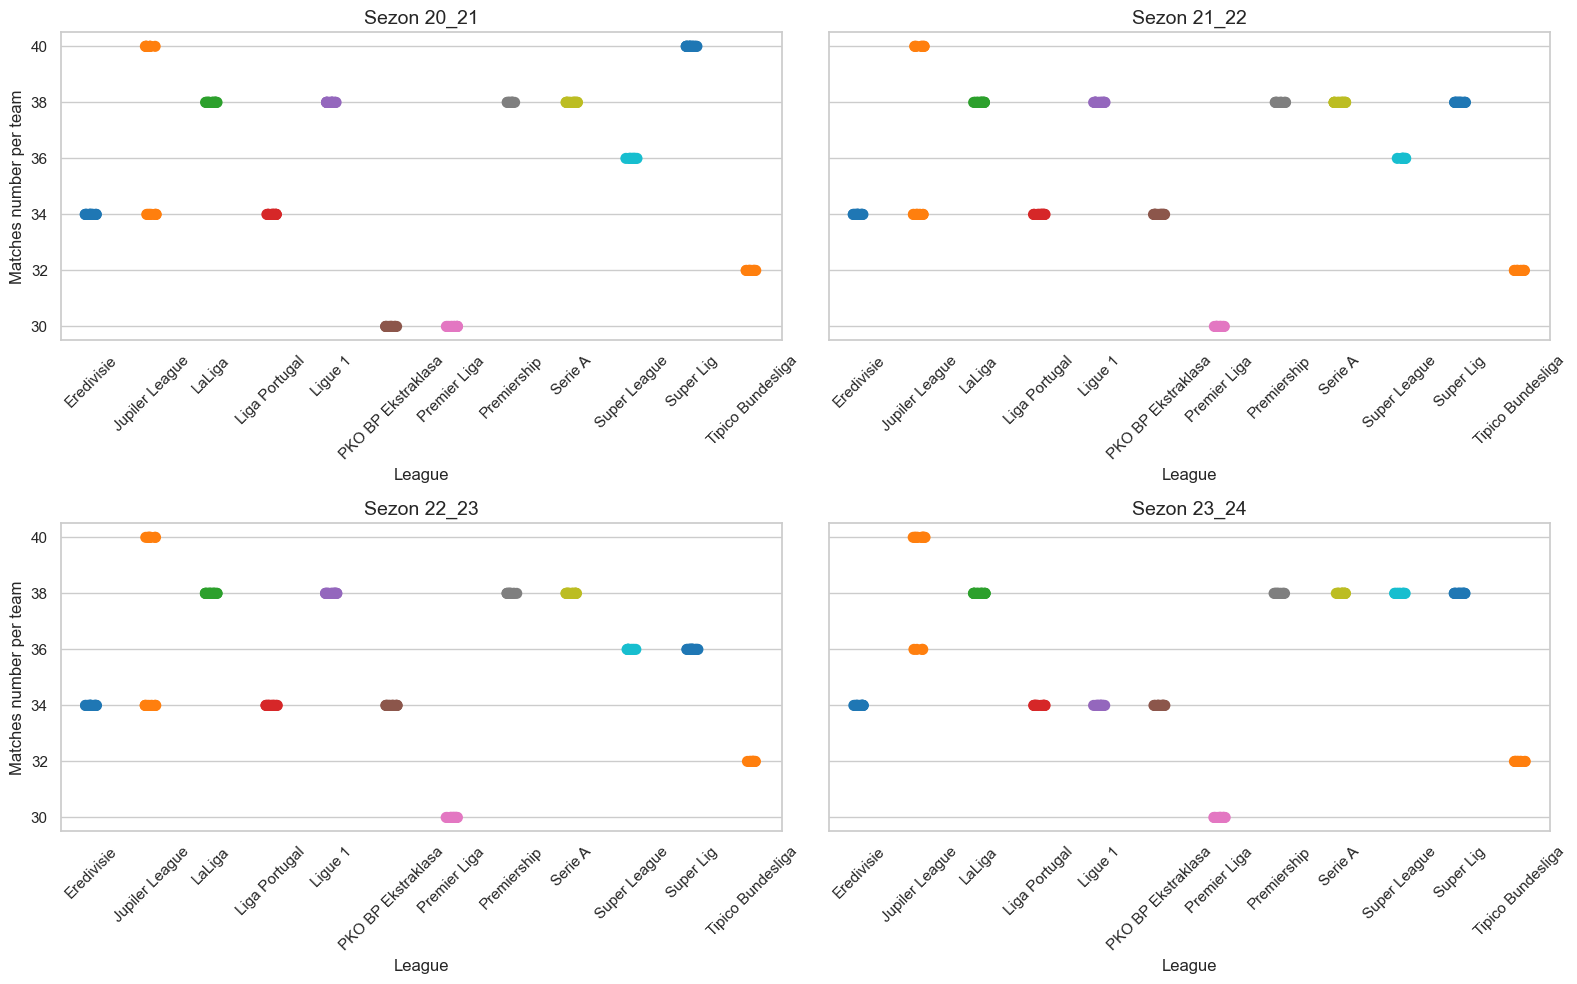

In [173]:
sns.set(style="whitegrid")

num_seasons = len(df_list)
fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True)
axes = axes.flatten()

for i, df in enumerate(df_list):
    all_results = []

    for league_name, group in df.groupby('league'):
        teams = pd.concat([group['team_1'], group['team_2']])
        counts = teams.value_counts().reset_index()
        counts.columns = ['team', 'count']
        counts['league'] = league_name
        all_results.append(counts)

    season_df = pd.concat(all_results, ignore_index=True)

    sns.stripplot(
        x='league', y='count', data=season_df,
        jitter=True, size=8, palette="tab10", ax=axes[i]
    )

    axes[i].set_title(f'Sezon {season_labels[i]}', fontsize=14)
    axes[i].set_xlabel('League', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    if i % 2 == 0:
        axes[i].set_ylabel('Matches number per team', fontsize=12)
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### Time series (approach 2)

to trzeba dokonczyc, dla 3 i 5 meczy w tyl srednie arytmeyczne tych roznych kolumn
potem z tego zrobic df'a do treningu gdzie dane WE beda z 1,3,5 ostatnich meczy - do time series modeli

In [184]:
print(df1.columns)

Index(['match_id', 'date', 'league', 'turn', 'team_1', 'team_2', 'goals_1',
       'goals_2', 'winner', 'possession_1', 'possession_2', 'goal_chances_1',
       'goal_chances_2', 'shots_on_target_1', 'shots_on_target_2',
       'shots_off_target_1', 'shots_off_target_2', 'offsides_1', 'offsides_2',
       'goalkeeper_saves_1', 'goalkeeper_saves_2', 'fouls_1', 'fouls_2',
       'attacks_1', 'attacks_2', 'dangerous_attacks_1', 'dangerous_attacks_2',
       'team_1_formation', 'team_2_formation', 'bet_1', 'bet_x', 'bet_2',
       'red_cards_1', 'red_cards_2', 'month', 'day_of_week', 'shots_1',
       'shots_2', 'player_0_team_1', 'player_0_team_2', 'player_1_team_1',
       'player_1_team_2', 'player_2_team_1', 'player_2_team_2',
       'player_3_team_1', 'player_3_team_2', 'player_4_team_1',
       'player_4_team_2', 'player_5_team_1', 'player_5_team_2',
       'player_6_team_1', 'player_6_team_2', 'player_7_team_1',
       'player_7_team_2', 'player_8_team_1', 'player_8_team_2',
       

In [174]:
def time_series(df: pd.DataFrame, timestamp): # -> pd.DataFrame:
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], format="%d.%m.%Y %H:%M")
    
    results = {}
    # columns that won't be taken for time series
    excluded_columns = ['date', 'league', 'turn', 'team_1', 'team_2', 'winner',
                        'bet_1x', 'bet_12', 'bet_x2', 'bet_1', 'bet_x', 'bet_2']
    
    for ligue, group_df in df.groupby('league'):
        group_df = group_df.sort_values('date').reset_index(drop=True)
        
        base_names = set()
        for col in group_df.columns:
            if col not in excluded_columns:
                # remove sufix _1, _2
                base_name = re.sub(r'_[12]$', '', col)
                # player_3_team_1 -> player_3
                base_name = re.sub(r'_team$', '', base_name)
                # team_1_formation -> formation
                base_name = re.sub(r'^team_[12]_formation$', 'formation', base_name)
                # player_x_team_y to player_x
                base_name = re.sub(r'(player_\d+)_team_[12]', r'\1', base_name)
                base_names.add(base_name)
        
        for team in group_df['team_1'].unique():
            results[team] = {name: [] for name in base_names}
        
        for idx, row in group_df.iterrows():
            team_1 = row['team_1']
            team_2 = row['team_2']
            
            for col in group_df.columns:
                if col in excluded_columns:
                    continue

                # team_1
                if re.search(r'(_1$|_team_1$|_formation$)', col):
                    if col in ['team_1_formation', 'team_2_formation']:
                        base_name = 'formation'
                    else:
                        base_name = re.sub(r'(_team_1|_1)$', '', col)
                        base_name = re.sub(r'(player_\d+)_team_1', r'\1', base_name)
                    value = row[col]
                    results[team_1].setdefault(base_name, []).append(value)

                elif re.search(r'(_2$|_team_2$|_formation$)', col):
                    if col in ['team_1_formation', 'team_2_formation']:
                        base_name = 'formation'
                    else:
                        base_name = re.sub(r'(_team_2|_2)$', '', col)
                        base_name = re.sub(r'(player_\d+)_team_2', r'\1', base_name)
                    value = row[col]
                    results[team_2].setdefault(base_name, []).append(value)
                # elif re.search(r'(_2$|_team_2$)', col):
                #     base_name = re.sub(r'(_team_2|_2)$', '', col)
                #     value = row[col]
                #     results[team_2].setdefault(base_name, []).append(value)

    return results

In [175]:
def time_series_skeleton(df: pd.DataFrame):
    df = df.copy()
    
    excluded_columns = [
        'date', 'league', 'turn', 'team_1', 'team_2', 'winner',
        'bet_1x', 'bet_12', 'bet_x2', 'bet_1', 'bet_x', 'bet_2',
        'match_id']

    results = {}

    for league_name, group_df in df.groupby('league'):
        all_teams = pd.concat([group_df['team_1'], group_df['team_2']]).unique()
        
        # skeleton
        base_names = set()
        for col in group_df.columns:
            if col in excluded_columns:
                continue
            m = re.match(r'(player_\d+)_team_[12]', col)
            if m:
                base_names.add(m.group(1))
                continue
            if col in ['team_1_formation', 'team_2_formation']:
                base_names.add('formation')
                continue
            if col.endswith('_1') or col.endswith('_2'):
                base_names.add(col[:-2])
                continue
            base_names.add(col)

        for team in all_teams:
            if team not in results:
                results[team] = {name: [] for name in base_names}

        # kolumny statystyk (suffix _1 / _2)
        stat_cols = [
            c for c in group_df.columns
            if c not in excluded_columns
            and c not in ['team_1_formation', 'team_2_formation']
            and not re.match(r'player_\d+_team_[12]', c)
            and (c.endswith('_1') or c.endswith('_2'))
        ]
        player_nums = sorted(set(
            re.match(r'(player_\d+)_team_[12]', c).group(1)
            for c in group_df.columns
            if re.match(r'(player_\d+)_team_[12]', c)
        ))

        for _, row in group_df.iterrows():
            for side, team in [('1', row['team_1']), ('2', row['team_2'])]:
                entry = {}

                # statystyki: fouls, goals, possession itd.
                for col in stat_cols:
                    if col.endswith(f'_{side}'):
                        base = col[:-2]
                        entry[base] = row[col]

                # formacja
                entry['formation'] = row[f'team_{side}_formation']

                # gracze
                for p in player_nums:
                    entry[p] = row[f'{p}_team_{side}']

                # dopisz do historii zespołu
                for key, val in entry.items():
                    results[team][key].append(val)

    return results

In [ ]:
def all_teams_report(res: dict, df: pd.DataFrame):
    """Raport dla wszystkich drużyn: wypisuje tylko metryki niepełne (skrócona wersja)."""
    for team in sorted(res.keys()):
        expected = int(((df['team_1'] == team) | (df['team_2'] == team)).sum())
        # jeżeli drużyna nie występuje w df, pomin
        if expected == 0:
            print(f"{team}: 0 matches -> skipped")
            continue
        # sprawdź metryki, czy wszystkie mają expected długości
        bad = []
        for metric, values in res[team].items():
            if len(values) != expected:
                bad.append((metric, len(values)))
        if bad:
            print(f"\n{team} (expected={expected}) - {len(bad)} incomplete metrics:")
            for m, l in bad:
                print(f"  {m:30} {l}/{expected}")

for df in df_list:
    res = time_series_skeleton(df)
    all_teams_report(res, df)

In [ ]:
for _df in df_list:
    _df.drop(clumns=['month', 'day_of_week'], inplace=True)

## Save progress

The dataset has undergone significant transformation. It's recommended to save the transformed version.

The data we will work with is now cleaned and ready. However, additional preparation will be needed to convert it into a format suitable for model training. Currently, each row contains the betting odds for a match along with post-match information such as team ratings and statistics.

For training purposes, we need to restructure the dataset so that each row represents the context before a match — including the upcoming match, the odds for that match, and relevant statistics derived from previous games. This format will enable the model to learn from historical performance and betting patterns to make accurate predictions.

In [185]:
season = {
    0: '20_21',
    1: '21_22',
    2: '22_23',
    3: '23_24'
}

for i, df in enumerate(df_list):
    df.to_csv(f'../data/transformed_data/{season[i]}_transformed.csv', index=False)

In [186]:
def save_time_series(results: dict, season_label: str, output_dir: str = "../data/processed"):
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, f"season_{season_label}.json")
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"Saved: {path} ({len(results)} teams)")

season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']

for df, label in zip(df_list, season_labels):
    results = time_series_skeleton(df)
    save_time_series(results, label)

Saved: ../data/processed\season_2020_21.json (201 teams)
Saved: ../data/processed\season_2021_22.json (202 teams)
Saved: ../data/processed\season_2022_23.json (201 teams)
Saved: ../data/processed\season_2023_24.json (200 teams)


In [189]:
joined_df = pd.concat(df_list, ignore_index=True)

In [190]:
joined_df.shape

(14324, 60)

In [191]:
joined_df.columns

Index(['match_id', 'date', 'league', 'turn', 'team_1', 'team_2', 'goals_1',
       'goals_2', 'winner', 'possession_1', 'possession_2', 'goal_chances_1',
       'goal_chances_2', 'shots_on_target_1', 'shots_on_target_2',
       'shots_off_target_1', 'shots_off_target_2', 'offsides_1', 'offsides_2',
       'goalkeeper_saves_1', 'goalkeeper_saves_2', 'fouls_1', 'fouls_2',
       'attacks_1', 'attacks_2', 'dangerous_attacks_1', 'dangerous_attacks_2',
       'team_1_formation', 'team_2_formation', 'bet_1', 'bet_x', 'bet_2',
       'red_cards_1', 'red_cards_2', 'month', 'day_of_week', 'shots_1',
       'shots_2', 'player_0_team_1', 'player_0_team_2', 'player_1_team_1',
       'player_1_team_2', 'player_2_team_1', 'player_2_team_2',
       'player_3_team_1', 'player_3_team_2', 'player_4_team_1',
       'player_4_team_2', 'player_5_team_1', 'player_5_team_2',
       'player_6_team_1', 'player_6_team_2', 'player_7_team_1',
       'player_7_team_2', 'player_8_team_1', 'player_8_team_2',
       

# 5. Models

## Preparation

This section performs importing required libraries in futher part of the notebbok, load data and define function required for model training

In [15]:
import pandas as pd
import numpy as np
import json
import os
import re
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import make_scorer
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.utils.validation import check_is_fitted

In [16]:
df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

df_list = [df1, df2, df3, df4]

In [17]:
def make_winner_scorer(threshold):
    def betting_profit_winner(estimator, X, y_true):
        proba      = estimator.predict_proba(X)
        classes    = estimator.classes_
        confidence = proba.max(axis=1)
        predicted  = classes[proba.argmax(axis=1)]

        X_reset = X.reset_index(drop=True)
        y_reset = np.array(y_true)

        profits = []
        for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
            if conf < threshold:
                continue
            bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
            if bet_col not in X_reset.columns:
                continue
            odds = X_reset.iloc[i][bet_col]
            profits.append((odds - 1) if pred == true else -1)

        return np.sum(profits) if profits else np.nan
    return betting_profit_winner

def betting_profit_goals(estimator, X, y_true):
    """
    Profit scorer for goals model - predicts goals_1 and goals_2.
      goals_1 > goals_2  → bet_1
      goals_1 < goals_2  → bet_2
      goals_1 == goals_2 → bet_x
    Return: (odds - 1) or -1 based if we won an event or not.
    """
    pred  = np.round(estimator.predict(X)).astype(int)
    y_arr = np.array(y_true)

    profits = []
    for i, (p_row, t_row) in enumerate(zip(pred, y_arr)):
        p1, p2 = p_row[0], p_row[1]
        t1, t2 = t_row[0], t_row[1]

        if p1 > p2:
            bet_col      = 'bet_1'
            true_outcome = 1
        elif p1 < p2:
            bet_col      = 'bet_2'
            true_outcome = 2
        else:
            bet_col      = 'bet_x'
            true_outcome = 0

        if t1 > t2:
            actual_outcome = 1
        elif t1 < t2:
            actual_outcome = 2
        else:
            actual_outcome = 0

        odds = X.iloc[i][bet_col]
        profits.append((odds - 1) if true_outcome == actual_outcome else -1)

    return np.sum(profits)

Custom models

In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# CUSTOM CLASSIFIER - Train withoud odds as input
# ═══════════════════════════════════════════════════════════════════════════
class BettingTreeClassifier(BaseEstimator, ClassifierMixin):
    """
    Scorer have access to full X (with odds) during evaluation.
    """
    def __init__(self, feature_cols, max_depth=4, min_samples_leaf=20, random_state=42):
        self.feature_cols = feature_cols
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state
    
    def fit(self, X, y):
        self.clf_ = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            random_state=self.random_state
        )
        # Train on feature_cols (without odds)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        self.clf_.fit(X_feats, y)
        self.classes_ = self.clf_.classes_
        return self
    
    def predict(self, X):
        check_is_fitted(self, 'clf_')
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict(X_feats)
    
    def predict_proba(self, X):
        check_is_fitted(self, 'clf_')
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict_proba(X_feats)


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# CUSTOM CLASSIFIER - TRAING WITHOUT ODDS AS FEATURE-INPUT
# ═══════════════════════════════════════════════════════════════════════════
class BettingForestClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, feature_cols, n_estimators=300, max_depth=4, min_samples_leaf=20, max_features=1.0, random_state=42):
        self.feature_cols = feature_cols
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
    
    def fit(self, X, y):
        self.clf_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            max_features = self.max_features,
            random_state=self.random_state,
            n_jobs=-1
        )
        # train on only feature cols (odds excluded)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        self.clf_.fit(X_feats, y)
        self.classes_ = self.clf_.classes_
        return self
    
    def predict(self, X):
        check_is_fitted(self, 'clf_')
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict(X_feats)
    
    def predict_proba(self, X):
        check_is_fitted(self, 'clf_')
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict_proba(X_feats)

## Benchmarks

This section is responsible for building 2 types of models:
- predict exact goals_1 and goals_2
- predict whether first team will win, draw or lose

Next there will be plots to visualise results

### Benchmark - expected goals

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════

df_train = pd.concat([df1, df2, df3], ignore_index=True)
df_test = df4.copy()

BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION - PREPARE DATA
# ═══════════════════════════════════════════════════════════════════════════
def get_Xy(df, targets):
    df = df.dropna(subset=BET_COLS + (targets if isinstance(targets, list) else [targets]))
    X = df[BET_COLS]
    y = df[targets]
    return X, y, df

# ═══════════════════════════════════════════════════════════════════════════
# SCORER
# ═══════════════════════════════════════════════════════════════════════════
def make_goals_scorer(draw_threshold):
    """
    Tworzy scorer dla CV.
    Logika:
      - Jeśli |predicted_goals_1 - predicted_goals_2| < draw_threshold → obstawiamy REMIS (bet_x)
      - W przeciwnym razie obstawiamy zwycięzcę (bet_1 lub bet_2)
    """
    def betting_profit_goals_thresh(estimator, X, y_true):
        pred = np.round(estimator.predict(X)).astype(int)
        y_arr = np.array(y_true)
        profits = []
        
        for i, (p_row, t_row) in enumerate(zip(pred, y_arr)):
            p1, p2 = p_row[0], p_row[1]
            t1, t2 = t_row[0], t_row[1]
            diff = abs(p1 - p2)
            
            # Decyzja o zakładzie na podstawie threshold
            if diff < draw_threshold:
                bet_col, pred_out = 'bet_x', 0
            else:
                if p1 > p2:
                    bet_col, pred_out = 'bet_1', 1
                else:
                    bet_col, pred_out = 'bet_2', 2
            
            # Rzeczywisty wynik
            if t1 > t2:
                true_out = 1
            elif t1 < t2:
                true_out = 2
            else:
                true_out = 0
            
            odds = X.iloc[i][bet_col]
            profits.append((odds - 1) if pred_out == true_out else -1)
        
        return np.sum(profits)
    
    return betting_profit_goals_thresh

# ═══════════════════════════════════════════════════════════════════════════
# EVALUATION FUNCTION
# ═══════════════════════════════════════════════════════════════════════════
def evaluate_goals_predictions(model, X, y, threshold):
    pred = np.round(model.predict(X)).astype(int)
    profits = []
    placed = 0
    won = 0
    
    for i, (p_row, t_row) in enumerate(zip(pred, y.values)):
        p1, p2 = p_row
        t1, t2 = t_row
        diff = abs(p1 - p2)
        
        # Decision
        if diff < threshold:
            bet_col, pred_out = 'bet_x', 0
        else:
            if p1 > p2:
                bet_col, pred_out = 'bet_1', 1
            else:
                bet_col, pred_out = 'bet_2', 2
        
        # Real result
        if t1 > t2:
            true_out = 1
        elif t1 < t2:
            true_out = 2
        else:
            true_out = 0
        
        placed += 1
        odds = X.iloc[i][bet_col]
        
        if pred_out == true_out:
            profits.append(odds - 1)
            won += 1
        else:
            profits.append(-1)
    
    total = len(y)
    profit = sum(profits)
    pct = placed / total * 100 if total > 0 else 0
    acc = won / placed * 100 if placed > 0 else 0
    
    return profit, placed, pct, acc

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# PREPARE MODEL
# ═══════════════════════════════════════════════════════════════════════════
X_train, y_train, _ = get_Xy(df_train, TARGET_G)
X_test, y_test, _ = get_Xy(df_test, TARGET_G)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

model_goals = MultiOutputRegressor(
    DecisionTreeRegressor(max_depth=4, min_samples_leaf=200, random_state=42)
)

cv_splits = KFold(n_splits=5, shuffle=True, random_state=42)

# ═══════════════════════════════════════════════════════════════════════════
# RUN
# ═══════════════════════════════════════════════════════════════════════════
draw_thresholds = np.round(np.arange(0.1, 3.1, 0.1), 2)
cv_results = []

print("\n" + "="*80)
print("CROSS-VALIDATION (5-fold) - TRAINING DATA")
print("="*80)
print(f"{'Threshold':>10} | {'CV profit':>12} | {'CV avg/fold':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 80)

for t in draw_thresholds:
    scorer = make_goals_scorer(t)
    cv_scores = cross_val_score(model_goals, X_train, y_train, cv=cv_splits, scoring=scorer)
    
    m_tmp = clone(model_goals)
    m_tmp.fit(X_train, y_train)
    profit, placed, pct, acc = evaluate_goals_predictions(m_tmp, X_train, y_train, t)
    
    cv_results.append({
        'threshold': t,
        'cv_profit_sum': cv_scores.sum(),
        'cv_profit_avg': cv_scores.mean(),
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{t:>10.2f} | {cv_scores.sum():>12.2f} | {cv_scores.mean():>12.2f} | "
          f"{placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

best_cv = max(cv_results, key=lambda x: x['cv_profit_sum'])
BEST_THRESHOLD_CV = best_cv['threshold']
BEST_CONFIDENCE_CV = BEST_THRESHOLD_CV
print(f"\nBest threshold (CV): {BEST_THRESHOLD_CV}  (profit: {best_cv['cv_profit_sum']:.2f})")


Train shape: (10760, 3), Test shape: (3564, 3)

CROSS-VALIDATION (5-fold) - TRAINING DATA
 Threshold |    CV profit |  CV avg/fold |   Placed |    % Bet |   Accuracy
--------------------------------------------------------------------------------
      0.10 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.20 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.30 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.40 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.50 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.60 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.70 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.80 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.90 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      1.00 |      -222.92 |       -44.58 |    10760 |   100.0% |     

In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# DATA EVALUATION (df4)
# ═══════════════════════════════════════════════════════════════════════════
model_goals.fit(X_train, y_train)

test_results = []

print("\n" + "="*80)
print(f"TEST DATA (df4) - {len(X_test)} matches")
print("="*80)
print(f"{'Threshold':>10} | {'Profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 80)

for t in draw_thresholds:
    profit, placed, pct, acc = evaluate_goals_predictions(model_goals, X_test, y_test, t)
    
    test_results.append({
        'threshold': t,
        'profit': profit,
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{t:>10.2f} | {profit:>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

best_test = max(test_results, key=lambda x: x['profit'])
BEST_THRESHOLD_TEST = best_test['threshold']
BEST_CONFIDENCE_TEST = BEST_THRESHOLD_TEST
print(f"\nBest threshold (TEST): {BEST_THRESHOLD_TEST}  (profit: {best_test['profit']:.2f})")
print(f"  Cross-Validation threshold:          {BEST_THRESHOLD_CV}")



TEST DATA (df4) - 3564 matches
 Threshold |       Profit |   Placed |    % Bet |   Accuracy
--------------------------------------------------------------------------------
      0.10 |       125.68 |     3564 |   100.0% |      49.4%
      0.20 |       125.68 |     3564 |   100.0% |      49.4%
      0.30 |       125.68 |     3564 |   100.0% |      49.4%
      0.40 |       125.68 |     3564 |   100.0% |      49.4%
      0.50 |       125.68 |     3564 |   100.0% |      49.4%
      0.60 |       125.68 |     3564 |   100.0% |      49.4%
      0.70 |       125.68 |     3564 |   100.0% |      49.4%
      0.80 |       125.68 |     3564 |   100.0% |      49.4%
      0.90 |       125.68 |     3564 |   100.0% |      49.4%
      1.00 |       125.68 |     3564 |   100.0% |      49.4%
      1.10 |       125.29 |     3564 |   100.0% |      31.1%
      1.20 |       125.29 |     3564 |   100.0% |      31.1%
      1.30 |       125.29 |     3564 |   100.0% |      31.1%
      1.40 |       125.29 |     3

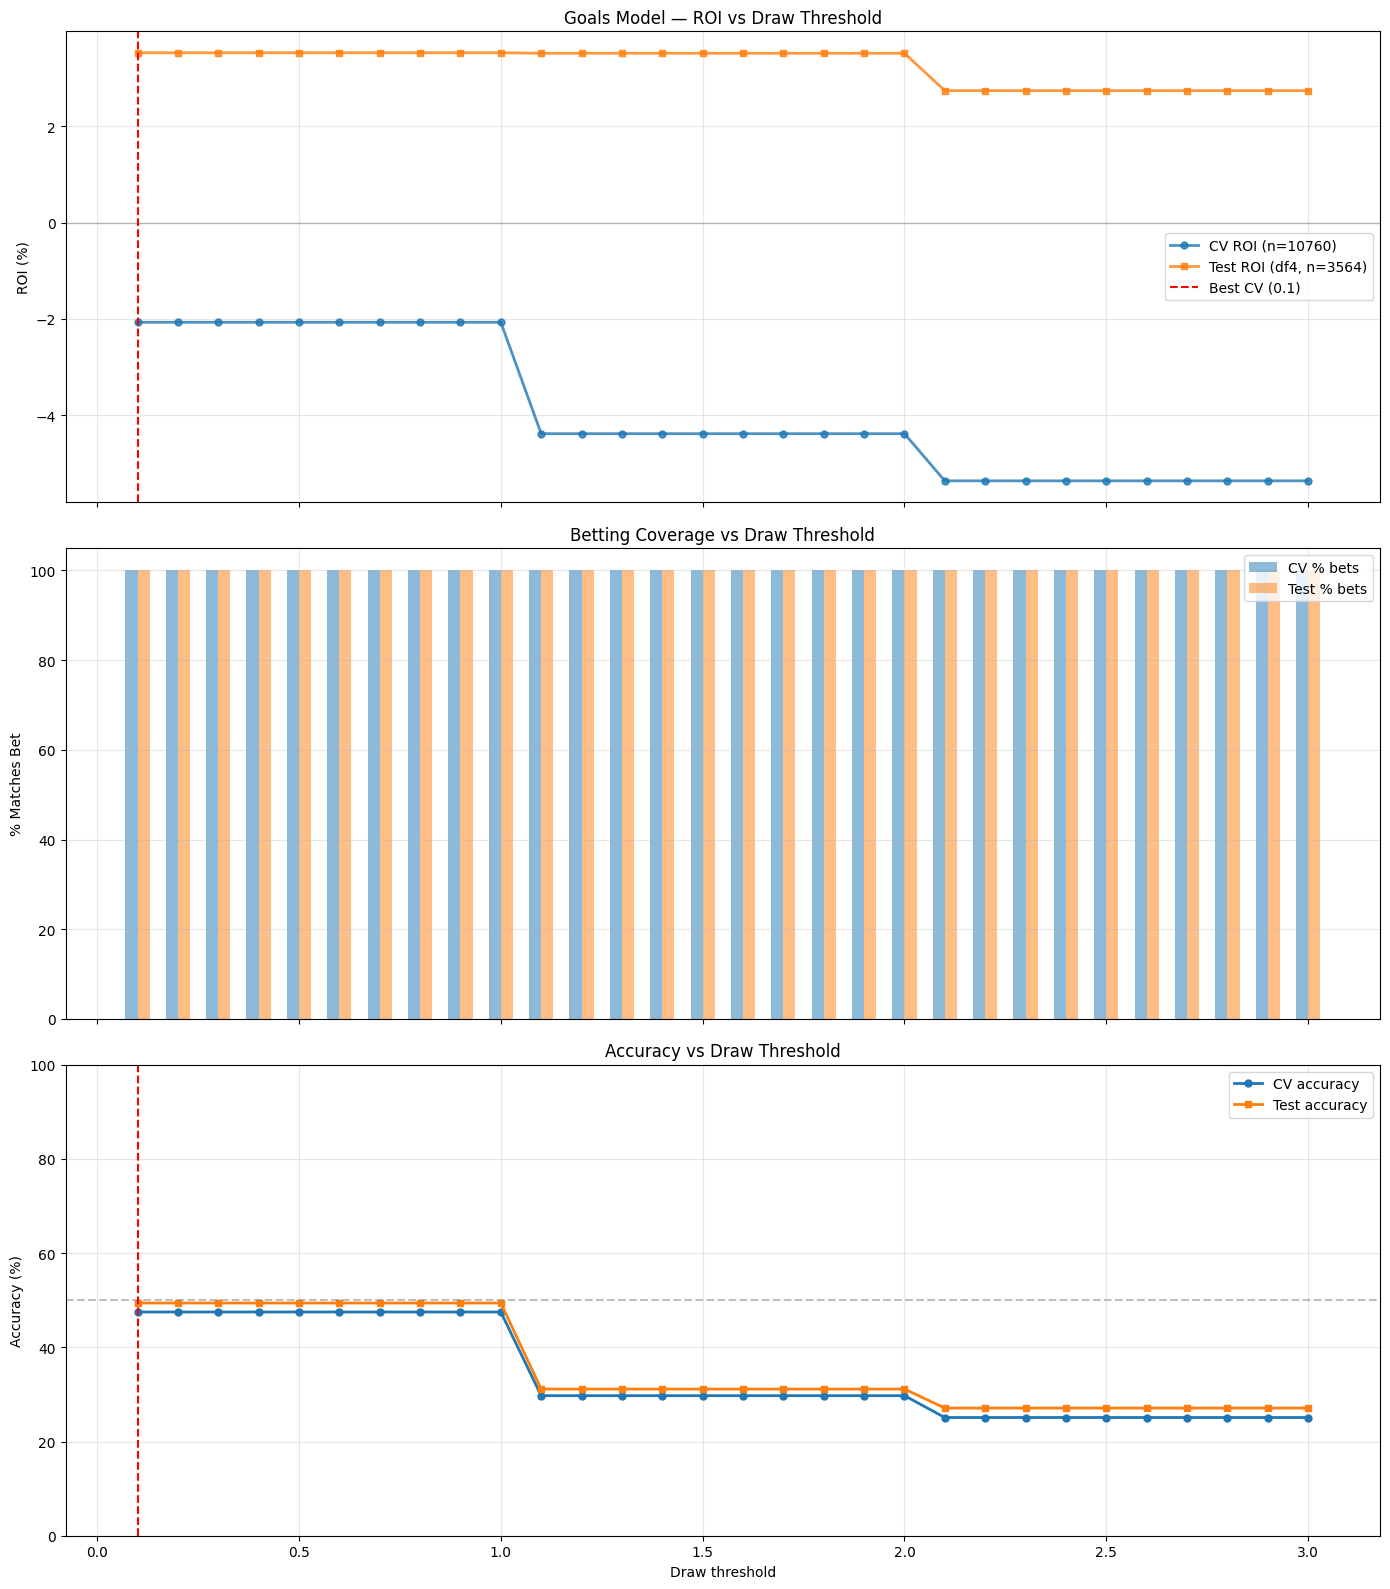

In [ ]:
# Data
thresholds_cv = [r['threshold'] for r in cv_results]
profits_cv     = [r['cv_profit_sum'] for r in cv_results]
pct_cv         = [r['pct'] for r in cv_results]
acc_cv         = [r['acc'] for r in cv_results]


thresholds_test = [r['threshold'] for r in test_results]
profits_test = [r['profit'] for r in test_results]
pct_test = [r['pct'] for r in test_results]
acc_test = [r['acc'] for r in test_results]


roi_cv = [
    (r['cv_profit_sum'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in cv_results
]

roi_test = [
    (r['profit'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in test_results
]



fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)


# ─────────────────────────────────────────
# 1. ROI CV vs TEST
# ─────────────────────────────────────────

ax = axes[0]

ax.plot(thresholds_cv,roi_cv,marker='o',markersize=5,linewidth=2,label=f'CV ROI (n={len(X_train)})',alpha=0.8)
ax.plot(thresholds_test,roi_test,marker='s',markersize=5,linewidth=2,label=f'Test ROI (df4, n={len(X_test)})',alpha=0.8)
ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV,color='red',linestyle='--',linewidth=1.5,label=f'Best CV ({BEST_CONFIDENCE_CV})')

ax.set_ylabel("ROI (%)")
ax.set_title("Goals Model — ROI vs Draw Threshold")
ax.grid(True, alpha=0.3)
ax.legend()



# ─────────────────────────────────────────
# 2. BET COVERAGE
# ─────────────────────────────────────────

ax = axes[1]

width = 0.03

ax.bar(np.array(thresholds_cv)-width/2,pct_cv,width=width,alpha=0.5,label='CV % bets')
ax.bar(np.array(thresholds_test)+width/2,pct_test,width=width,alpha=0.5,label='Test % bets')

ax.set_ylabel("% Matches Bet")
ax.set_title("Betting Coverage vs Draw Threshold")
ax.set_ylim(0,105)
ax.grid(True, alpha=0.3)
ax.legend()

# ─────────────────────────────────────────
# 3. ACCURACY
# ─────────────────────────────────────────

ax = axes[2]

ax.plot(thresholds_cv,acc_cv,marker='o',markersize=5,linewidth=2,label='CV accuracy')
ax.plot(thresholds_test,acc_test,marker='s',markersize=5,linewidth=2,label='Test accuracy')
ax.axhline(50,color='gray',linestyle='--',alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV,color='red',linestyle='--',linewidth=1.5)

ax.set_xlabel("Draw threshold")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Draw Threshold")
ax.set_ylim(0,100)
ax.grid(True, alpha=0.3)
ax.legend()


plt.tight_layout()
plt.show()

Result - hardly seen corelation, huge differences in train/test datasets

### Benchmark - win/draw/lose

In [23]:
df_train = pd.concat([df1, df2, df3], ignore_index=True)
df_test = df4.copy()

BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'

def get_Xy(df, target):
    df = df.dropna(subset=BET_COLS + [target])
    X = df[BET_COLS]
    y = df[target]
    return X, y, df

# ═══════════════════════════════════════════════════════════════════════════
# SCORER
# ═══════════════════════════════════════════════════════════════════════════
def make_winner_scorer(confidence_threshold):
    """
    Scorer logic:
      - If max(proba) < confidence_threshold → bet skipped (continue)
      - Else → placed bet on a class with the highest propability
    
    Return profit sum.
    """
    def betting_profit_winner(estimator, X, y_true):
        proba = estimator.predict_proba(X)
        classes = estimator.classes_
        confidence = proba.max(axis=1)
        predicted = classes[proba.argmax(axis=1)]
        
        X_reset = X.reset_index(drop=True)
        y_reset = np.array(y_true)
        
        profits = []
        for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
            if conf < confidence_threshold:
                continue
            
            bet_col = {1.0: 'bet_1', 0.0: 'bet_x', 2.0: 'bet_2'}[pred]
            odds = X_reset.iloc[i][bet_col]
            
            profits.append((odds - 1) if pred == true else -1)
        
        return np.sum(profits) if profits else 0.0
    
    return betting_profit_winner

# ═══════════════════════════════════════════════════════════════════════════
# EVALUATE FUNCTION
# ═══════════════════════════════════════════════════════════════════════════
def evaluate_winner_predictions(model, X, y, confidence_threshold):
    proba = model.predict_proba(X)
    classes = model.classes_
    confidence = proba.max(axis=1)
    predicted = classes[proba.argmax(axis=1)]
    
    X_reset = X.reset_index(drop=True)
    y_reset = np.array(y)
    
    profits = []
    placed = 0
    won = 0
    
    for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
        if conf < confidence_threshold:
            continue
        
        placed += 1
        
        bet_col = {1.0: 'bet_1', 0.0: 'bet_x', 2.0: 'bet_2'}[pred]
        odds = X_reset.iloc[i][bet_col]
        
        if pred == true:
            profits.append(odds - 1)
            won += 1
        else:
            profits.append(-1)
    
    total = len(y)
    profit = sum(profits)
    pct = placed / total * 100 if total > 0 else 0
    acc = won / placed * 100 if placed > 0 else 0
    
    return profit, placed, pct, acc


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# PREPARE DATA AND MODEL
# ═══════════════════════════════════════════════════════════════════════════
X_train, y_train, _ = get_Xy(df_train, TARGET_W)
X_test, y_test, _ = get_Xy(df_test, TARGET_W)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")
print(f"Test target distribution:\n{y_test.value_counts()}")

model_winner = DecisionTreeClassifier(
    max_depth=4, 
    min_samples_leaf=200, 
    random_state=42
)

cv_splits = KFold(n_splits=5, shuffle=True, random_state=42)

Train shape: (10760, 3), Test shape: (3564, 3)
Train target distribution:
winner
1.0    4594
2.0    3465
0.0    2701
Name: count, dtype: int64
Test target distribution:
winner
1.0    1548
2.0    1050
0.0     966
Name: count, dtype: int64


In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIDENCE THRESHOLDS - CROSS VALIDATION
# ═══════════════════════════════════════════════════════════════════════════
# Threshold = MIN MODELS PROPABILITY TO PLACE A BET
# 0.50 = model must have at least 50% propability to place a bet
confidence_thresholds = np.round(np.arange(0.33, 0.95, 0.02), 2)
cv_results = []

print("\n" + "="*90)
print("CROSS-VALIDATION (5-fold) - TRAINING DATA - WINNER CLASSIFICATION")
print("="*90)
print(f"{'Confidence':>11} | {'CV profit':>12} | {'CV avg/fold':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:
    scorer = make_winner_scorer(conf_threshold)
    cv_scores = cross_val_score(model_winner, X_train, y_train, cv=cv_splits, scoring=scorer)
    
    m_tmp = clone(model_winner)
    m_tmp.fit(X_train, y_train)
    profit, placed, pct, acc = evaluate_winner_predictions(m_tmp, X_train, y_train, conf_threshold)
    
    cv_results.append({
        'confidence': conf_threshold,
        'cv_profit_sum': cv_scores.sum(),
        'cv_profit_avg': cv_scores.mean(),
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{conf_threshold:>11.2f} | {cv_scores.sum():>12.2f} | {cv_scores.mean():>12.2f} | "
          f"{placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

best_cv = max(cv_results, key=lambda x: x['cv_profit_sum'])
BEST_CONFIDENCE_CV = best_cv['confidence']
print(f"\nBest confidence threshold (CV): {BEST_CONFIDENCE_CV}  (profit: {best_cv['cv_profit_sum']:.2f})")



CROSS-VALIDATION (5-fold) - TRAINING DATA - WINNER CLASSIFICATION
 Confidence |    CV profit |  CV avg/fold |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |       -98.57 |       -19.71 |    10760 |   100.0% |      53.4%
       0.35 |       -98.57 |       -19.71 |    10760 |   100.0% |      53.4%
       0.37 |      -128.22 |       -25.64 |    10760 |   100.0% |      53.4%
       0.39 |      -126.35 |       -25.27 |     9115 |    84.7% |      56.1%
       0.41 |       -70.56 |       -14.11 |     7833 |    72.8% |      58.6%
       0.43 |       -35.20 |        -7.04 |     7833 |    72.8% |      58.6%
       0.45 |       -63.81 |       -12.76 |     6450 |    59.9% |      61.6%
       0.47 |       -18.22 |        -3.64 |     6450 |    59.9% |      61.6%
       0.49 |       -45.02 |        -9.00 |     5662 |    52.6% |      63.4%
       0.51 |       -52.58 |       -10.52 |     4611 |    42.9% |      6

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# EVALUATE (df4)
# ═══════════════════════════════════════════════════════════════════════════
model_winner.fit(X_train, y_train)

test_results = []

print("\n" + "="*90)
print(f"TEST DATA (df4) - {len(X_test)} matches - WINNER CLASSIFICATION")
print("="*90)
print(f"{'Confidence':>11} | {'Profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:
    profit, placed, pct, acc = evaluate_winner_predictions(model_winner, X_test, y_test, conf_threshold)
    
    test_results.append({
        'confidence': conf_threshold,
        'profit': profit,
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{conf_threshold:>11.2f} | {profit:>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

# Najlepszy threshold na teście
best_test = max(test_results, key=lambda x: x['profit'])
BEST_CONFIDENCE_TEST = best_test['confidence']
print(f"\nBest confidence threshold (TEST): {BEST_CONFIDENCE_TEST}  (profit: {best_test['profit']:.2f})")
print(f"  Cross-Validation threshold:          {BEST_CONFIDENCE_CV}")


TEST DATA (df4) - 3564 matches - WINNER CLASSIFICATION
 Confidence |       Profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |      -108.92 |     3564 |   100.0% |      52.9%
       0.35 |      -108.92 |     3564 |   100.0% |      52.9%
       0.37 |      -108.92 |     3564 |   100.0% |      52.9%
       0.39 |       -54.80 |     3017 |    84.7% |      56.0%
       0.41 |       -39.64 |     2620 |    73.5% |      58.4%
       0.43 |       -39.64 |     2620 |    73.5% |      58.4%
       0.45 |       -22.51 |     2126 |    59.7% |      61.6%
       0.47 |       -22.51 |     2126 |    59.7% |      61.6%
       0.49 |       -10.20 |     1902 |    53.4% |      63.5%
       0.51 |        16.56 |     1555 |    43.6% |      66.9%
       0.53 |        16.56 |     1555 |    43.6% |      66.9%
       0.55 |       -15.03 |     1055 |    29.6% |      70.5%
       0.57 |       -15.03 |     1055 |    29.6

In [29]:
# Dane do wykresów
confidences_cv = [r['confidence'] for r in cv_results]
profits_cv     = [r['cv_profit_sum'] for r in cv_results]
pct_cv         = [r['pct'] for r in cv_results]
acc_cv         = [r['acc'] for r in cv_results]

confidences_test = [r['confidence'] for r in test_results]
profits_test = [r['profit'] for r in test_results]
pct_test = [r['pct'] for r in test_results]
acc_test = [r['acc'] for r in test_results]

roi_cv = [
    (r['cv_profit_sum'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in cv_results
]

roi_test = [
    (r['profit'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in test_results
]

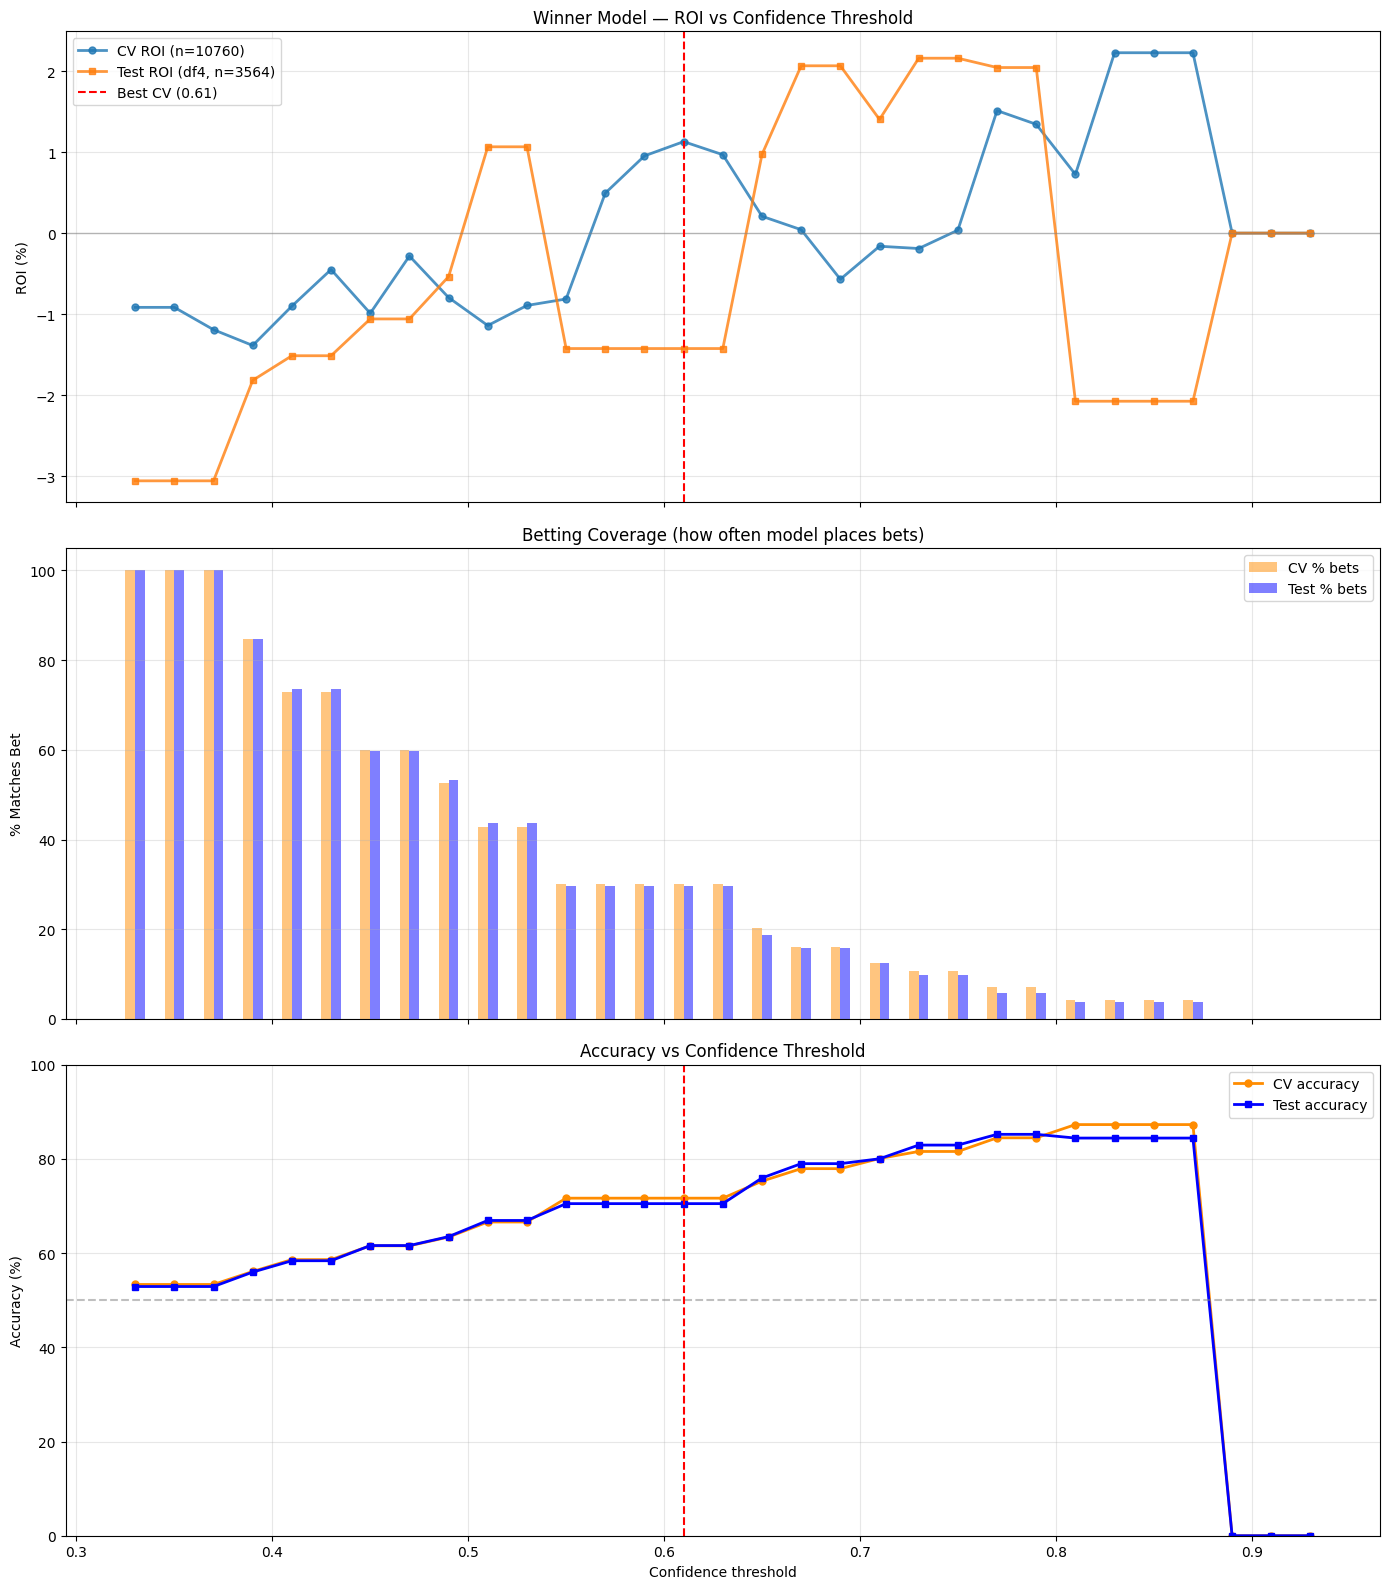

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

# ─────────────────────────────────────────────────────────────
# 1. PROFIT: CV vs TEST
# ─────────────────────────────────────────────────────────────
ax = axes[0]

ax.plot(confidences_cv, roi_cv,marker='o', markersize=5,linewidth=2,label=f'CV ROI (n={len(X_train)})',alpha=0.8)
ax.plot(confidences_test, roi_test,marker='s', markersize=5,linewidth=2,label=f'Test ROI (df4, n={len(X_test)})',alpha=0.8)

ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',linewidth=1.5, label=f'Best CV ({BEST_CONFIDENCE_CV})')

ax.set_ylabel("ROI (%)")
ax.set_title("Winner Model — ROI vs Confidence Threshold")
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 2. BET COVERAGE
# ─────────────────────────────────────────────────────────────
ax = axes[1]

width = 0.005

ax.bar(np.array(confidences_cv) - width/2,pct_cv,width=width,color='darkorange',alpha=0.5,label='CV % bets')
ax.bar(np.array(confidences_test) + width/2,pct_test,width=width,color='blue',alpha=0.5,label='Test % bets')

ax.set_ylabel("% Matches Bet")
ax.set_title("Betting Coverage (how often model places bets)")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 3. ACCURACY
# ─────────────────────────────────────────────────────────────
ax = axes[2]

ax.plot(confidences_cv, acc_cv,marker='o', markersize=5,color='darkorange', linewidth=2,label='CV accuracy')
ax.plot(confidences_test, acc_test,marker='s', markersize=5,color='blue', linewidth=2,label='Test accuracy')

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',
           linewidth=1.5)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Confidence Threshold")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()


plt.tight_layout()
plt.show()

In [ ]:
# ── TREE VISUALIZATION ─────────────────────────────────────────────────────────

def plot_model(model, title, class_names=None):
    tree = model.estimators_[0] if hasattr(model, 'estimators_') else model
    fig, ax = plt.subplots(figsize=(22, 8))
    plot_tree(tree, feature_names=BET_COLS,
              class_names=class_names,
              filled=True, rounded=True, ax=ax, fontsize=9)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=150)
    plt.show()
    print(export_text(tree, feature_names=BET_COLS))

plot_model(model_winner, "Model_Winner", class_names=['remis', 'gospodarz', 'gosc'])
plot_model(model_goals,  "Model_Goals_1_tree")

This model shows a much higher correlation between the train/test datasets, so this approach will be investigated further.

## Model - DT + RF

This section contains sub-chapters. Each sub-chapter have cells that are responsible for preparing data. After executing each sub-chapter the **Model run for all DT models** or **Model run for all RF model** should be run to get the results for respective train dataset and DecisionTree/RandomForest model

### load data - blueprint for next dataset preparations

In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════
season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']
EXCLUDE_FROM_FEATURES = ['formation']
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# SUPPORT FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════
def load_time_series(season_label: str, output_dir: str = "../data/processed") -> dict:
    path = os.path.join(output_dir, f"season_{season_label}.json")
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def team_ts_to_df(ts_data: dict, team: str) -> pd.DataFrame:
    """
    Converts team time series to DataFrame.
    
    Input (JSON):
      ts_data[team] = {
        'player_3': [7.5, 6.9, 7.8, ...],
        'attacks': [102, 129, 98, ...],
        ...
      }
    
    Output (DataFrame):
      match_number | player_3 | attacks | ...
      0            | 7.5      | 102     | ...
      1            | 6.9      | 129     | ...
      ...
    """
    if team not in ts_data:
        raise KeyError(f"Team '{team}' does not exsists in time series")
    
    team_data = ts_data[team]
    
    if not isinstance(team_data, dict):
        raise TypeError(f"Expected dictionary for {team}, recived {type(team_data)}")
    
    lengths = {key: len(val) for key, val in team_data.items() if isinstance(val, list)}
    
    if not lengths:
        raise ValueError(f"No list in team data {team}")
    
    unique_lengths = set(lengths.values())
    if len(unique_lengths) > 1:
        most_common_length = max(set(lengths.values()), key=list(lengths.values()).count)
        team_data = {k: v for k, v in team_data.items() 
                     if isinstance(v, list) and len(v) == most_common_length}
    
    df = pd.DataFrame(team_data)
    df.index.name = 'match_number'
    df.reset_index(inplace=True)
    
    return df

# ═══════════════════════════════════════════════════════════════════════════
# MAIN FUNCTION - BUILD DATASET
# ═══════════════════════════════════════════════════════════════════════════
def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    rows = []
    team_match_counter = {}
    
    df_sorted = df_raw.sort_values('date').reset_index(drop=True)
    
    print(f"Processing {len(df_sorted)} matches...")
    
    for idx, match in df_sorted.iterrows():
        team_1 = match['team_1']
        team_2 = match['team_2']
        
        # counter
        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0
        
        # current match ids (0-based)
        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]
        
        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1
        
        # skip 1st mach for each team (no history)
        if idx_1 == 0 or idx_2 == 0:
            continue
        
        # team exsists in time series
        if team_1 not in ts_data or team_2 not in ts_data:
            continue
        
        # time series to data frame
        try:
            hist_1 = team_ts_to_df(ts_data, team_1)
            hist_2 = team_ts_to_df(ts_data, team_2)
        except Exception as e:
            print(f"  Conversion ERROR: {team_1} or {team_2}: {e}")
            continue
        
        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1
        
        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue
        
        # previous match data
        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]
        
        row = {}
        
        for col in prev_1.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'home_prev_{col}'] = prev_1[col]
        
        for col in prev_2.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'away_prev_{col}'] = prev_2[col]
        
        row['home_match_number'] = idx_1 + 1  # +1 cause we start from 1
        row['away_match_number'] = idx_2 + 1
        
        for bc in BET_COLS:
            row[bc] = match[bc]
        
        # Targets
        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']
        
        # Metadata
        row['league'] = match.get('league', 'unknown')
        row['team_1'] = team_1
        row['team_2'] = team_2
        row['date'] = match['date']
        
        rows.append(row)
    
    df_result = pd.DataFrame(rows)
    print(f"  Created {len(df_result)}training rows")
    
    return df_result

# ═══════════════════════════════════════════════════════════════════════════
# LOAD RAW DATA (df1-df4)
# ═══════════════════════════════════════════════════════════════════════════
print("="*80)
print("LOAD RAW DATA")
print("="*80)

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

required_cols = ['team_1', 'team_2', 'date'] + BET_COLS + [TARGET_W] + TARGET_G
missing_cols = [c for c in required_cols if c not in df1.columns]
if missing_cols:
    print(f"\nMISSING COLUMN IN df1: {missing_cols}")
    print(f"Available columns: {list(df1.columns)}")

# ═══════════════════════════════════════════════════════════════════════════
# BUILD TRAIN DATASET
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("BUILD TRAIN DATASET")
print("="*80)

train_dfs = []

for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    print(f"\n[{label}]")
    ts_data = load_time_series(label)
    print(f"  Time series: {len(ts_data)} teams")
    
    built = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    
    print(f"  Result: {len(built)} ROWS, {built['team_1'].nunique()} unique team_1")

df_train_ts = pd.concat(train_dfs, ignore_index=True)

# ═══════════════════════════════════════════════════════════════════════════
# BUILD TEST DATASET
# ═══════════════════════════════════════════════════════════════════════════

ts_data_test = load_time_series('2023_24')
df_test_ts = build_training_rows(df4, ts_data_test)


LOAD RAW DATA

BUILD TRAIN DATASET

[2020_21]
  Time series: 201 teams
Processing 3582 matches...
  Created 3470training rows
  Result: 3470 ROWS, 201 unique team_1

[2021_22]
  Time series: 202 teams
Processing 3608 matches...
  Created 3507training rows
  Result: 3507 ROWS, 202 unique team_1

[2022_23]
  Time series: 201 teams
Processing 3570 matches...
  Created 3468training rows
  Result: 3468 ROWS, 201 unique team_1
Processing 3564 matches...
  Created 3464training rows


### All columns, exclude teams formation and odds

Just run  **model run for all DT models**

### All columns, excluded teams formation, added aggregation players

In [33]:
# ═══════════════════════════════════════════════════════════════════════════════
# GROUPPING PLAYERS BASED ON POSITION
# ═══════════════════════════════════════════════════════════════════════════════

def add_position_features(row, hist, prev_idx, prefix):

    player_cols = sorted(
        [c for c in hist.columns if re.match(r'player_\d+$', c)],
        key=lambda x: int(x.split('_')[1])
    )

    ratings = []

    for pc in player_cols:
        val = hist.iloc[prev_idx][pc]

        try:
            ratings.append(float(val))
        except:
            ratings.append(np.nan)

    ratings = np.array(ratings, dtype=float)

    if len(ratings) < 11:
        return row

    def safe_mean(x):
        return np.nanmean(x) if len(x) > 0 else np.nan

    # GK
    row[f'{prefix}_gk_rating'] = ratings[0]

    # split
    def_part = ratings[1:4]
    mid_part = ratings[4:8]
    att_part = ratings[8:11]

    row[f'{prefix}_def_rating'] = safe_mean(def_part)
    row[f'{prefix}_mid_rating'] = safe_mean(mid_part)
    row[f'{prefix}_att_rating'] = safe_mean(att_part)

    return row

In [34]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════
season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']
EXCLUDE_FROM_FEATURES = ['formation']
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# SUPPORT FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════
def load_time_series(season_label: str, output_dir: str = "../data/processed") -> dict:
    path = os.path.join(output_dir, f"season_{season_label}.json")
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def team_ts_to_df(ts_data: dict, team: str) -> pd.DataFrame:
    """
    Converts team time series to DataFrame.
    
    Input (JSON):
      ts_data[team] = {
        'player_3': [7.5, 6.9, 7.8, ...],
        'attacks': [102, 129, 98, ...],
        ...
      }
    
    Output (DataFrame):
      match_number | player_3 | attacks | ...
      0            | 7.5      | 102     | ...
      1            | 6.9      | 129     | ...
      ...
    """
    if team not in ts_data:
        raise KeyError(f"Team '{team}' does not exsists in time series")
    
    team_data = ts_data[team]
    
    if not isinstance(team_data, dict):
        raise TypeError(f"Expected dictionary for {team}, recived {type(team_data)}")
    
    lengths = {key: len(val) for key, val in team_data.items() if isinstance(val, list)}
    
    if not lengths:
        raise ValueError(f"No list in team data {team}")
    
    unique_lengths = set(lengths.values())
    if len(unique_lengths) > 1:
        most_common_length = max(set(lengths.values()), key=list(lengths.values()).count)
        team_data = {k: v for k, v in team_data.items() 
                     if isinstance(v, list) and len(v) == most_common_length}
    
    df = pd.DataFrame(team_data)
    df.index.name = 'match_number'
    df.reset_index(inplace=True)
    
    return df

# ═══════════════════════════════════════════════════════════════════════════
# MAIN FUNCTION - BUILD DATASET
# ═══════════════════════════════════════════════════════════════════════════
def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    rows = []
    team_match_counter = {}
    
    df_sorted = df_raw.sort_values('date').reset_index(drop=True)
    
    print(f"Processing {len(df_sorted)} matches...")
    
    for idx, match in df_sorted.iterrows():
        team_1 = match['team_1']
        team_2 = match['team_2']
        
        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0
        
        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]
        
        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1
        
        if idx_1 == 0 or idx_2 == 0:
            continue
        
        if team_1 not in ts_data or team_2 not in ts_data:
            continue
        
        try:
            hist_1 = team_ts_to_df(ts_data, team_1)
            hist_2 = team_ts_to_df(ts_data, team_2)
        except Exception as e:
            print(f"  Conversion ERROR: {team_1} or {team_2}: {e}")
            continue
        
        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1
        
        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue
        
        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]
        
        row = {}
        row = add_position_features(row, hist_1, prev_idx_1, "home")
        row = add_position_features(row, hist_2, prev_idx_2, "away")
        
        # Features - home team, previous match
        for col in prev_1.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'home_prev_{col}'] = prev_1[col]
        
        # Features - away team, previous match
        for col in prev_2.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'away_prev_{col}'] = prev_2[col]
        
        row['home_match_number'] = idx_1 + 1
        row['away_match_number'] = idx_2 + 1
        
        for bc in BET_COLS:
            row[bc] = match[bc]
        
        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']
        
        row['league'] = match.get('league', 'unknown')
        row['team_1'] = team_1
        row['team_2'] = team_2
        row['date'] = match['date']
        
        rows.append(row)
    
    df_result = pd.DataFrame(rows)
    print(f"  Created {len(df_result)}training rows")
    
    return df_result

# ═══════════════════════════════════════════════════════════════════════════
# LOAD RAW DATA (df1-df4)
# ═══════════════════════════════════════════════════════════════════════════
print("="*80)
print("LOAD DATA")
print("="*80)

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

# Sprawdź kolumny
required_cols = ['team_1', 'team_2', 'date'] + BET_COLS + [TARGET_W] + TARGET_G
missing_cols = [c for c in required_cols if c not in df1.columns]
if missing_cols:
    print(f"\nMISSING COLUMN IN df1: {missing_cols}")
    print(f"Available columns: {list(df1.columns)}")

# ═══════════════════════════════════════════════════════════════════════════
# BUILD TRAIN DATASET
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("BUILD TRAIN DATASET")
print("="*80)

train_dfs = []

for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    print(f"\n[{label}]")
    ts_data = load_time_series(label)
    print(f"  Time series: {len(ts_data)} TEAMS")
    
    built = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    
    print(f"  Results: {len(built)} rows, {built['team_1'].nunique()} unique team_1")

df_train_ts = pd.concat(train_dfs, ignore_index=True)

# ═══════════════════════════════════════════════════════════════════════════
# BUILD TEST DATASET
# ═══════════════════════════════════════════════════════════════════════════

ts_data_test = load_time_series('2023_24')
df_test_ts = build_training_rows(df4, ts_data_test)


LOAD DATA

BUILD TRAIN DATASET

[2020_21]
  Time series: 201 TEAMS
Processing 3582 matches...
  Created 3470training rows
  Results: 3470 rows, 201 unique team_1

[2021_22]
  Time series: 202 TEAMS
Processing 3608 matches...
  Created 3507training rows
  Results: 3507 rows, 202 unique team_1

[2022_23]
  Time series: 201 TEAMS
Processing 3570 matches...
  Created 3468training rows
  Results: 3468 rows, 201 unique team_1
Processing 3564 matches...
  Created 3464training rows


### Previous + sum of points per team , added efficiency

In [46]:
# ═══════════════════════════════════════════════════════════════════════════════
# GROUPPING PLAYERS BASED ON POSITION
# ═══════════════════════════════════════════════════════════════════════════════

def add_position_features(row, hist, prev_idx, prefix):

    player_cols = sorted(
        [c for c in hist.columns if re.match(r'player_\d+$', c)],
        key=lambda x: int(x.split('_')[1])
    )

    ratings = []

    for pc in player_cols:
        val = hist.iloc[prev_idx][pc]

        try:
            ratings.append(float(val))
        except:
            ratings.append(np.nan)

    ratings = np.array(ratings, dtype=float)

    if len(ratings) < 11:
        return row

    def safe_mean(x):
        return np.nanmean(x) if len(x) > 0 else np.nan

    # GK
    row[f'{prefix}_gk_rating'] = ratings[0]

    # split
    def_part = ratings[1:4]
    mid_part = ratings[4:8]
    att_part = ratings[8:11]

    row[f'{prefix}_def_rating'] = safe_mean(def_part)
    row[f'{prefix}_mid_rating'] = safe_mean(mid_part)
    row[f'{prefix}_att_rating'] = safe_mean(att_part)

    return row

In [47]:
def add_efficiency_features(row, prefix):
    def get(col):
        try:
            val = row.get(f"{prefix}_{col}")
            return float(val) if val is not None else 0.0
        except (TypeError, ValueError):
            return 0.0

    attacks = get("attacks")
    shots = get("shots")
    shots_on = get("shots_on_target")
    shots_off = get("shots_off_target")
    goals = get("goals")
    danger = get("dangerous_attacks")
    chances = get("goal_chances")
    possession = get("possession")
    fouls = get("fouls")
    reds = get("red_cards")

    # ─────────────────────────────────────────────
    # OFFENSIVE EFFICIENCY
    # ─────────────────────────────────────────────

    row[f"{prefix}_xg_proxy"] = chances / attacks if attacks > 0 else 0
    row[f"{prefix}_conversion_rate"] = goals / shots_on if shots_on > 0 else 0
    row[f"{prefix}_shot_quality"] = shots_on / shots if shots > 0 else 0
    row[f"{prefix}_finishing_efficiency"] = goals / attacks if attacks > 0 else 0

    # ─────────────────────────────────────────────
    # PRESSURE / CONTROL
    # ─────────────────────────────────────────────

    row[f"{prefix}_attack_pressure"] = shots_on / attacks if attacks > 0 else 0
    row[f"{prefix}_danger_ratio"] = danger / attacks if attacks > 0 else 0
    row[f"{prefix}_possession_efficiency"] = shots_on / possession if possession > 0 else 0

    # ─────────────────────────────────────────────
    # DEFENSIVE / DISCIPLINE
    # ─────────────────────────────────────────────

    row[f"{prefix}_discipline_cost"] = fouls + 3 * reds
    row[f"{prefix}_defensive_noise"] = shots_off / shots if shots > 0 else 0

    return row

In [48]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════
season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']
EXCLUDE_FROM_FEATURES = ['formation']
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# SUPPORT FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════
def load_time_series(season_label: str, output_dir: str = "../data/processed") -> dict:
    path = os.path.join(output_dir, f"season_{season_label}.json")
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def team_ts_to_df(ts_data: dict, team: str) -> pd.DataFrame:
    if team not in ts_data:
        raise KeyError(f"Team '{team}' does not exsists in time series")
    
    team_data = ts_data[team]
    
    if not isinstance(team_data, dict):
        raise TypeError(f"Expected dictionary for {team}, recived {type(team_data)}")
    
    lengths = {key: len(val) for key, val in team_data.items() if isinstance(val, list)}
    
    if not lengths:
        raise ValueError(f"No list in team data {team}")
    
    unique_lengths = set(lengths.values())
    if len(unique_lengths) > 1:
        most_common_length = max(set(lengths.values()), key=list(lengths.values()).count)
        team_data = {k: v for k, v in team_data.items() 
                     if isinstance(v, list) and len(v) == most_common_length}
    
    df = pd.DataFrame(team_data)
    df.index.name = 'match_number'
    df.reset_index(inplace=True)
    
    return df

# ═══════════════════════════════════════════════════════════════════════════
# MAIN FUNCTION - BUILD DATASET
# ═══════════════════════════════════════════════════════════════════════════
def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    team_points = {}
    rows = []
    team_match_counter = {}

    df_sorted = df_raw.sort_values('date').reset_index(drop=True)

    print(f"Processing {len(df_sorted)} matches...")

    for idx, match in df_sorted.iterrows():

        team_1 = match['team_1']
        team_2 = match['team_2']

        # init stats
        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0
            if team not in team_points:
                team_points[team] = 0

        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]

        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1

        if idx_1 == 0 or idx_2 == 0:
            continue

        if team_1 not in ts_data or team_2 not in ts_data:
            continue

        try:
            hist_1 = team_ts_to_df(ts_data, team_1)
            hist_2 = team_ts_to_df(ts_data, team_2)
        except Exception as e:
            print(f"  Conversion ERROR: {team_1} or {team_2}: {e}")
            continue

        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1

        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue

        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]

        row = {}

        # POSITION FEATURES
        row = add_position_features(row, hist_1, prev_idx_1, "home")
        row = add_position_features(row, hist_2, prev_idx_2, "away")
        
        
        # EFFICIENCY FEATURES
        row = add_efficiency_features(row, "home")
        row = add_efficiency_features(row, "away")

        # PREV MATCH FEATURES (player_* excluded)
        for col in prev_1.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'home_prev_{col}'] = prev_1[col]

        for col in prev_2.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'away_prev_{col}'] = prev_2[col]

        # POINTS FEATURE (BEFORE MATCH)
        row['home_points'] = team_points[team_1]
        row['away_points'] = team_points[team_2]

        row['home_match_number'] = idx_1 + 1
        row['away_match_number'] = idx_2 + 1

        for bc in BET_COLS:
            row[bc] = match[bc]

        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']

        row['league'] = match.get('league', 'unknown')
        row['team_1'] = team_1
        row['team_2'] = team_2
        row['date'] = match['date']

        rows.append(row)

        # UPDATE POINTS
        winner = match[TARGET_W]

        if winner == 1:
            team_points[team_1] += 3
        elif winner == 0:
            team_points[team_1] += 1
            team_points[team_2] += 1
        else:
            team_points[team_2] += 3

    df_result = pd.DataFrame(rows)
    print(f"  ✓ Created {len(df_result)} training rows")

    return df_result

# ═══════════════════════════════════════════════════════════════════════════
# LOAD RAW DATA (df1-df4)
# ═══════════════════════════════════════════════════════════════════════════
print("="*80)
print("LOAD RAW DATA")
print("="*80)

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

# Sprawdź kolumny
required_cols = ['team_1', 'team_2', 'date'] + BET_COLS + [TARGET_W] + TARGET_G
missing_cols = [c for c in required_cols if c not in df1.columns]
if missing_cols:
    print(f"\nMISSING COLUMN IN df1: {missing_cols}")
    print(f"Available columns: {list(df1.columns)}")

# ═══════════════════════════════════════════════════════════════════════════
# BUILD TRAIN DATASET
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("BUILD TRAIN DATASET")
print("="*80)

train_dfs = []

for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    print(f"\n[{label}]")
    ts_data = load_time_series(label)
    print(f"  Time series: {len(ts_data)} teams")
    
    built = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    
    print(f"  Results: {len(built)} rows, {built['team_1'].nunique()} unique team_1")

df_train_ts = pd.concat(train_dfs, ignore_index=True)

# ═══════════════════════════════════════════════════════════════════════════
# BUILD TEST DATASET
# ═══════════════════════════════════════════════════════════════════════════

ts_data_test = load_time_series('2023_24')
df_test_ts = build_training_rows(df4, ts_data_test)


LOAD RAW DATA

BUILD TRAIN DATASET

[2020_21]
  Time series: 201 teams
Processing 3582 matches...
  ✓ Created 3470 training rows
  Results: 3470 rows, 201 unique team_1

[2021_22]
  Time series: 202 teams
Processing 3608 matches...
  ✓ Created 3507 training rows
  Results: 3507 rows, 202 unique team_1

[2022_23]
  Time series: 201 teams
Processing 3570 matches...
  ✓ Created 3468 training rows
  Results: 3468 rows, 201 unique team_1
Processing 3564 matches...
  ✓ Created 3464 training rows


### Previous step + sum of total points/goals and timeseries

Prepare proper JSON for timeseries

In [59]:
'''Preapare json file for faster and more scalable dataset generation'''

def safe_div(numerator, denominator, precision=4):
    try:
        n = float(numerator) if numerator is not None else 0.0
        d = float(denominator) if denominator is not None else 0.0
        if d <= 0:
            return 0.0
        return round(n / d, precision)
    except (ValueError, TypeError):
        return 0.0

def get_formation_style(formation_str: str):
    if pd.isna(formation_str) or not isinstance(formation_str, str):
        return "balanced"
    nums = [int(x) for x in re.findall(r'\d+', formation_str)]
    if not nums: return "balanced"
    n_def, n_att = nums[0], nums[-1]
    if n_def >= 5: return "defensive"
    if n_att >= 3: return "offensive"
    return "balanced"

def get_match_points(winner_val, is_team_1):
    if winner_val == 0: return 1
    if (winner_val == 1 and is_team_1) or (winner_val == 2 and not is_team_1):
        return 3
    return 0


def engineer_features_full_pipeline(json_path: str, csv_path: str, output_path: str):
    with open(json_path, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)
    
    df_csv = pd.read_csv(csv_path).sort_values('date')

    # 1. DATA MAPPING - CSV source (Points and Lost goals)
    csv_history = {team: {'points': [], 'goals_lost': []} for team in raw_data.keys()}
    
    for _, row in df_csv.iterrows():
        t1, t2 = row['team_1'], row['team_2']
        g1, g2 = row['goals_1'], row['goals_2']
        w = row['winner']
        
        if t1 in csv_history:
            csv_history[t1]['points'].append(get_match_points(w, True))
            csv_history[t1]['goals_lost'].append(g2) # goals lost T1 = goals scored T2
        if t2 in csv_history:
            csv_history[t2]['points'].append(get_match_points(w, False))
            csv_history[t2]['goals_lost'].append(g1)

    engineered_data = {}

    # 2. TEAMS PROCESSING
    for team_name, team_stats in raw_data.items():
        if not team_stats: continue
        
        first_stat = next(iter(team_stats))
        num_matches = len(team_stats[first_stat])
        
        new_stats = {k: v for k, v in team_stats.items() if not k.startswith('player_')}
        
        # Feature list
        derived = {
            'gk_rating': [], 'def_rating': [], 'mid_rating': [], 'att_rating': [],
            'team_rating': [], 'formation_style': [], 
            'attack_efficiency': [], 'defense_efficiency': [],
            'match_points': [], 'goals_lost': [],
            'discipline_cost': [], 'danger_ratio': [], 'attack_pressure': [], 
            'possession_efficiency': [], 'shot_quality': [], 
            'conversion_rate': [], 'xg_proxy': []
        }

        player_cols = [f'player_{i}' for i in range(11)]

        for i in range(num_matches):
            # A. download golas - goals and points
            pts = csv_history[team_name]['points'][i] if i < len(csv_history[team_name]['points']) else 0
            gl = csv_history[team_name]['goals_lost'][i] if i < len(csv_history[team_name]['goals_lost']) else 0
            
            derived['match_points'].append(pts)
            derived['goals_lost'].append(gl)

            # B. efficiency
            
            # Attack: goals/attacks
            g = team_stats.get('goals', [0])[i]
            a = team_stats.get('attacks', [0])[i]
            derived['attack_efficiency'].append(safe_div(g, a))

            # Defensive: goals lost / attacks
            derived['defense_efficiency'].append(safe_div(gl, a))

            # Defensive: Goals lost (CSV source) / enemy attacks (json, if exsist)
            # B. efficiency
            g = team_stats.get('goals', [0])[i]
            a = team_stats.get('attacks', [0])[i]
            da = team_stats.get('dangerous_attacks', [0])[i]
            sh_on = team_stats.get('shots_on_target', [0])[i]
            sh_off = team_stats.get('shots_off_target', [0])[i]
            chances = team_stats.get('goal_chances', [0])[i]
            poss = team_stats.get('possession', [0])[i]
            yellow = team_stats.get('yellow_cards', [0])[i] if 'yellow_cards' in team_stats else 0
            red = team_stats.get('red_cards', [0])[i] if 'red_cards' in team_stats else 0

            # new columns computing
            derived['discipline_cost'].append((yellow * 1) + (red * 3))
            derived['danger_ratio'].append(safe_div(da, a))
            derived['attack_pressure'].append(safe_div(chances, a))
            derived['possession_efficiency'].append(safe_div(g, poss))
            derived['shot_quality'].append(safe_div(chances, (sh_on + sh_off)))
            derived['conversion_rate'].append(safe_div(g, sh_on))
            xg = round((sh_on * 0.3) + (chances * 0.4), 4)
            
            
            derived['xg_proxy'].append(xg)
            # C. formation
            f_str = team_stats.get('formation', [''])[i]
            derived['formation_style'].append(get_formation_style(f_str))

            # D. ratings (Team, GK, DEF, MID, ATT)
            row_ratings = []
            for p_col in player_cols:
                try:
                    v = team_stats[p_col][i]
                    row_ratings.append(float(v) if v is not None else np.nan)
                except: row_ratings.append(np.nan)

            if len(row_ratings) >= 11:
                # team avg (0-10)
                derived['team_rating'].append(np.nanmean(row_ratings))
                # split 1-3-4-3
                derived['gk_rating'].append(row_ratings[0])
                derived['def_rating'].append(np.nanmean(row_ratings[1:4]))
                derived['mid_rating'].append(np.nanmean(row_ratings[4:8]))
                derived['att_rating'].append(np.nanmean(row_ratings[8:11]))
            else:
                for k in ['team_rating', 'gk_rating', 'def_rating', 'mid_rating', 'att_rating']:
                    derived[k].append(np.nan)

        new_stats.update(derived)
        engineered_data[team_name] = new_stats

    # 3. save
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(engineered_data, f, indent=2, ensure_ascii=False)
    print(f"Finished: {output_path}")

INPUT_DIR = Path(r"..\data\processed")
CSV_DIR = Path(r"..\data\transformed_data")

files_config = [
    ('season_2020_21.json', '20_21_transformed.csv'),
    ('season_2021_22.json', '21_22_transformed.csv'),
    ('season_2022_23.json', '22_23_transformed.csv'),
    ('season_2023_24.json', '23_24_transformed.csv')
]

for json_n, csv_n in files_config:
    j, c = INPUT_DIR / json_n, CSV_DIR / csv_n
    if j.exists() and c.exists():
        engineer_features_full_pipeline(str(j), str(c), str(j).replace('.json', '_engineered.json'))

Finished: ..\data\processed\season_2020_21_engineered.json
Finished: ..\data\processed\season_2021_22_engineered.json
Finished: ..\data\processed\season_2022_23_engineered.json
Finished: ..\data\processed\season_2023_24_engineered.json


In [60]:
# use example / inspect
import json
import numpy as np

def inspect_engineered_team(json_path, target_team=None):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    if target_team is None:
        target_team = list(data.keys())[0]
        
    if target_team not in data:
        print(f"Could not find the team: {target_team}")
        return

    team_stats = data[target_team]
    
    print(f"COLUMN ANALYSYS FOR THE TEAM: {target_team}")
    print("=" * 60)
    print(f"{'COL NAME':<25} | {'FIRST 3 VALUES'}")
    print("-" * 60)

    for col in sorted(team_stats.keys()):
        values = team_stats[col]
        
        if isinstance(values, list) and len(values) > 0:
            preview = values[:3]
            preview = [round(v, 4) if isinstance(v, float) else v for v in preview]
            print(f"{col:<25} | {preview}")
        else:
            print(f"{col:<25} | {values}")

    print("-" * 60)
    print(f"Column count: {len(team_stats.keys())}")
    print("=" * 60)

FILE_PATH = r"..\data\processed\season_2020_21_engineered.json"
inspect_engineered_team(FILE_PATH, "Alkmaar")

COLUMN ANALYSYS FOR THE TEAM: Alkmaar
COL NAME                  | FIRST 3 VALUES
------------------------------------------------------------
att_rating                | [8.2333, 6.9, 6.6667]
attack_efficiency         | [0.049, 0.0, 0.0102]
attack_pressure           | [0.2549, 0.0853, 0.0816]
attacks                   | [102.0, 129.0, 98.0]
conversion_rate           | [0.5556, 0.0, 0.2]
danger_ratio              | [0.7157, 0.3178, 0.3163]
dangerous_attacks         | [73.0, 41.0, 31.0]
day_of_week               | []
def_rating                | [7.9333, 7.2, 7.3667]
defense_efficiency        | [0.0098, 0.0233, 0.0408]
discipline_cost           | [0.0, 0.0, 3.0]
formation                 | ['4 - 3 - 3', '4 - 2 - 3 - 1', '4 - 3 - 3']
formation_style           | ['offensive', 'balanced', 'offensive']
fouls                     | [7.0, 12.0, 8.0]
gk_rating                 | [6.7, 6.5, 7.6]
goal_chances              | [26.0, 11.0, 8.0]
goalkeeper_saves          | [2.0, 1.0, 5.0]
goals         

In [61]:
def add_rolling_aggregates_to_engineered(
    engineered_path: str,
    output_path: str,
    windows: list = [3, 5, 10],
    exclude_cols: set = {'formation', 'day_of_week', 'month', 'formation_style'}
):
    with open(engineered_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    output = {}

    for team_name, team_stats in data.items():
        if not team_stats:
            continue

        lengths = {k: len(v) for k, v in team_stats.items() if isinstance(v, list)}
        if not lengths:
            continue
        num_matches = max(lengths.values())

        CATEGORICAL_COLS = {'formation_style'}

        numeric_cols = [
            col for col, vals in team_stats.items()
            if isinstance(vals, list)
            and col not in exclude_cols
            and col not in CATEGORICAL_COLS
            and len(vals) == num_matches
        ]

        categorical_cols = [
            col for col in CATEGORICAL_COLS
            if col in team_stats
            and isinstance(team_stats[col], list)
            and col not in exclude_cols
            and len(team_stats[col]) == num_matches
        ]

        new_stats = {
            k: v for k, v in team_stats.items()
            if k not in exclude_cols
        }

        # ── ROLLING AVERAGES ──────────────────────────────────────────────
        for n in windows:
            for col in numeric_cols:
                vals = team_stats[col]
                rolled = []
                for i in range(num_matches):
                    window = vals[max(0, i - n + 1): i + 1]      # last N BEFORE match i
                    numeric_window = []
                    for v in window:
                        try:
                            fv = float(v)
                            if not np.isnan(fv):
                                numeric_window.append(fv)
                        except (TypeError, ValueError):
                            pass
                    rolled.append(round(np.mean(numeric_window), 4) if numeric_window else None)
                new_stats[f'avg{n}_{col}'] = rolled

            for col in categorical_cols:
                vals = team_stats[col]
                rolled = []
                for i in range(num_matches):
                    window = [v for v in vals[max(0, i - n + 1): i + 1] if v is not None]
                    if not window:
                        rolled.append(None)
                        continue
                    counts = {}
                    for v in window:
                        counts[v] = counts.get(v, 0) + 1
                    max_count = max(counts.values())
                    candidates = [v for v, c in counts.items() if c == max_count]
                    if len(candidates) == 1:
                        rolled.append(candidates[0])
                    else:
                        for v in reversed(window):
                            if v in candidates:
                                rolled.append(v)
                                break
                new_stats[f'mode{n}_{col}'] = rolled

        # ── CUMULATIVE (state BEFORE match i) ────────────────────────────
        # cum_points: sum of match_points from previous matches 0..i-1
        if 'match_points' in team_stats and len(team_stats['match_points']) == num_matches:
            pts_list = team_stats['match_points']
            cum_pts = []
            running = 0
            for i in range(num_matches):
                cum_pts.append(running)          # state before match i
                try:
                    running += float(pts_list[i]) if pts_list[i] is not None else 0
                except (TypeError, ValueError):
                    pass
            new_stats['cum_points'] = cum_pts

        # cum_goals: sum of goals from previous matches 0..i-1
        if 'goals' in team_stats and len(team_stats['goals']) == num_matches:
            goals_list = team_stats['goals']
            cum_goals = []
            running = 0
            for i in range(num_matches):
                cum_goals.append(running)
                try:
                    running += float(goals_list[i]) if goals_list[i] is not None else 0
                except (TypeError, ValueError):
                    pass
            new_stats['cum_goals'] = cum_goals

        output[team_name] = new_stats

    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(output, f, indent=2, ensure_ascii=False)

    print(f"Saved: {output_path}")
    first_team = next(iter(output))
    orig_cols = len(data[first_team])
    new_cols  = len(output[first_team])
    print(f"   Columns: {orig_cols} → {new_cols} (+{new_cols - orig_cols} new features)")


# ── RUN ──────────────────────────────────────────────────────────
INPUT_DIR = Path(r"..\data\processed")

for label in ['2020_21', '2021_22', '2022_23', '2023_24']:
    eng_path   = INPUT_DIR / f"season_{label}_engineered.json"
    final_path = INPUT_DIR / f"season_{label}_final.json"

    if eng_path.exists():
        print(f"\n[{label}]")
        add_rolling_aggregates_to_engineered(
            engineered_path=str(eng_path),
            output_path=str(final_path),
            windows=[3, 5, 10],
            exclude_cols={'formation', 'day_of_week', 'month', 'formation_style'}
        )
    else:
        print(f"Could not find a file: {eng_path}")


[2020_21]
Saved: ..\data\processed\season_2020_21_final.json
   Columns: 32 → 114 (+82 new features)

[2021_22]
Saved: ..\data\processed\season_2021_22_final.json
   Columns: 32 → 114 (+82 new features)

[2022_23]
Saved: ..\data\processed\season_2022_23_final.json
   Columns: 32 → 114 (+82 new features)

[2023_24]
Saved: ..\data\processed\season_2023_24_final.json
   Columns: 32 → 114 (+82 new features)


In [62]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════
season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']

EXCLUDE_FROM_FEATURES = {'formation', 'day_of_week', 'month', 'formation_style'} | \
                        {f'avg{n}_formation_style' for n in [3, 5, 10]} | \
                        {f'mode{n}_formation_style' for n in [3, 5, 10]}

BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# SUPPORT FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════

def load_time_series(season_label: str, output_dir: str = "../data/processed") -> dict:
    path = os.path.join(output_dir, f"season_{season_label}_final.json")
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def team_ts_to_df(ts_data: dict, team: str) -> pd.DataFrame:
    if team not in ts_data:
        raise KeyError(f"Team '{team}' does not exsists in time series")

    team_data = ts_data[team]

    if not isinstance(team_data, dict):
        raise TypeError(f"Expected dictionary for {team}, recived {type(team_data)}")

    lengths = {k: len(v) for k, v in team_data.items() if isinstance(v, list)}
    if not lengths:
        raise ValueError(f"No list in team data {team}")

    if len(set(lengths.values())) > 1:
        most_common = max(set(lengths.values()), key=list(lengths.values()).count)
        team_data = {k: v for k, v in team_data.items()
                     if isinstance(v, list) and len(v) == most_common}

    df = pd.DataFrame(team_data)
    df.index.name = 'match_number'
    df.reset_index(inplace=True)
    return df

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MAIN FUNCTION - BUILD DATASET
# ═══════════════════════════════════════════════════════════════════════════

def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    rows = []
    team_match_counter = {}
    ts_cache = {}

    df_sorted = df_raw.sort_values('date').reset_index(drop=True)
    print(f"Processing {len(df_sorted)} matches...")

    for _, match in df_sorted.iterrows():
        t1 = match['team_1']
        t2 = match['team_2']

        for t in [t1, t2]:
            if t not in team_match_counter:
                team_match_counter[t] = 0

        idx_1 = team_match_counter[t1]
        idx_2 = team_match_counter[t2]

        team_match_counter[t1] += 1
        team_match_counter[t2] += 1

        # 1st teams match - skipped as no history
        if idx_1 == 0 or idx_2 == 0:
            continue

        if t1 not in ts_data or t2 not in ts_data:
            continue

        try:
            if t1 not in ts_cache:
                ts_cache[t1] = team_ts_to_df(ts_data, t1)
            if t2 not in ts_cache:
                ts_cache[t2] = team_ts_to_df(ts_data, t2)
        except Exception as e:
            print(f"  Conversion ERROR for {t1} or {t2}: {e}")
            continue

        hist_1 = ts_cache[t1]
        hist_2 = ts_cache[t2]

        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1

        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue

        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]

        row = {}

        # JSON features
        skip = EXCLUDE_FROM_FEATURES | {'match_number'}

        for col in prev_1.index:
            if col not in skip:
                row[f'home_{col}'] = prev_1[col]

        for col in prev_2.index:
            if col not in skip:
                row[f'away_{col}'] = prev_2[col]

        row['home_match_number'] = idx_1
        row['away_match_number'] = idx_2

        for bc in BET_COLS:
            row[bc] = match[bc]

        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']

        row['team_1'] = t1
        row['team_2'] = t2
        row['date'] = match['date']
        row['league'] = match.get('league', 'unknown')

        rows.append(row)

    df_result = pd.DataFrame(rows)
    print(f"  Created {len(df_result)} training rows")
    return df_result


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# LOAD CSV
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("LOAD DATA")
print("=" * 80)

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

required_cols = ['team_1', 'team_2', 'date'] + BET_COLS + [TARGET_W] + TARGET_G
missing = [c for c in required_cols if c not in df1.columns]
if missing:
    print(f"Missing columns in df1: {missing}")


# ═══════════════════════════════════════════════════════════════════════════
# BUILD TRAIN DATASET
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("BUILD TRAIN DATASET")
print("="*80)

train_dfs = []
for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    print(f"\n[{label}]")
    ts_data = load_time_series(label)
    print(f"  Time series: {len(ts_data)} teams")
    built = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)

df_train = pd.concat(train_dfs, ignore_index=True)
print(f"\nTraining dataset: {len(df_train)} rows, {df_train.shape[1]} cols")

print("\n" + "=" * 80)
print("BUILD TEST DATASET")
print("=" * 80)

ts_data_test = load_time_series('2023_24')
df_test = build_training_rows(df4, ts_data_test)
print(f"Test dataset: {len(df_test)} rows, {df_test.shape[1]} cols")

LOAD DATA

BUILD TRAIN DATASET

[2020_21]
  Time series: 201 drużyn
Processing 3582 matches...
  Created 3470 training rows

[2021_22]
  Time series: 202 drużyn
Processing 3608 matches...
  Created 3507 training rows

[2022_23]
  Time series: 201 drużyn
Processing 3570 matches...
  Created 3468 training rows

Training dataset: 10445 rows, 240 cols

BUILD TEST DATASET
Processing 3564 matches...
  Created 3464 training rows
Test dataset: 3464 rows, 240 cols


In [65]:
df_test.shape

(3464, 240)

In [66]:
# ============================================
# 1. SUMMARY
# ============================================

print("\n" + "="*80)
print("NaN SUMMARY - TRAIN")
print("="*80)

nan_counts = df_train_ts.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

for col, count in nan_counts.items():
    pct = count / len(df_train_ts) * 100
    print(f"{col:<40} | NA: {count:>6} | {pct:>6.2f}%")

print(f"\nTOTAL NaNs: {nan_counts.sum()}")


print("\n" + "="*80)
print("NaN SUMMARY - TEST")
print("="*80)

nan_counts_test = df_test.isna().sum()
nan_counts_test = nan_counts_test[nan_counts_test > 0].sort_values(ascending=False)

for col, count in nan_counts_test.items():
    pct = count / len(df_test) * 100
    print(f"{col:<40} | NA: {count:>6} | {pct:>6.2f}%")

print(f"\nTOTAL NaNs: {nan_counts_test.sum()}")


# ============================================
# 2. HEAD WITH ALL COLS
# ============================================

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

sample_team = df_train_ts['team_1'].iloc[0]

print("\n" + "="*80)
print(f"SAMPLE TEAM: {sample_team}")
print("="*80)

sample_df = df_train_ts[df_train_ts['team_1'] == sample_team].head(5)

print(sample_df.to_string(index=False))


NaN SUMMARY - TRAIN

TOTAL NaNs: 0

NaN SUMMARY - TEST

TOTAL NaNs: 0

SAMPLE TEAM: Motherwell
 home_gk_rating  home_def_rating  home_mid_rating  home_att_rating  away_gk_rating  away_def_rating  away_mid_rating  away_att_rating  home_xg_proxy  home_conversion_rate  home_shot_quality  home_finishing_efficiency  home_attack_pressure  home_danger_ratio  home_possession_efficiency  home_discipline_cost  home_defensive_noise  away_xg_proxy  away_conversion_rate  away_shot_quality  away_finishing_efficiency  away_attack_pressure  away_danger_ratio  away_possession_efficiency  away_discipline_cost  away_defensive_noise  home_prev_attacks  home_prev_goal_chances  home_prev_shots_off_target  home_prev_shots  home_prev_dangerous_attacks  home_prev_red_cards  home_prev_shots_on_target  home_prev_goals  home_prev_possession  home_prev_fouls  home_prev_goalkeeper_saves  home_prev_offsides  away_prev_attacks  away_prev_goal_chances  away_prev_shots_off_target  away_prev_shots  away_prev_dangerous_

In [67]:
cols_to_drop = [c for c in df_train.columns if 'formation_style' in c]
df_train = df_train.drop(columns=cols_to_drop)
df_test  = df_test.drop(columns=cols_to_drop)
print(f"Removed {len(cols_to_drop)} columns: {cols_to_drop}")

Removed 0 columns: []


In [68]:
df_test.loc[:, df_test.columns.str.contains('avg')].head()

,home_avg3_attacks,home_avg3_goal_chances,home_avg3_shots_off_target,home_avg3_shots,home_avg3_dangerous_attacks,home_avg3_red_cards,home_avg3_shots_on_target,home_avg3_goals,home_avg3_possession,home_avg3_fouls,home_avg3_goalkeeper_saves,home_avg3_offsides,home_avg3_gk_rating,home_avg3_def_rating,home_avg3_mid_rating,home_avg3_att_rating,home_avg3_team_rating,home_avg3_attack_efficiency,home_avg3_defense_efficiency,home_avg3_match_points,home_avg3_goals_lost,home_avg3_discipline_cost,home_avg3_danger_ratio,home_avg3_attack_pressure,home_avg3_possession_efficiency,home_avg3_shot_quality,home_avg3_conversion_rate,home_avg3_xg_proxy,home_avg5_attacks,home_avg5_goal_chances,home_avg5_shots_off_target,home_avg5_shots,home_avg5_dangerous_attacks,home_avg5_red_cards,home_avg5_shots_on_target,home_avg5_goals,home_avg5_possession,home_avg5_fouls,home_avg5_goalkeeper_saves,home_avg5_offsides,home_avg5_gk_rating,home_avg5_def_rating,home_avg5_mid_rating,home_avg5_att_rating,home_avg5_team_rating,home_avg5_attack_efficiency,home_avg5_defense_efficiency,home_avg5_match_points,home_avg5_goals_lost,home_avg5_discipline_cost,home_avg5_danger_ratio,home_avg5_attack_pressure,home_avg5_possession_efficiency,home_avg5_shot_quality,home_avg5_conversion_rate,home_avg5_xg_proxy,home_avg10_attacks,home_avg10_goal_chances,home_avg10_shots_off_target,home_avg10_shots,home_avg10_dangerous_attacks,home_avg10_red_cards,home_avg10_shots_on_target,home_avg10_goals,home_avg10_possession,home_avg10_fouls,home_avg10_goalkeeper_saves,home_avg10_offsides,home_avg10_gk_rating,home_avg10_def_rating,home_avg10_mid_rating,home_avg10_att_rating,home_avg10_team_rating,home_avg10_attack_efficiency,home_avg10_defense_efficiency,home_avg10_match_points,home_avg10_goals_lost,home_avg10_discipline_cost,home_avg10_danger_ratio,home_avg10_attack_pressure,home_avg10_possession_efficiency,home_avg10_shot_quality,home_avg10_conversion_rate,home_avg10_xg_proxy,away_avg3_attacks,away_avg3_goal_chances,away_avg3_shots_off_target,away_avg3_shots,away_avg3_dangerous_attacks,away_avg3_red_cards,away_avg3_shots_on_target,away_avg3_goals,away_avg3_possession,away_avg3_fouls,away_avg3_goalkeeper_saves,away_avg3_offsides,away_avg3_gk_rating,away_avg3_def_rating,away_avg3_mid_rating,away_avg3_att_rating,away_avg3_team_rating,away_avg3_attack_efficiency,away_avg3_defense_efficiency,away_avg3_match_points,away_avg3_goals_lost,away_avg3_discipline_cost,away_avg3_danger_ratio,away_avg3_attack_pressure,away_avg3_possession_efficiency,away_avg3_shot_quality,away_avg3_conversion_rate,away_avg3_xg_proxy,away_avg5_attacks,away_avg5_goal_chances,away_avg5_shots_off_target,away_avg5_shots,away_avg5_dangerous_attacks,away_avg5_red_cards,away_avg5_shots_on_target,away_avg5_goals,away_avg5_possession,away_avg5_fouls,away_avg5_goalkeeper_saves,away_avg5_offsides,away_avg5_gk_rating,away_avg5_def_rating,away_avg5_mid_rating,away_avg5_att_rating,away_avg5_team_rating,away_avg5_attack_efficiency,away_avg5_defense_efficiency,away_avg5_match_points,away_avg5_goals_lost,away_avg5_discipline_cost,away_avg5_danger_ratio,away_avg5_attack_pressure,away_avg5_possession_efficiency,away_avg5_shot_quality,away_avg5_conversion_rate,away_avg5_xg_proxy,away_avg10_attacks,away_avg10_goal_chances,away_avg10_shots_off_target,away_avg10_shots,away_avg10_dangerous_attacks,away_avg10_red_cards,away_avg10_shots_on_target,away_avg10_goals,away_avg10_possession,away_avg10_fouls,away_avg10_goalkeeper_saves,away_avg10_offsides,away_avg10_gk_rating,away_avg10_def_rating,away_avg10_mid_rating,away_avg10_att_rating,away_avg10_team_rating,away_avg10_attack_efficiency,away_avg10_defense_efficiency,away_avg10_match_points,away_avg10_goals_lost,away_avg10_discipline_cost,away_avg10_danger_ratio,away_avg10_attack_pressure,away_avg10_possession_efficiency,away_avg10_shot_quality,away_avg10_conversion_rate,away_avg10_xg_proxy
0,96.0,15.0,11.0,15.0,67.0,0.0,4.0,2.0,54.0,10.0,0.0,0.0,6.5,7.5000,7.150,7.2667,7.2182,0.0208,0.0208,0.0,2.0,0.0,0

### Prev. step + replacing home/away to differences

In [78]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════
season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']

EXCLUDE_FROM_FEATURES = {'formation', 'day_of_week', 'month', 'formation_style'} | \
                        {f'avg{n}_formation_style' for n in [3, 5, 10]} | \
                        {f'mode{n}_formation_style' for n in [3, 5, 10]}

BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# SUPPORT FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════

def load_time_series(season_label: str, output_dir: str = "../data/processed") -> dict:
    path = os.path.join(output_dir, f"season_{season_label}_final.json")
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def team_ts_to_df(ts_data: dict, team: str) -> pd.DataFrame:
    if team not in ts_data:
        raise KeyError(f"Team '{team}' does not exsists in time series")
    
    team_data = ts_data[team]
    
    if not isinstance(team_data, dict):
        raise TypeError(f"Expected dictionary for {team}, recived {type(team_data)}")
    
    lengths = {key: len(val) for key, val in team_data.items() if isinstance(val, list)}
    
    if not lengths:
        raise ValueError(f"No list in team data {team}")

    if len(set(lengths.values())) > 1:
        most_common = max(set(lengths.values()), key=list(lengths.values()).count)
        team_data = {k: v for k, v in team_data.items()
                     if isinstance(v, list) and len(v) == most_common}

    df = pd.DataFrame(team_data)
    df.index.name = 'match_number'
    df.reset_index(inplace=True)
    return df


In [79]:
# ═══════════════════════════════════════════════════════════════════════════
# MAIN FUNCTION - BUILD DATASET
# ═══════════════════════════════════════════════════════════════════════════

def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    rows = []
    team_match_counter = {}
    ts_cache = {}

    df_sorted = df_raw.sort_values('date').reset_index(drop=True)
    print(f"Processing {len(df_sorted)} matches...")

    for _, match in df_sorted.iterrows():
        t1 = match['team_1']
        t2 = match['team_2']

        for t in [t1, t2]:
            if t not in team_match_counter:
                team_match_counter[t] = 0

        idx_1 = team_match_counter[t1]
        idx_2 = team_match_counter[t2]

        team_match_counter[t1] += 1
        team_match_counter[t2] += 1

        if idx_1 == 0 or idx_2 == 0:
            continue

        if t1 not in ts_data or t2 not in ts_data:
            continue

        try:
            if t1 not in ts_cache:
                ts_cache[t1] = team_ts_to_df(ts_data, t1)
            if t2 not in ts_cache:
                ts_cache[t2] = team_ts_to_df(ts_data, t2)
        except Exception as e:
            print(f"  Conversion ERROR for {t1} or {t2}: {e}")
            continue

        hist_1 = ts_cache[t1]
        hist_2 = ts_cache[t2]

        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1

        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue

        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]

        row = {}

        skip = EXCLUDE_FROM_FEATURES | {'match_number'}

        for col in prev_1.index:
            if col not in skip:
                row[f'home_{col}'] = prev_1[col]

        for col in prev_2.index:
            if col not in skip:
                row[f'away_{col}'] = prev_2[col]

        row['home_match_number'] = idx_1
        row['away_match_number'] = idx_2

        # bets
        for bc in BET_COLS:
            row[bc] = match[bc]

        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']

        row['team_1'] = t1
        row['team_2'] = t2
        row['date'] = match['date']
        row['league'] = match.get('league', 'unknown')

        rows.append(row)

    df_result = pd.DataFrame(rows)
    print(f"  Created {len(df_result)} training rows")
    return df_result


In [80]:
# ═══════════════════════════════════════════════════════════════════════════
# LOAD CSV
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("LOAD RAW DATA")
print("=" * 80)

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

required_cols = ['team_1', 'team_2', 'date'] + BET_COLS + [TARGET_W] + TARGET_G
missing = [c for c in required_cols if c not in df1.columns]
if missing:
    print(f"\nMISSING COLUMN IN df1: {missing_cols}")

# ═══════════════════════════════════════════════════════════════════════════
# BUILD TRAIN DATASET
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("BUILD TRAIN DATASET")
print("="*80)


train_dfs = []
for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    print(f"\n[{label}]")
    ts_data = load_time_series(label)
    print(f"  Time series: {len(ts_data)} teams")
    built = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)

df_train = pd.concat(train_dfs, ignore_index=True)
print(f"\nTraining dataset: {len(df_train)} rows, {df_train.shape[1]} cols")

print("\n" + "=" * 80)
print("BUILD TEST DATASET")
print("=" * 80)

ts_data_test = load_time_series('2023_24')
df_test = build_training_rows(df4, ts_data_test)
print(f"Test dataset: {len(df_test)} rows, {df_test.shape[1]} cols")

LOAD RAW DATA

BUILD TRAIN DATASET

[2020_21]
  Time series: 201 teams
Processing 3582 matches...
  Created 3470 training rows

[2021_22]
  Time series: 202 teams
Processing 3608 matches...
  Created 3507 training rows

[2022_23]
  Time series: 201 teams
Processing 3570 matches...
  Created 3468 training rows

Training dataset: 10445 rows, 240 cols

BUILD TEST DATASET
Processing 3564 matches...
  Created 3464 training rows
Test dataset: 3464 rows, 240 cols


In [81]:
def apply_home_away_diff(df: pd.DataFrame) -> pd.DataFrame:
    NO_DIFF_COLS = {
        'winner', 'goals_1', 'goals_2',
        'bet_1', 'bet_x', 'bet_2',
        'team_1', 'team_2', 'date', 'league',
        'home_match_number', 'away_match_number'
    }

    # Cols with pairs home_* and away_* prefixes
    home_cols = {col[5:] for col in df.columns if col.startswith('home_')}
    away_cols = {col[5:] for col in df.columns if col.startswith('away_')}
    paired = home_cols & away_cols

    result = {}

    # Copy unpaired and metadata columns
    for col in df.columns:
        if col in NO_DIFF_COLS:
            result[col] = df[col]
            continue
        suffix = col[5:] if (col.startswith('home_') or col.startswith('away_')) else None
        if suffix is None or suffix not in paired:
            result[col] = df[col]

    # Calculate the difference for numerical pairs, keep the original values for categorical features
    for suffix in sorted(paired):
        home_col = f'home_{suffix}'
        away_col = f'away_{suffix}'

        home_vals = pd.to_numeric(df[home_col], errors='coerce')
        away_vals = pd.to_numeric(df[away_col], errors='coerce')

        if home_vals.isna().all() or away_vals.isna().all():
            result[home_col] = df[home_col]
            result[away_col] = df[away_col]
        else:
            result[f'diff_{suffix}'] = home_vals - away_vals

    return pd.DataFrame(result)


df_train_diff = apply_home_away_diff(df_train)
df_test_diff  = apply_home_away_diff(df_test)

print(f"Train: {df_train.shape[1]} cols → {df_train_diff.shape[1]} cols after diff")
print(f"Test:  {df_test.shape[1]} clos → {df_test_diff.shape[1]} cols after diff")

Train: 240 cols → 127 cols after diff
Test:  240 clos → 127 cols after diff


In [82]:
df_train.shape

(10445, 240)

In [83]:
df_train_diff.shape

(10445, 127)

In [84]:
df_train_ts= df_train_diff
df_test_ts = df_test_diff 

Svae progress as this was the best feature selection and may be used for model fine tuning or later research

In [85]:
SAVE_DIR = r"..\data\datasets"
os.makedirs(SAVE_DIR, exist_ok=True)

df_train_diff.to_parquet(os.path.join(SAVE_DIR, "train_diff.parquet"), index=False)
df_test_diff.to_parquet(os.path.join(SAVE_DIR, "test_diff.parquet"),  index=False)

# Alternatively CSV:
# df_train_diff.to_csv(os.path.join(SAVE_DIR, "train_diff.csv"), index=False)
# df_test_diff.to_csv(os.path.join(SAVE_DIR, "test_diff.csv"),  index=False)

print(f"Saved train: {df_train_diff.shape}")
print(f"Saved test:  {df_test_diff.shape}")

Saved train: (10445, 127)
Saved test:  (3464, 127)


### Model run for all DT models

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']
META_COLS = ['team_1', 'team_2', 'date', TARGET_W, 'goals_1', 'goals_2', 'league']
NUMERIC_DTYPES = ['float64', 'int64', 'float32', 'int32', 'uint8', 'int8', 'uint16', 'uint32', 'uint64']
EXCLUDE_FROM_FEATURES = ['formation']

# ═══════════════════════════════════════════════════════════════════════════
# ENCODING (ONE-HOT)
# ═══════════════════════════════════════════════════════════════════════════
df_all = pd.concat([df_train_ts, df_test_ts], ignore_index=True)
all_leagues = df_all['league'].unique()


for league in all_leagues:
    col_name = f"league_{league.replace(' ', '_').replace('-', '_')}"
    df_train_ts[col_name] = (df_train_ts['league'] == league).astype(int)
    df_test_ts [col_name] = (df_test_ts['league'] == league).astype(int)

league_feature_cols = [f"league_{l.replace(' ', '_').replace('-', '_')}" for l in all_leagues]

NameError: name 'df_train_ts' is not defined

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FEATURE PREPARATION (ODDS EXCLUDED)
# ═══════════════════════════════════════════════════════════════════════════
feature_cols = [
    c for c in df_train_ts.columns
    if c not in META_COLS
    and c not in BET_COLS
    and df_train_ts[c].dtype in NUMERIC_DTYPES
]

X_train_feats = df_train_ts[feature_cols].fillna(0)
X_test_feats = df_test_ts[feature_cols].fillna(0)

X_train_full = df_train_ts[feature_cols + BET_COLS].fillna(0)
X_test_full = df_test_ts[feature_cols + BET_COLS].fillna(0)

y_train = df_train_ts[TARGET_W]
y_test = df_test_ts[TARGET_W]

print(f"\nX_train_feats shape (odds excluded):  {X_train_feats.shape}")
print(f"X_train_full shape (odds included):     {X_train_full.shape}")
print(f"y_train shape:                          {y_train.shape}")


X_train_feats shape (odds excluded):  (10445, 129)
X_train_full shape (odds included):     (10445, 132)
y_train shape:                          (10445,)


In [ ]:
X_train_full.columns

Index(['home_match_number', 'away_match_number', 'diff_att_rating', 'diff_attack_efficiency', 'diff_attack_pressure', 'diff_attacks', 'diff_avg10_att_rating', 'diff_avg10_attack_efficiency', 'diff_avg10_attack_pressure', 'diff_avg10_attacks',
       ...
       'league_Super_Lig', 'league_LaLiga', 'league_Tipico_Bundesliga', 'league_Eredivisie', 'league_Liga_Portugal', 'league_Super_League', 'league_Serie_A', 'bet_1', 'bet_x', 'bet_2'], dtype='object', length=132)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# EVALUATE FUNCTION
# ═══════════════════════════════════════════════════════════════════════════
def evaluate_winner_predictions(model, X, y, confidence_threshold):
    proba = model.predict_proba(X)
    classes = model.classes_
    confidence = proba.max(axis=1)
    predicted = classes[proba.argmax(axis=1)]
    
    X_reset = X.reset_index(drop=True)
    y_reset = np.array(y)
    
    profits = []
    placed = 0
    won = 0
    
    for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
        if conf < confidence_threshold:
            continue
        
        placed += 1
        
        bet_col = {1.0: 'bet_1', 0.0: 'bet_x', 2.0: 'bet_2'}[pred]
        
        if bet_col not in X_reset.columns:
            continue
        
        odds = X_reset.iloc[i][bet_col]
        
        if pred == true:
            profits.append(odds - 1)
            won += 1
        else:
            profits.append(-1)
    
    total = len(y)
    profit = sum(profits)
    pct = placed / total * 100 if total > 0 else 0
    acc = won / placed * 100 if placed > 0 else 0
    
    return profit, placed, pct, acc, won


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL
# ═══════════════════════════════════════════════════════════════════════════
model_dt = BettingTreeClassifier(
    feature_cols=feature_cols,
    max_depth=4,
    min_samples_leaf=200,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ═══════════════════════════════════════════════════════════════════════════s
# ITERATE CONFIDENCE THRESHOLDS - CROSS VALIDATION
# ═══════════════════════════════════════════════════════════════════════════
confidence_thresholds = np.round(np.arange(0.33, 0.75, 0.02), 2)
results = []

print("\n" + "="*90)
print("CROSS-VALIDATION (5-fold) - TIME SERIES MODEL - WINNER CLASSIFICATION")
print("="*90)
print(f"{'Confidence':>11} | {'CV profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:

    cv_profit = []
    cv_placed = []
    cv_won = []

    for train_idx, val_idx in cv.split(X_train_full, y_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        m = clone(model_dt)
        m.fit(X_tr, y_tr)

        profit, placed, pct, acc, won = evaluate_winner_predictions(
            m, X_val, y_val, conf_threshold
        )

        cv_profit.append(profit)
        cv_placed.append(placed)
        cv_won.append(won)

    total_matches = len(y_train)
    total_placed = np.sum(cv_placed)
    total_won = np.sum(cv_won)

    acc_total = total_won / total_placed * 100 if total_placed > 0 else 0

    pct_total = total_placed / total_matches * 100

    results.append({
        'confidence': conf_threshold,
        'cv_profit_sum': np.sum(cv_profit),
        'cv_profit_avg': np.mean(cv_profit),
        'placed': total_placed,
        'pct': pct_total,
        'acc': np.mean(acc_total),
    })

    print(f"{conf_threshold:>11.2f} | {np.sum(cv_profit):>12.2f} | "
          f"{total_placed:>8} | {pct_total:>7.1f}% | {np.mean(acc_total):>9.1f}%")

best_cv = max(results, key=lambda x: x['cv_profit_sum'])
BEST_CONFIDENCE_CV = best_cv['confidence']
print(f"\nBest confidence threshold (CV): {BEST_CONFIDENCE_CV}  (profit: {best_cv['cv_profit_sum']:.2f})")

model_dt.fit(X_train_full, y_train)


CROSS-VALIDATION (5-fold) - TIME SERIES MODEL - WINNER CLASSIFICATION
 Confidence |    CV profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |        56.66 |    10445 |   100.0% |      50.0%
       0.35 |        50.24 |    10230 |    97.9% |      50.2%
       0.37 |        70.00 |     9376 |    89.8% |      51.6%
       0.39 |       106.94 |     8918 |    85.4% |      52.4%
       0.41 |        83.91 |     8366 |    80.1% |      53.1%
       0.43 |       120.49 |     7087 |    67.9% |      55.4%
       0.45 |       163.41 |     6591 |    63.1% |      56.5%
       0.47 |       219.57 |     5233 |    50.1% |      59.2%
       0.49 |       171.48 |     4668 |    44.7% |      60.2%
       0.51 |       164.52 |     4313 |    41.3% |      61.3%
       0.53 |       167.25 |     3892 |    37.3% |      62.6%
       0.55 |       151.21 |     3426 |    32.8% |      63.5%
       0.57 |       133.19 |    

BettingTreeClassifier(feature_cols=['home_match_number', 'away_match_number',
                                    'diff_att_rating', 'diff_attack_efficiency',
                                    'diff_attack_pressure', 'diff_attacks',
                                    'diff_avg10_att_rating',
                                    'diff_avg10_attack_efficiency',
                                    'diff_avg10_attack_pressure',
                                    'diff_avg10_attacks',
                                    'diff_avg10_conversion_rate',
                                    'diff_avg10_danger_ratio',
                                    'diff_avg10_dangerous_attacks',
                                    'd...
                                    'diff_avg10_fouls', 'diff_avg10_gk_rating',
                                    'diff_avg10_goal_chances',
                                    'diff_avg10_goalkeeper_saves',
                                    'diff_avg10_goals', 'diff_avg10_goals_lost',
                                    'diff_avg10_match_points',
                                    'diff_avg10_mid_rating',
                                    'diff_avg10_offsides',
                                    'diff_avg10_possession',
                                    'diff_avg10_possession_efficiency',
                                    'diff_avg10_red_cards',
                                    'diff_avg10_shot_quality',
                                    'diff_avg10_shots', ...],
                      min_samples_leaf=200)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# EVALUATION
# ═══════════════════════════════════════════════════════════════════════════
test_results = []

print("\n" + "="*90)
print(f"TEST DATA - {len(X_test_full)} matches - TIME SERIES MODEL")
print("="*90)
print(f"{'Confidence':>11} | {'Profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:
    profit, placed, pct, acc, won = evaluate_winner_predictions(model_dt, X_test_full, y_test, conf_threshold)
    
    test_results.append({
        'confidence': conf_threshold,
        'profit': profit,
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{conf_threshold:>11.2f} | {profit:>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

best_test = max(test_results, key=lambda x: x['profit'])
BEST_CONFIDENCE_TEST = best_test['confidence']
print(f"\nBest confidence threshold (TEST): {BEST_CONFIDENCE_TEST}  (profit: {best_test['profit']:.2f})")
print(f"  Confidence threshold (TRAIN)):          {BEST_CONFIDENCE_CV}")


TEST DATA - 3464 matches - TIME SERIES MODEL
 Confidence |       Profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |       -48.90 |     3464 |   100.0% |      49.1%
       0.35 |       -48.90 |     3464 |   100.0% |      49.1%
       0.37 |        64.00 |     2538 |    73.3% |      55.6%
       0.39 |        76.86 |     2363 |    68.2% |      57.0%
       0.41 |        76.86 |     2363 |    68.2% |      57.0%
       0.43 |        76.86 |     2363 |    68.2% |      57.0%
       0.45 |        96.95 |     2266 |    65.4% |      57.5%
       0.47 |        71.46 |     1435 |    41.4% |      62.6%
       0.49 |        71.46 |     1435 |    41.4% |      62.6%
       0.51 |        75.55 |     1374 |    39.7% |      63.2%
       0.53 |        75.55 |     1374 |    39.7% |      63.2%
       0.55 |        65.08 |     1220 |    35.2% |      63.5%
       0.57 |       101.59 |      984 |    28.4% |      6

In [ ]:
confidences_cv = [r['confidence'] for r in results]
profits_cv     = [r['cv_profit_sum'] for r in results]
pct_cv         = [r['pct'] for r in results]
acc_cv         = [r['acc'] for r in results]

confidences_test = [r['confidence'] for r in test_results]
profits_test = [r['profit'] for r in test_results]
pct_test = [r['pct'] for r in test_results]
acc_test = [r['acc'] for r in test_results]

roi_cv = [
    (r['cv_profit_sum'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in results
]

roi_test = [
    (r['profit'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in test_results
]

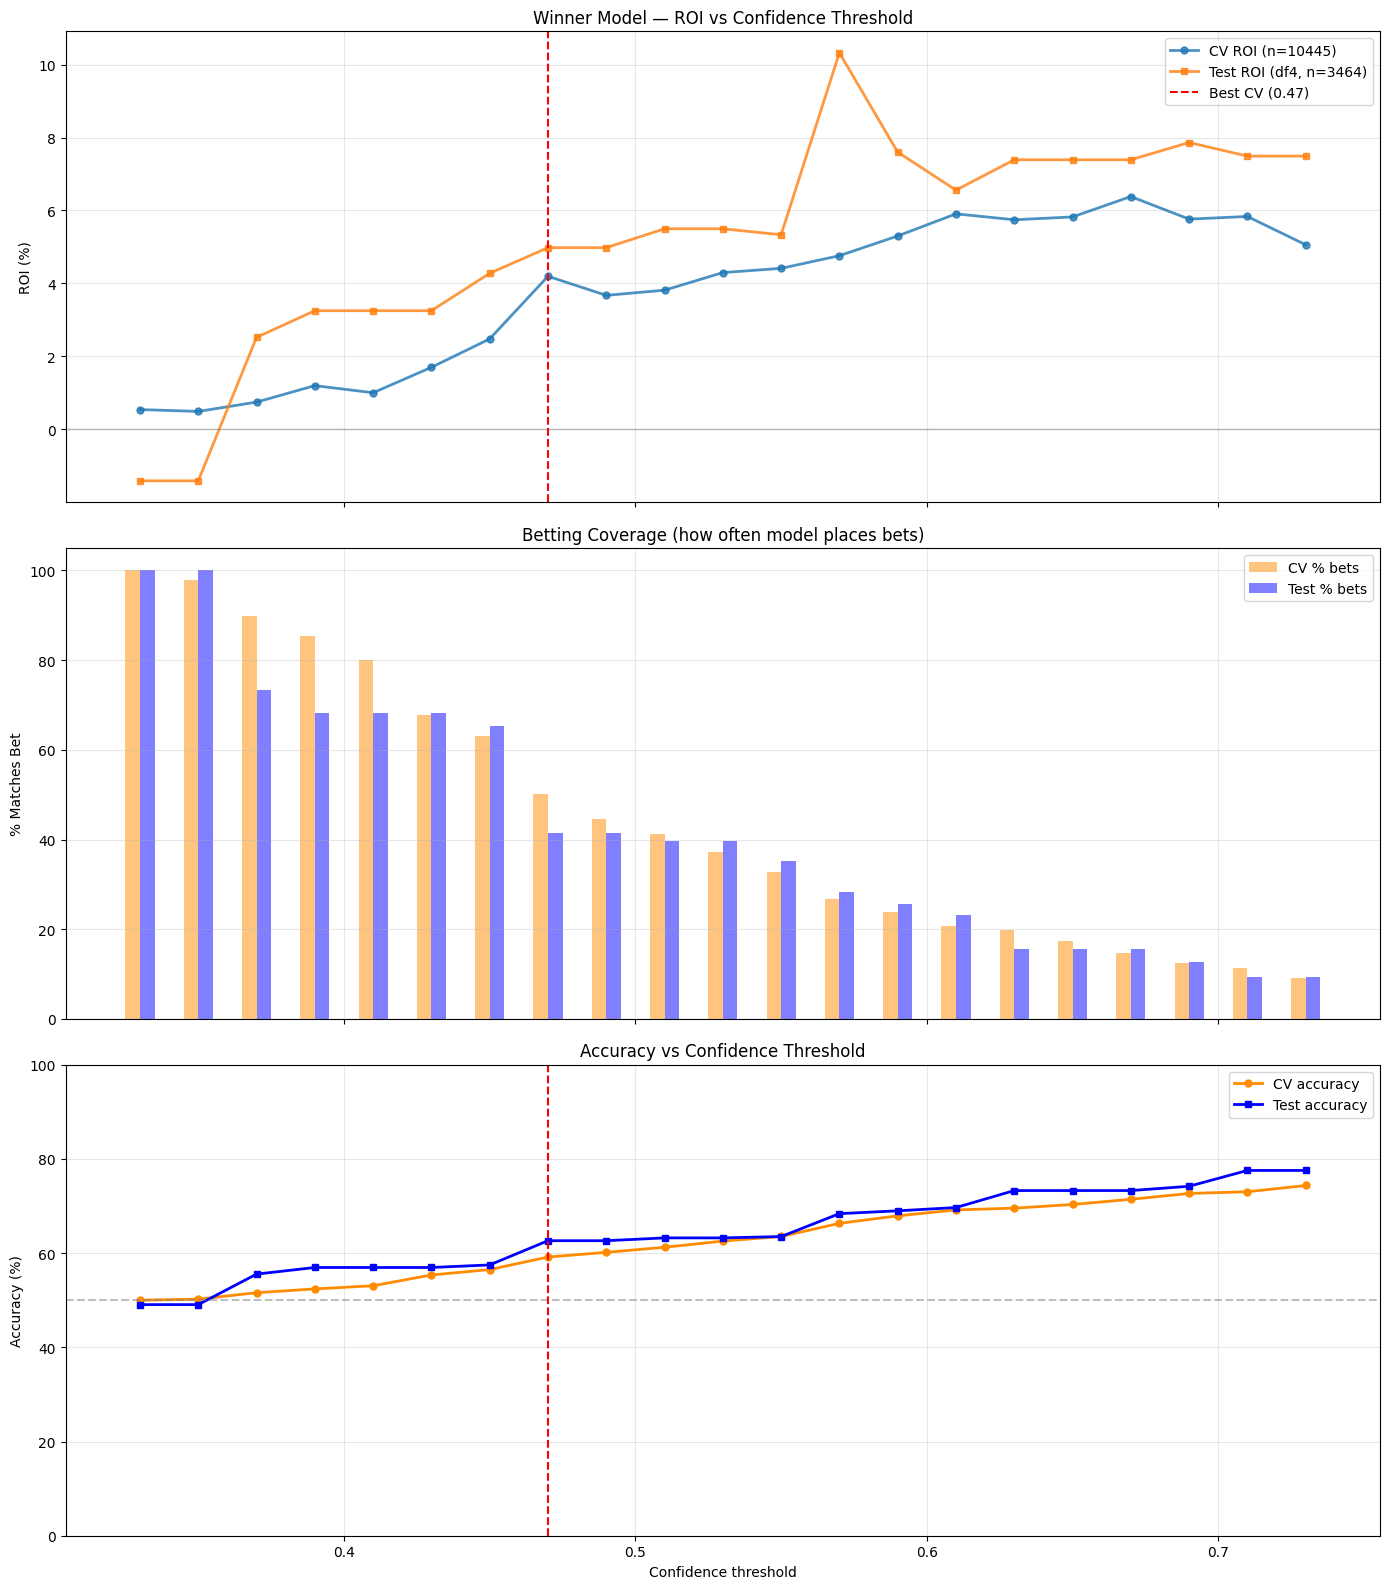

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

# ─────────────────────────────────────────────────────────────
# 1. PROFIT: CV vs TEST
# ─────────────────────────────────────────────────────────────
ax = axes[0]

ax.plot(confidences_cv, roi_cv,marker='o', markersize=5,linewidth=2,label=f'CV ROI (n={len(X_train_full)})',alpha=0.8)
ax.plot(confidences_test, roi_test,marker='s', markersize=5,linewidth=2,label=f'Test ROI (df4, n={len(X_test_full)})',alpha=0.8)

ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',linewidth=1.5, label=f'Best CV ({BEST_CONFIDENCE_CV})')

ax.set_ylabel("ROI (%)")
ax.set_title("Winner Model — ROI vs Confidence Threshold")
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 2. BET COVERAGE
# ─────────────────────────────────────────────────────────────
ax = axes[1]

width = 0.005

ax.bar(np.array(confidences_cv) - width/2,pct_cv,width=width,color='darkorange',alpha=0.5,label='CV % bets')
ax.bar(np.array(confidences_test) + width/2,pct_test,width=width,color='blue',alpha=0.5,label='Test % bets')

ax.set_ylabel("% Matches Bet")
ax.set_title("Betting Coverage (how often model places bets)")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 3. ACCURACY
# ─────────────────────────────────────────────────────────────
ax = axes[2]

ax.plot(confidences_cv, acc_cv,marker='o', markersize=5,color='darkorange', linewidth=2,label='CV accuracy')
ax.plot(confidences_test, acc_test,marker='s', markersize=5,color='blue', linewidth=2,label='Test accuracy')

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',
           linewidth=1.5)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Confidence Threshold")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()


plt.tight_layout()
plt.show()

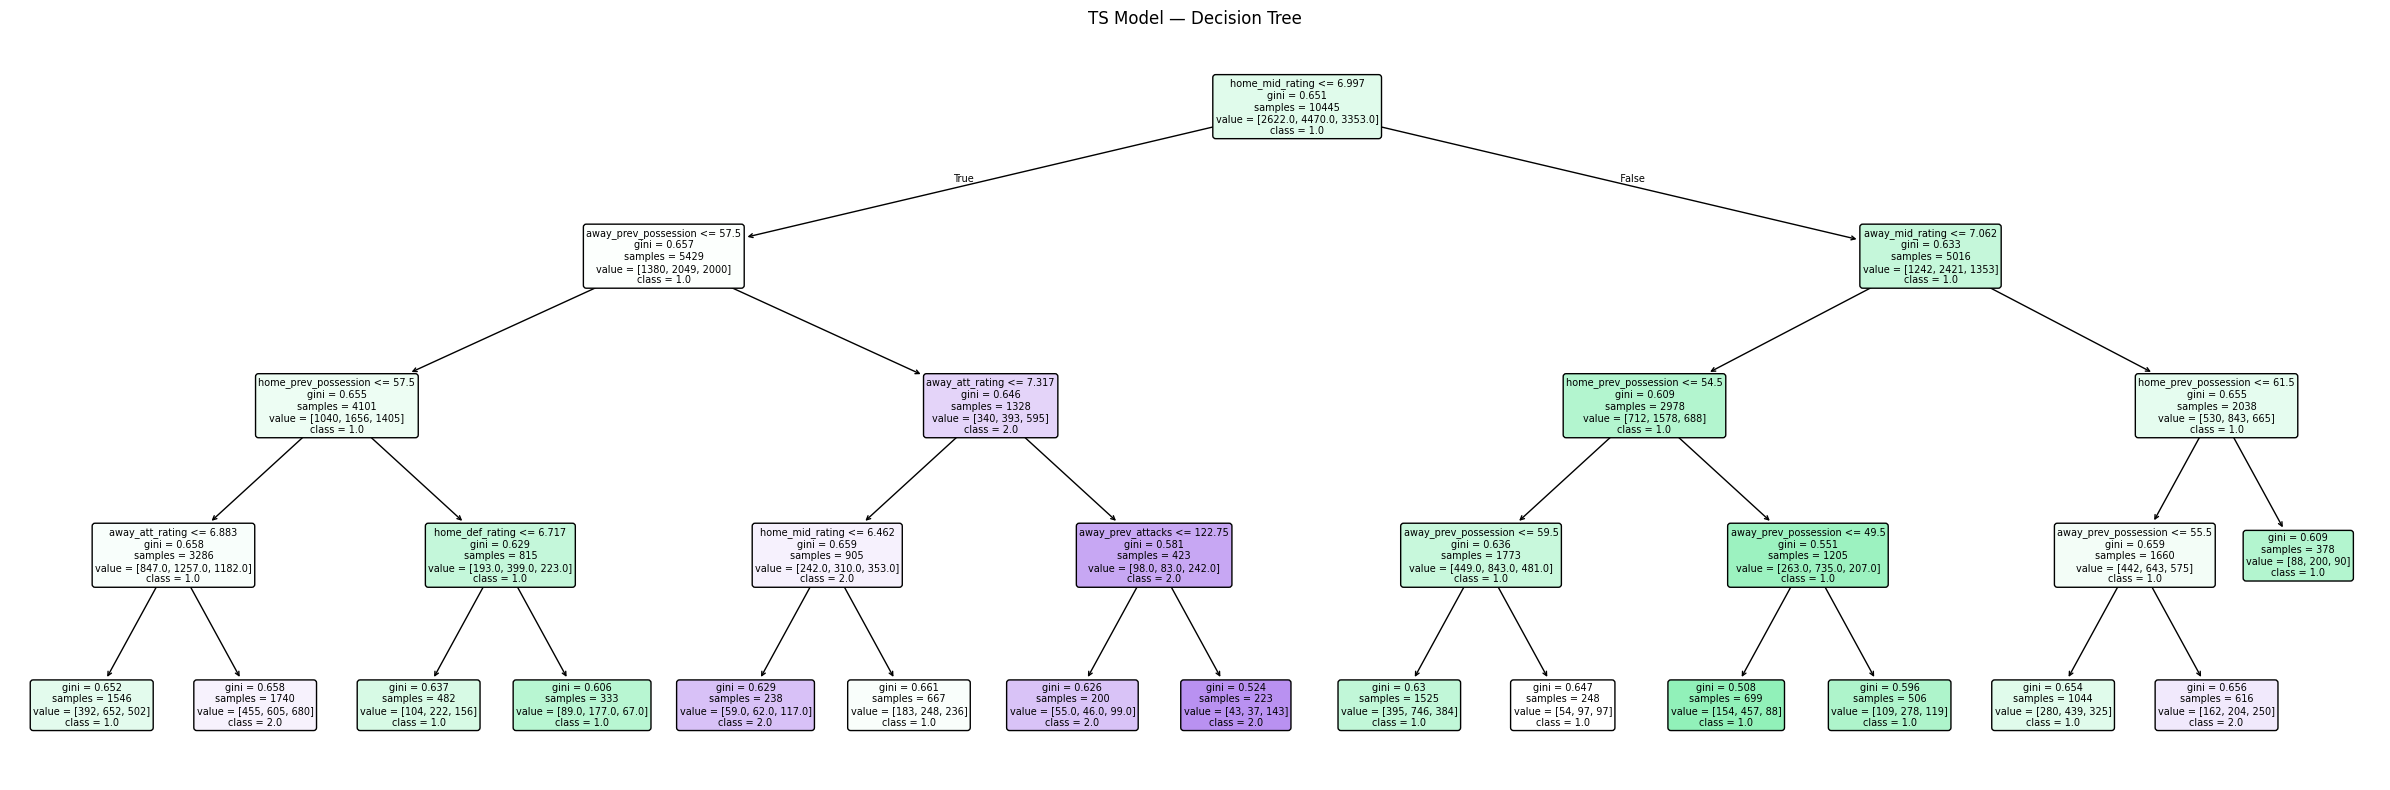

In [ ]:
# ── WIZUALIZACJA DRZEWA ────────────────────────────────────────────────────────

plt.figure(figsize=(24, 8))
plot_tree(model_dt.clf_, feature_names=feature_cols,
          class_names=[str(c) for c in model_dt.classes_],
          filled=True, rounded=True, fontsize=7)
plt.title("TS Model — Decision Tree")
plt.tight_layout()
plt.show()

### Model run for all RF model

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']
META_COLS = ['team_1', 'team_2', 'date', TARGET_W, 'goals_1', 'goals_2', 'league']
NUMERIC_DTYPES = ['float64', 'int64', 'float32', 'int32', 'uint8', 'int8', 'uint16', 'uint32', 'uint64']
EXCLUDE_FROM_FEATURES = ['formation']

# ═══════════════════════════════════════════════════════════════════════════
# LEAGUE ENCODING (ONE-HOT)
# ═══════════════════════════════════════════════════════════════════════════
df_all = pd.concat([df_train_ts, df_test_ts], ignore_index=True)
all_leagues = df_all['league'].unique()


for league in all_leagues:
    col_name = f"league_{league.replace(' ', '_').replace('-', '_')}"
    df_train_ts[col_name] = (df_train_ts['league'] == league).astype(int)
    df_test_ts[col_name] = (df_test_ts['league'] == league).astype(int)

league_feature_cols = [f"league_{l.replace(' ', '_').replace('-', '_')}" for l in all_leagues]

NameError: name 'df_train_ts' is not defined

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FEATURE PREPARATION (ODDS EXCLUDED)
# ═══════════════════════════════════════════════════════════════════════════
feature_cols = [
    c for c in df_train_ts.columns
    if c not in META_COLS
    and c not in BET_COLS
    and df_train_ts[c].dtype in NUMERIC_DTYPES
]

X_train_feats = df_train_ts[feature_cols].fillna(0)
X_test_feats = df_test_ts[feature_cols].fillna(0)

X_train_full = df_train_ts[feature_cols + BET_COLS].fillna(0)
X_test_full = df_test_ts[feature_cols + BET_COLS].fillna(0)

y_train = df_train_ts[TARGET_W]
y_test = df_test_ts[TARGET_W]

print(f"\nX_train_feats shape (odds excluded):  {X_train_feats.shape}")
print(f"X_train_full shape (odds included):     {X_train_full.shape}")
print(f"y_train shape:                          {y_train.shape}")



X_train_feats shape (odds excluded):  (10445, 129)
X_train_full shape (odds included):     (10445, 132)
y_train shape:                          (10445,)


In [ ]:
X_train_full.columns

Index(['home_match_number', 'away_match_number', 'diff_att_rating', 'diff_attack_efficiency', 'diff_attack_pressure', 'diff_attacks', 'diff_avg10_att_rating', 'diff_avg10_attack_efficiency', 'diff_avg10_attack_pressure', 'diff_avg10_attacks',
       ...
       'league_Super_Lig', 'league_LaLiga', 'league_Tipico_Bundesliga', 'league_Eredivisie', 'league_Liga_Portugal', 'league_Super_League', 'league_Serie_A', 'bet_1', 'bet_x', 'bet_2'], dtype='object', length=132)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# EWALUATION FUNCTION
# ═══════════════════════════════════════════════════════════════════════════
def evaluate_winner_predictions(model, X, y, confidence_threshold):
    proba = model.predict_proba(X)
    classes = model.classes_
    confidence = proba.max(axis=1)
    predicted = classes[proba.argmax(axis=1)]
    
    X_reset = X.reset_index(drop=True)
    y_reset = np.array(y)
    
    profits = []
    placed = 0
    won = 0
    
    for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
        if conf < confidence_threshold:
            continue
        
        placed += 1
        
        bet_col = {1.0: 'bet_1', 0.0: 'bet_x', 2.0: 'bet_2'}[pred]
        
        if bet_col not in X_reset.columns:
            continue
        
        odds = X_reset.iloc[i][bet_col]
        
        if pred == true:
            profits.append(odds - 1)
            won += 1
        else:
            profits.append(-1)
    
    total = len(y)
    profit = sum(profits)
    pct = placed / total * 100 if total > 0 else 0
    acc = won / placed * 100 if placed > 0 else 0
    
    return profit, placed, pct, acc, won


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL
# ═══════════════════════════════════════════════════════════════════════════
model_rf = BettingForestClassifier(
    feature_cols=feature_cols,
    n_estimators=20,
    max_depth=4,
    min_samples_leaf=200,
    max_features=1.0,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ═══════════════════════════════════════════════════════════════════════════
# ITERATION - CONFIDENCE THRESHOLDS - CROSS VALIDATION
# ═══════════════════════════════════════════════════════════════════════════
confidence_thresholds = np.round(np.arange(0.33, 0.75, 0.02), 2)
results = []

print("\n" + "="*90)
print("CROSS-VALIDATION (5-fold) - TIME SERIES MODEL - WINNER CLASSIFICATION")
print("="*90)
print(f"{'Confidence':>11} | {'CV profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:

    cv_profit = []
    cv_placed = []
    cv_won = []

    for train_idx, val_idx in cv.split(X_train_full, y_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        m = clone(model_rf)
        m.fit(X_tr, y_tr)

        profit, placed, pct, acc, won = evaluate_winner_predictions(
            m, X_val, y_val, conf_threshold
        )

        cv_profit.append(profit)
        cv_placed.append(placed)
        cv_won.append(won)

    total_matches = len(y_train)
    total_placed = np.sum(cv_placed)
    total_won = np.sum(cv_won)

    acc_total = total_won / total_placed * 100 if total_placed > 0 else 0

    pct_total = total_placed / total_matches * 100

    results.append({
        'confidence': conf_threshold,
        'cv_profit_sum': np.sum(cv_profit),
        'cv_profit_avg': np.mean(cv_profit),
        'placed': total_placed,
        'pct': pct_total,
        'acc': np.mean(acc_total),
    })

    print(f"{conf_threshold:>11.2f} | {np.sum(cv_profit):>12.2f} | "
          f"{total_placed:>8} | {pct_total:>7.1f}% | {np.mean(acc_total):>9.1f}%")

best_cv = max(results, key=lambda x: x['cv_profit_sum'])
BEST_CONFIDENCE_CV = best_cv['confidence']
print(f"\nBest confidence threshold (CV): {BEST_CONFIDENCE_CV}  (profit: {best_cv['cv_profit_sum']:.2f})")

model_rf.fit(X_train_full, y_train)


CROSS-VALIDATION (5-fold) - TIME SERIES MODEL - WINNER CLASSIFICATION
 Confidence |    CV profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |      -149.43 |    10445 |   100.0% |      50.8%
       0.35 |      -152.92 |    10438 |    99.9% |      50.8%
       0.37 |      -111.36 |     9900 |    94.8% |      51.7%
       0.39 |        -5.89 |     8855 |    84.8% |      53.5%
       0.41 |        68.33 |     7917 |    75.8% |      55.2%
       0.43 |       173.44 |     7025 |    67.3% |      57.3%
       0.45 |       125.62 |     6140 |    58.8% |      58.9%
       0.47 |       140.87 |     5361 |    51.3% |      60.8%
       0.49 |       157.38 |     4669 |    44.7% |      62.8%
       0.51 |       184.36 |     4082 |    39.1% |      64.9%
       0.53 |       156.38 |     3592 |    34.4% |      66.2%
       0.55 |       154.43 |     3129 |    30.0% |      68.0%
       0.57 |       150.31 |    

BettingForestClassifier(feature_cols=['home_match_number', 'away_match_number',
                                      'diff_att_rating',
                                      'diff_attack_efficiency',
                                      'diff_attack_pressure', 'diff_attacks',
                                      'diff_avg10_att_rating',
                                      'diff_avg10_attack_efficiency',
                                      'diff_avg10_attack_pressure',
                                      'diff_avg10_attacks',
                                      'diff_avg10_conversion_rate',
                                      'diff_avg10_danger_ratio',
                                      'diff_avg10_dangerous_attacks',...
                                      'diff_avg10_gk_rating',
                                      'diff_avg10_goal_chances',
                                      'diff_avg10_goalkeeper_saves',
                                      'diff_avg10_goals',
                                      'diff_avg10_goals_lost',
                                      'diff_avg10_match_points',
                                      'diff_avg10_mid_rating',
                                      'diff_avg10_offsides',
                                      'diff_avg10_possession',
                                      'diff_avg10_possession_efficiency',
                                      'diff_avg10_red_cards',
                                      'diff_avg10_shot_quality',
                                      'diff_avg10_shots', ...],
                        min_samples_leaf=200, n_estimators=20)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# EWALUATION
# ═══════════════════════════════════════════════════════════════════════════
test_results = []

print("\n" + "="*90)
print(f"TEST DATA - {len(X_test_full)} matches - TIME SERIES MODEL")
print("="*90)
print(f"{'Confidence':>11} | {'Profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:
    profit, placed, pct, acc, won = evaluate_winner_predictions(model_rf, X_test_full, y_test, conf_threshold)
    
    test_results.append({
        'confidence': conf_threshold,
        'profit': profit,
        'placed': placed,
        'won': won,
        'pct': pct,
        'acc': acc,
    })

    print(f"{conf_threshold:>11.2f} | {profit:>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

best_test = max(test_results, key=lambda x: x['profit'])
BEST_CONFIDENCE_TEST = best_test['confidence']
print(f"\nBest confidence threshold (TEST): {BEST_CONFIDENCE_TEST}  (profit: {best_test['profit']:.2f})")
print(f"  Confidence threshold selected from CV: {BEST_CONFIDENCE_CV}")


TEST DATA - 3464 matches - TIME SERIES MODEL
 Confidence |       Profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |       -15.79 |     3464 |   100.0% |      51.7%
       0.35 |       -15.92 |     3462 |    99.9% |      51.7%
       0.37 |        -5.11 |     3286 |    94.9% |      52.5%
       0.39 |        57.31 |     2959 |    85.4% |      54.7%
       0.41 |        72.29 |     2563 |    74.0% |      56.9%
       0.43 |        66.43 |     2157 |    62.3% |      59.2%
       0.45 |        58.51 |     1691 |    48.8% |      61.9%
       0.47 |        41.19 |     1395 |    40.3% |      63.4%
       0.49 |        63.75 |     1212 |    35.0% |      66.3%
       0.51 |        57.07 |     1043 |    30.1% |      67.8%
       0.53 |        24.35 |      878 |    25.3% |      68.6%
       0.55 |        31.54 |      719 |    20.8% |      71.1%
       0.57 |        30.20 |      597 |    17.2% |      7

In [ ]:
confidences_cv = [r['confidence'] for r in results]
profits_cv     = [r['cv_profit_sum'] for r in results]
pct_cv         = [r['pct'] for r in results]
acc_cv         = [r['acc'] for r in results]

confidences_test = [r['confidence'] for r in test_results]
profits_test = [r['profit'] for r in test_results]
pct_test = [r['pct'] for r in test_results]
acc_test = [r['acc'] for r in test_results]

roi_cv = [
    (r['cv_profit_sum'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in results
]

roi_test = [
    (r['profit'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in test_results
]

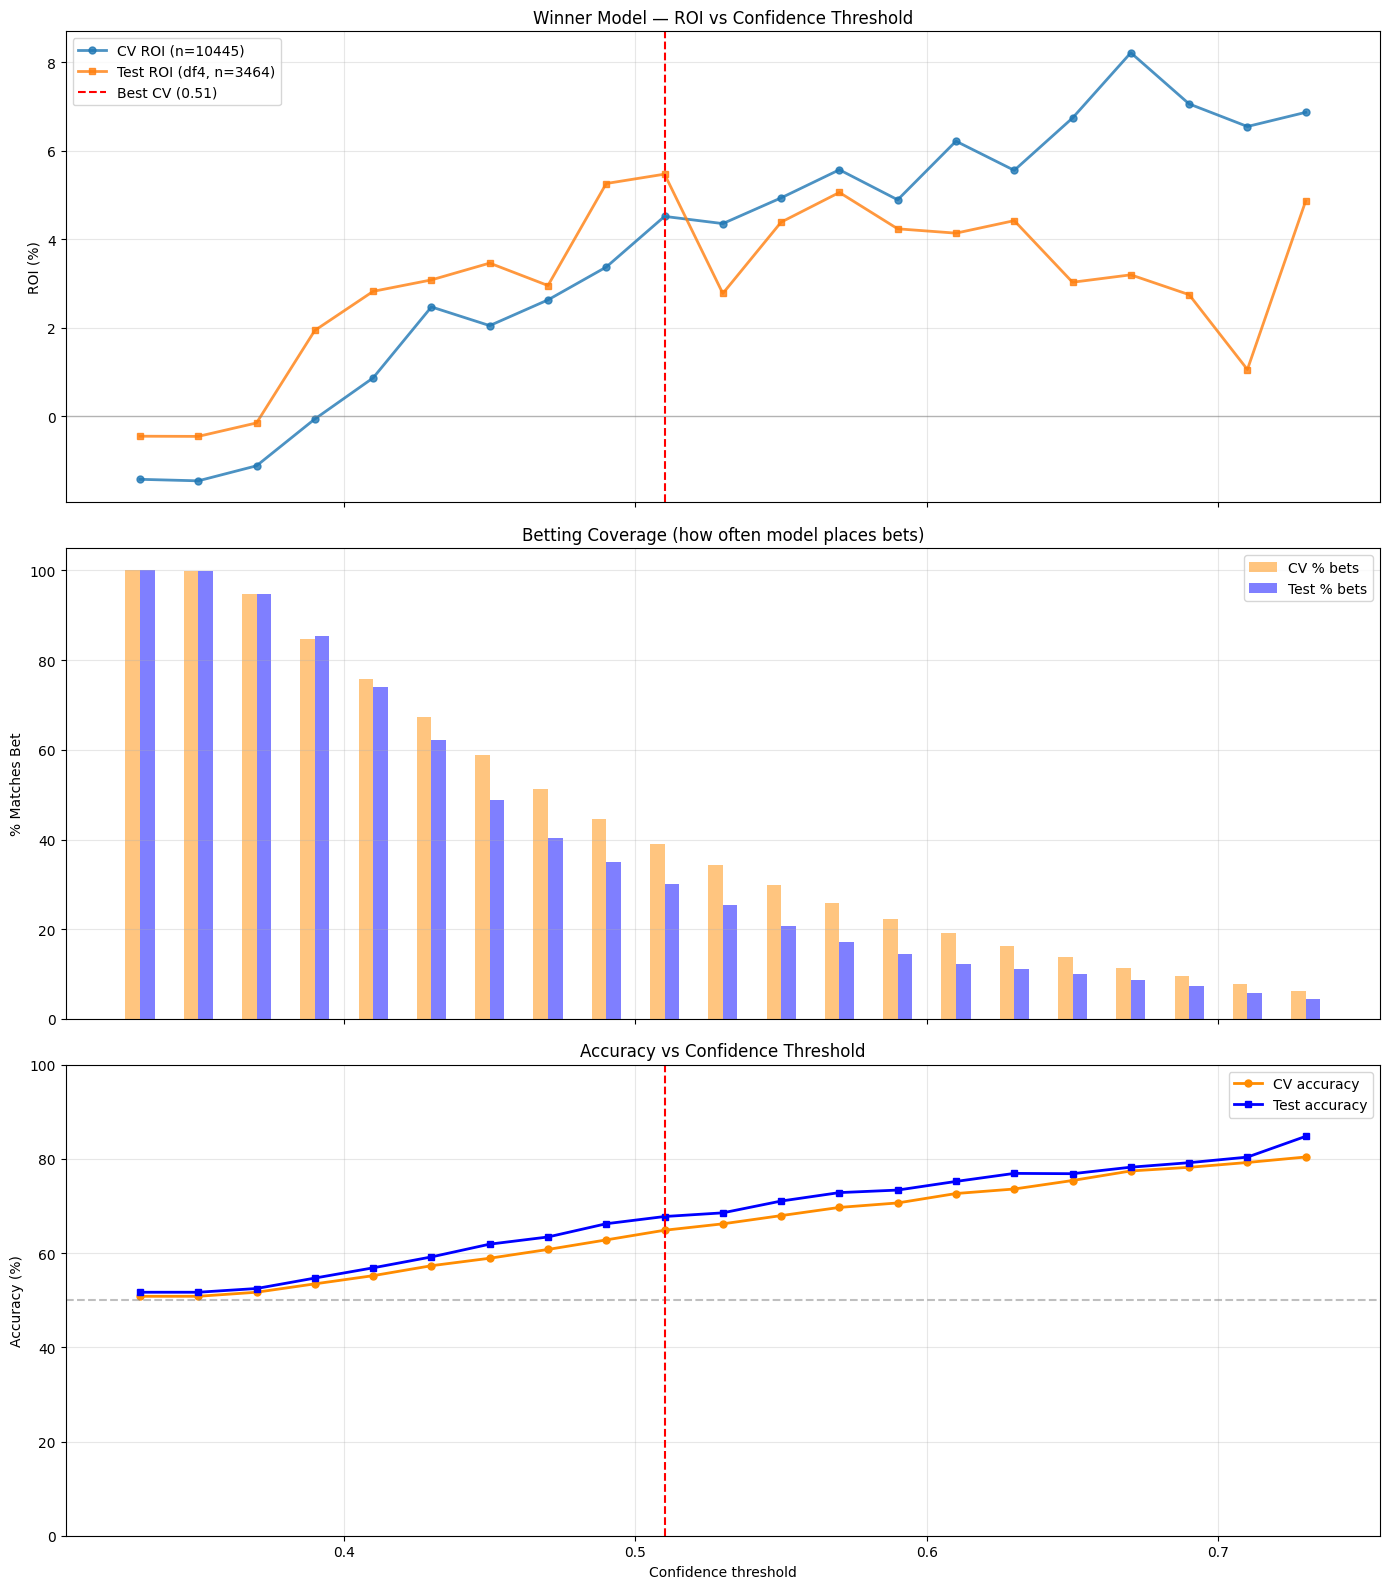

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

# ─────────────────────────────────────────────────────────────
# 1. PROFIT: CV vs TEST
# ─────────────────────────────────────────────────────────────
ax = axes[0]

ax.plot(confidences_cv, roi_cv,marker='o', markersize=5,linewidth=2,label=f'CV ROI (n={len(X_train_full)})',alpha=0.8)
ax.plot(confidences_test, roi_test,marker='s', markersize=5,linewidth=2,label=f'Test ROI (df4, n={len(X_test_full)})',alpha=0.8)

ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',linewidth=1.5, label=f'Best CV ({BEST_CONFIDENCE_CV})')

ax.set_ylabel("ROI (%)")
ax.set_title("Winner Model — ROI vs Confidence Threshold")
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 2. BET COVERAGE
# ─────────────────────────────────────────────────────────────
ax = axes[1]

width = 0.005

ax.bar(np.array(confidences_cv) - width/2,pct_cv,width=width,color='darkorange',alpha=0.5,label='CV % bets')
ax.bar(np.array(confidences_test) + width/2,pct_test,width=width,color='blue',alpha=0.5,label='Test % bets')

ax.set_ylabel("% Matches Bet")
ax.set_title("Betting Coverage (how often model places bets)")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 3. ACCURACY
# ─────────────────────────────────────────────────────────────
ax = axes[2]

ax.plot(confidences_cv, acc_cv,marker='o', markersize=5,color='darkorange', linewidth=2,label='CV accuracy')
ax.plot(confidences_test, acc_test,marker='s', markersize=5,color='blue', linewidth=2,label='Test accuracy')

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',
           linewidth=1.5)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Confidence Threshold")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()


plt.tight_layout()
plt.show()

### Save models

Save the progress

In [104]:
import joblib
import os

MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. SAVE BettingTreeClassifier
dt_filename = os.path.join(MODELS_DIR, "dt_model.joblib")
dt_data = {
    'model': model_dt,
    'feature_cols': feature_cols,
    'best_confidence': BEST_CONFIDENCE_CV,
    'type': 'DecisionTree'
}
joblib.dump(dt_data, dt_filename)
print(f"DT model saved: {dt_filename}")


# 2. SAVE BettingForestClassifier
rf_filename = os.path.join(MODELS_DIR, "rf_model.joblib")
rf_data = {
    'model': model_rf,
    'feature_cols': feature_cols,
    'best_confidence': BEST_CONFIDENCE_CV,
    'type': 'RandomForest'
}
joblib.dump(rf_data, rf_filename)
print(f"RF model saved: {rf_filename}")

DT model saved: ../models\dt_model.joblib
RF model saved: ../models\rf_model.joblib


In [ ]:
import joblib

# load model
loaded_data = joblib.load("../models/rf_model.joblib")
model = loaded_data['model']
threshold = loaded_data['best_confidence']
cols = loaded_data['feature_cols']

# 6 Final Betting Strategy and Profitability Analysis

This final step builds upon the previously developed models and focuses on creating betting strategies and evaluating their profitability, now incorporating taxation. Accuracy alone is insufficient; to assess profitability, we must also consider betting odds, match dates, coupon compositions, and models that are trained and tested based on entire seasons rather than random splits—thus simulating real-world scenarios

Run `5. Models - Preparation` in order to load custom classes (BettingTreeClasifier and BettingForestClassifier)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')
import joblib
import os

In [12]:
# CONFIGURATION
SAVE_DIR       = r"..\data\datasets"
BANKROLL_INIT  = 1000.0       # Start bankroll [PLN or any units]
TAX_RATE       = 0.12         # 12% tax (poland)
N_SIMULATIONS  = 100          # Number of Monte Carlo per strategy
RANDOM_SEED    = 42

# Confidence threshold
CONF_LOW   = 0.47
CONF_HIGH  = 0.95

# Kelly fractions for testing
KELLY_FRACTIONS = [0.1, 0.15, 0.20]

# Number of matches on the betting slip
COUPON_SIZES = [1, 2, 3]

In [13]:
df_train = pd.read_parquet(os.path.join(SAVE_DIR, "train_diff.parquet"))
df_test  = pd.read_parquet(os.path.join(SAVE_DIR, "test_diff.parquet"))

# Ensure data is sorted by the date
df_test['date'] = pd.to_datetime(df_test['date'])
df_test = df_test.sort_values('date').reset_index(drop=True)

df_train['date'] = pd.to_datetime(df_train['date'])
df_train = df_train.sort_values('date').reset_index(drop=True)

META_COLS = ['winner', 'goals_1', 'goals_2', 'bet_1', 'bet_x', 'bet_2',
             'team_1', 'team_2', 'date', 'league',
             'home_match_number', 'away_match_number']

feature_cols = [c for c in df_train.columns if c not in META_COLS]

X_train = df_train[feature_cols]
y_train = df_train['winner']
X_test  = df_test[feature_cols]
y_test  = df_test['winner']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Feature cols: {len(feature_cols)}")


Train: (10445, 115) | Test: (3464, 115)
Feature cols: 115


Here we pick up which model we want to run

In [25]:
# MODEL
loaded_data     = joblib.load("../models/dt_model.joblib")
model           = loaded_data['model']
BEST_CONFIDENCE = loaded_data['best_confidence']
feature_cols    = loaded_data['feature_cols']

# data
X_train = df_train.reindex(columns=feature_cols, fill_value=0)
y_train = df_train['winner']
X_test  = df_test.reindex(columns=feature_cols, fill_value=0)
y_test  = df_test['winner']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Feature cols: {len(feature_cols)}")
print(f"Best model confidence: {BEST_CONFIDENCE}")

# Propabilities on test dataset
proba   = model.predict_proba(X_test)
classes = list(model.classes_)
idx_map = {cls: i for i, cls in enumerate(classes)}

Train: (10445, 129) | Test: (3464, 129)
Feature cols: 129
Best model confidence: 0.51


In [26]:
# SUPPORT FUNCTIONS

def get_odds(row: pd.Series, outcome: int) -> float:
    """Return odd for given result (1/X/2)."""
    return {1: row['bet_1'], 0: row['bet_x'], 2: row['bet_2']}[outcome]

def kelly_stake(prob: float, odds: float, fraction: float = 0.5) -> float:
    """
    Kelly criterion: f = (p*odds - 1) / (odds - 1)
    Returns bankroll fraction to substitute (after trimmed to 0).
    """
    if odds <= 1.0:
        return 0.0
    edge = prob * odds - 1.0
    if edge <= 0:
        return 0.0
    kelly_full = edge / (odds - 1.0)
    return fraction * kelly_full

def net_payout(stake: float, odds: float, won: bool) -> float:
    """
    Returns the bankroll change after a match, taking into account a 12% tax on winnings.
    
    Loss: -stake
    Win:  +stake * (odds - 1) * (1 - TAX_RATE)
    """
    if not won:
        return -stake
    gross_win = stake * (odds - 1.0)
    return gross_win * (1.0 - TAX_RATE)

def net_payout_coupon(stake: float, combined_odds: float, won: bool) -> float:
    """Equivalent calculation for a betting slip (a single bet placed on the selected combination)."""
    if not won:
        return -stake
    gross_win = stake * (combined_odds - 1.0)
    return gross_win * (1.0 - TAX_RATE)

# it select candidates for monte carlo. If event passes the condition then it can be randomly picked up in simulation
# if event does not fullfil condition then its removed from bets pool so cannot be selected in simulation
def build_candidate_bets(df: pd.DataFrame, proba: np.ndarray, # choosen build_candidate_bets_propability implementation
                          conf_low: float, conf_high: float) -> pd.DataFrame:
    return build_candidate_bets_prob_value(df, proba, conf_low, conf_high)

def build_candidate_bets_propability(df, proba, conf_low, conf_high):
    '''Highest propability'''
    records = []

    for i, row in df.iterrows():
        best_outcome = None
        best_prob = 0.0

        for outcome in [1, 0, 2]:
            col = idx_map[outcome]
            p = proba[i, col]

            if conf_low <= p <= conf_high and p > best_prob:
                best_prob = p
                best_outcome = outcome

        if best_outcome is not None:
            records.append({
                'match_idx': i,
                'date': row['date'],
                'outcome': best_outcome,
                'prob': best_prob,
                'odds': get_odds(row, best_outcome),
                'true_result': row['winner'],
                'won': int(row['winner']) == best_outcome,
            })

    return pd.DataFrame(records)

def build_candidate_bets_prob_value(df, proba, conf_low, conf_high):
    '''Highest propability but with condition P*odds>1.2'''
    records = []

    for i, row in df.iterrows():
        best_outcome = None
        best_prob = 0.0

        for outcome in [1, 0, 2]:
            col = idx_map[outcome]
            p = proba[i, col]
            odds = get_odds(row, outcome)

            if (
                conf_low <= p # <= conf_high
                and p * odds > 1.2
                and p > best_prob
            ):
                best_prob = p
                best_outcome = outcome

        if best_outcome is not None:
            records.append({
                'match_idx': i,
                'date': row['date'],
                'outcome': best_outcome,
                'prob': best_prob,
                'odds': get_odds(row, best_outcome),
                'true_result': row['winner'],
                'won': int(row['winner']) == best_outcome,
            })

    return pd.DataFrame(records)

def build_candidate_bets_value(df, proba, conf_low, conf_high):
    '''Highest expected Value but with condition: P*odds > 1'''
    records = []

    for i, row in df.iterrows():
        best_outcome = None
        best_value = 0.0
        best_prob = None

        for outcome in [1, 0, 2]:
            col = idx_map[outcome]
            p = proba[i, col]
            odds = get_odds(row, outcome)

            value = p * odds

            if (
                conf_low <= p <= conf_high
                and value > 1
                and value > best_value
            ):
                best_value = value
                best_outcome = outcome
                best_prob = p

        if best_outcome is not None:
            records.append({
                'match_idx': i,
                'date': row['date'],
                'outcome': best_outcome,
                'prob': best_prob,
                'odds': get_odds(row, best_outcome),
                'value': best_value,
                'true_result': row['winner'],
                'won': int(row['winner']) == best_outcome,
            })

    return pd.DataFrame(records)


In [27]:
def simulate_strategy(
    candidates: pd.DataFrame,
    coupon_size: int,
    kelly_fraction: float,
    n_sim: int,
    bankroll_init: float,
    rng: np.random.Generator
) -> dict:
    """
    Monte Carlo: for each simulation, randomly groups candidates into betting slips
    (coupon_size matches per slip), calculates Kelly stakes based on combined odds,
    and tracks the bankroll chronologically.

    Returns dictionary:
        'final_bankrolls': list of final bankrolls
        'yields':          list of YIELD [%] per simulation
    """
    final_bankrolls = []
    yields = []

    candidates = candidates.sort_values('date').reset_index(drop=True)
    candidates['week'] = candidates['date'].dt.to_period('W') # group by 1 week
    weeks = candidates['week'].unique()

    for sim in range(n_sim):
        bankroll      = bankroll_init
        total_staked  = 0.0
        total_net     = 0.0

        for week in weeks:
            week_bets = candidates[candidates['week'] == week].copy()
            if len(week_bets) < coupon_size:
                continue # too few candidates

            # Random betting slips - but without match repetition thus in real life can be repeated
            indices = week_bets.index.tolist()
            rng.shuffle(indices)

            for start in range(0, len(indices) - coupon_size + 1, coupon_size):
                group_idx = indices[start: start + coupon_size]
                group     = week_bets.loc[group_idx]

                if bankroll <= 0:
                    break

                # Coupon probability = product of individual probabilities (assuming independence)
                combined_odds = group['odds'].prod()
                combined_prob = group['prob'].prod()

                stake_frac = kelly_stake(combined_prob, combined_odds, kelly_fraction)
                stake_frac = min(stake_frac, 0.25) # cap: max 25% bankroll for betting slip
                stake      = bankroll * stake_frac

                if stake < 0.01:
                    continue

                all_won = group['won'].all()
                delta   = net_payout_coupon(stake, combined_odds, all_won)

                total_staked += stake
                total_net    += delta

                bankroll = max(0.0, bankroll + delta)

        final_bankrolls.append(bankroll)

        # YIELD = netto / stake × 100; if no bet → 0
        yield_pct = (total_net / total_staked * 100) if total_staked > 0 else 0.0
        yields.append(yield_pct)

    return {
        'final_bankrolls': final_bankrolls,
        'yields': yields,
    }
    

In [28]:
# EXPERIMENT

rng = np.random.default_rng(RANDOM_SEED)

candidates = build_candidate_bets(df_test, proba, CONF_LOW, CONF_HIGH)
print(f"\nBetting candidates: {len(candidates)} matches "
      f"({len(candidates)/len(df_test)*100:.1f}% of the test set)")
print(f"Candidate accuracy: {candidates['won'].mean()*100:.1f}%")

sim_results = {}

total_strategies = len(COUPON_SIZES) * len(KELLY_FRACTIONS)
done = 0

print(f"\nRunning {total_strategies} strategies × {N_SIMULATIONS} simulations...\n")

sim_results = {}   # (cs, kf) → {'final_bankrolls': [...], 'yields': [...]}

for cs in COUPON_SIZES:
    for kf in KELLY_FRACTIONS:
        key = (cs, kf)
        result = simulate_strategy(
            candidates     = candidates,
            coupon_size    = cs,
            kelly_fraction = kf,
            n_sim          = N_SIMULATIONS,
            bankroll_init  = BANKROLL_INIT,
            rng            = rng
        )
        sim_results[key] = result
        done += 1
        finals     = result['final_bankrolls']
        yields     = result['yields']
        median_roi = (np.median(finals) / BANKROLL_INIT - 1) * 100
        print(f"  [{done}/{total_strategies}] kupon={cs} Kelly×{kf:.2f} | "
              f"median bankroll: {np.median(finals):.1f} "
              f"(ROI: {median_roi:+.1f}%) | "
              f"median YIELD: {np.median(yields):+.2f}%")



Betting candidates: 461 matches (13.3% of the test set)
Candidate accuracy: 49.2%

Running 9 strategies × 100 simulations...

  [1/9] kupon=1 Kelly×0.10 | median bankroll: 2001.7 (ROI: +100.2%) | median YIELD: +7.00%
  [2/9] kupon=1 Kelly×0.15 | median bankroll: 2138.1 (ROI: +113.8%) | median YIELD: +6.19%
  [3/9] kupon=1 Kelly×0.20 | median bankroll: 1901.0 (ROI: +90.1%) | median YIELD: +4.67%
  [4/9] kupon=2 Kelly×0.10 | median bankroll: 2286.9 (ROI: +128.7%) | median YIELD: +18.86%
  [5/9] kupon=2 Kelly×0.15 | median bankroll: 2450.3 (ROI: +145.0%) | median YIELD: +16.28%
  [6/9] kupon=2 Kelly×0.20 | median bankroll: 3225.8 (ROI: +222.6%) | median YIELD: +15.33%
  [7/9] kupon=3 Kelly×0.10 | median bankroll: 1785.8 (ROI: +78.6%) | median YIELD: +27.66%
  [8/9] kupon=3 Kelly×0.15 | median bankroll: 2306.3 (ROI: +130.6%) | median YIELD: +25.88%
  [9/9] kupon=3 Kelly×0.20 | median bankroll: 2606.2 (ROI: +160.6%) | median YIELD: +26.04%


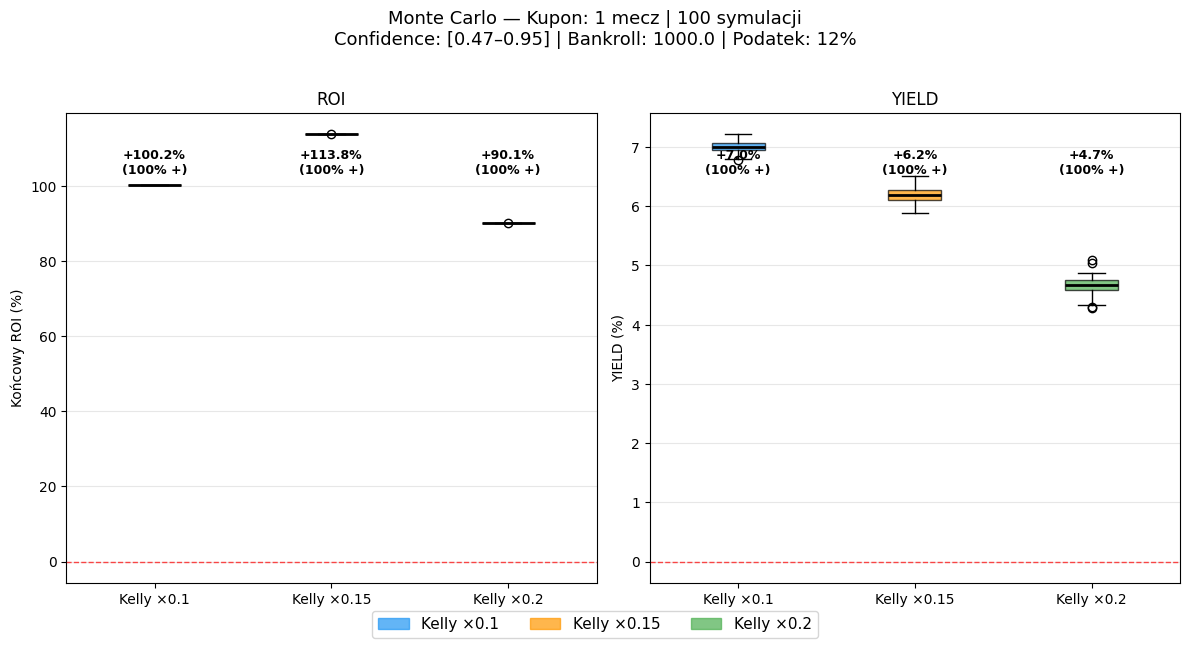

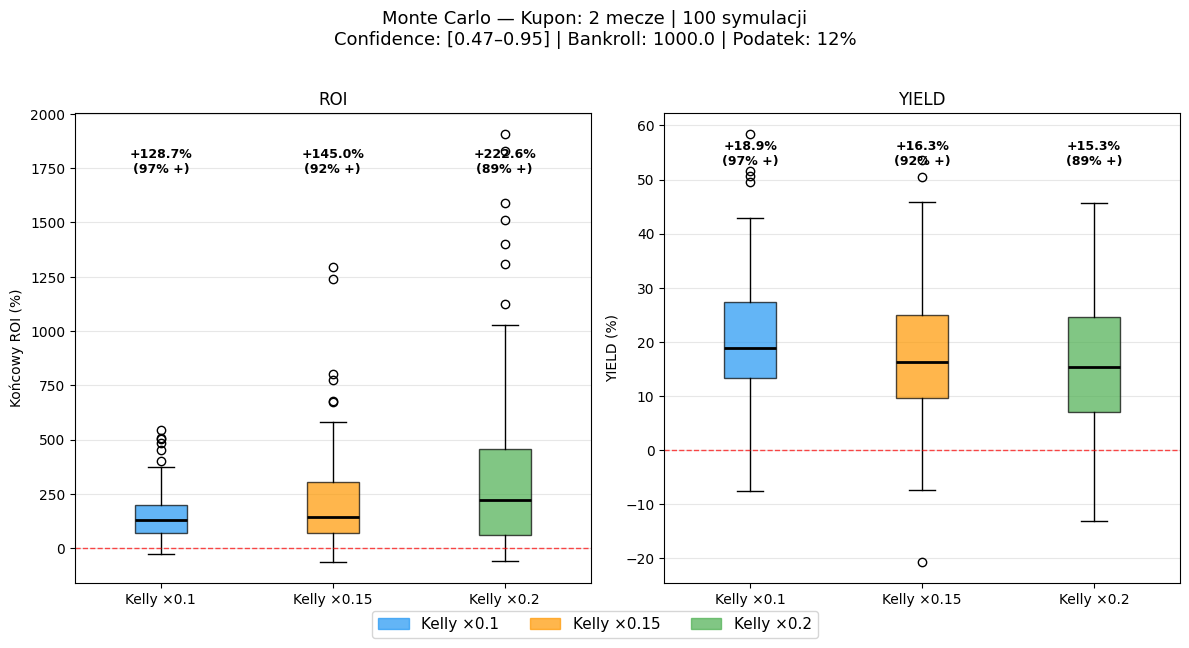

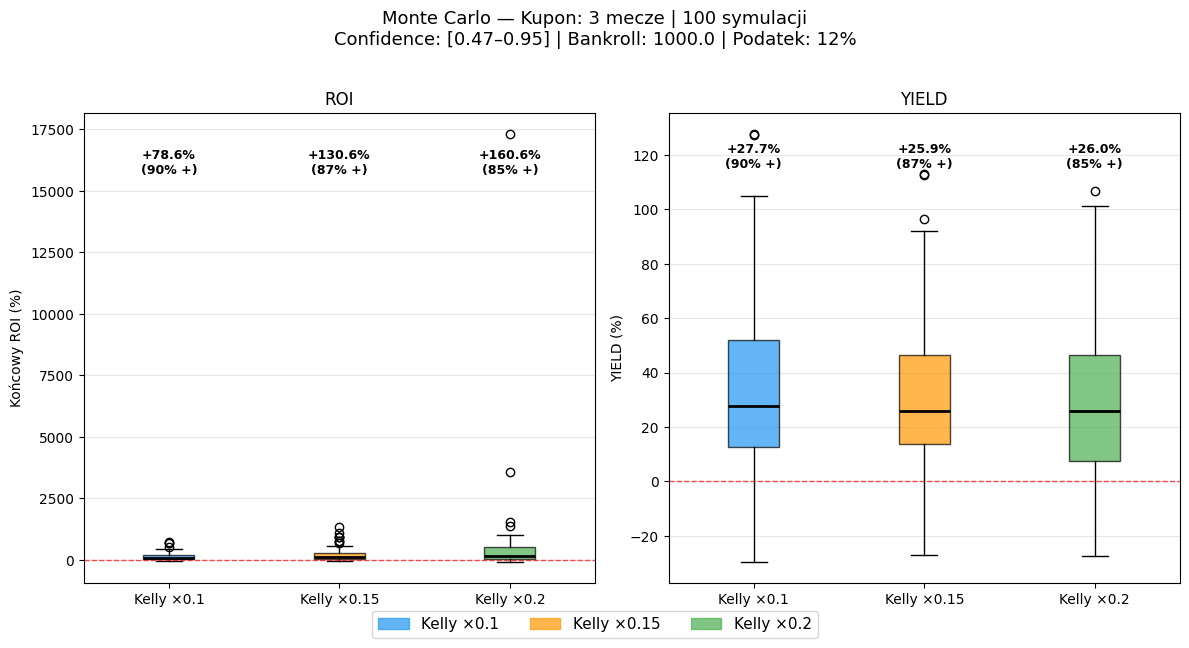

In [29]:
for cs in COUPON_SIZES:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)
    colors = ['#2196F3', '#FF9800', '#4CAF50']

    roi_data   = []
    yield_data = []
    labels     = []

    for kf_idx, kf in enumerate(KELLY_FRACTIONS):
        result = sim_results[(cs, kf)]
        finals = result['final_bankrolls']
        yields = result['yields']

        roi_data.append([(f / BANKROLL_INIT - 1) * 100 for f in finals])
        yield_data.append(yields)
        labels.append(f"Kelly ×{kf}")

    for ax, data, ylabel, title_suffix in [
        (axes[0], roi_data,   'Końcowy ROI (%)', 'ROI'),
        (axes[1], yield_data, 'YIELD (%)',        'YIELD'),
    ]:
        bp = ax.boxplot(data, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_xticks(range(1, len(KELLY_FRACTIONS) + 1))
        ax.set_xticklabels(labels)
        ax.set_ylabel(ylabel)
        ax.set_title(title_suffix, fontsize=12)
        ax.grid(True, alpha=0.3, axis='y')

        for i, vals in enumerate(data, 1):
            med     = np.median(vals)
            pct_pos = np.mean([v > 0 for v in vals]) * 100
            ax.text(i, ax.get_ylim()[1] * 0.92,
                    f'{med:+.1f}%\n({pct_pos:.0f}% +)',
                    ha='center', va='top', fontsize=9, fontweight='bold')

    patches = [mpatches.Patch(color=c, alpha=0.7, label=f'Kelly ×{kf}')
               for c, kf in zip(colors, KELLY_FRACTIONS)]
    fig.legend(handles=patches, loc='lower center', ncol=3,
               fontsize=11, bbox_to_anchor=(0.5, -0.04))

    title_cs = f'Kupon: {cs} {"mecz" if cs == 1 else "mecze" if cs < 5 else "meczów"}'
    fig.suptitle(
        f'Monte Carlo — {title_cs} | {N_SIMULATIONS} symulacji\n'
        f'Confidence: [{CONF_LOW}–{CONF_HIGH}] | Bankroll: {BANKROLL_INIT} | Podatek: {TAX_RATE*100:.0f}%',
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.show()

In [30]:
rows = []
for cs in COUPON_SIZES:
    for kf in KELLY_FRACTIONS:
        result = sim_results[(cs, kf)]
        finals = result['final_bankrolls']
        yields = result['yields']
        rows.append({
            'Kupon':           cs,
            'Kelly':           kf,
            'Med. bankroll':   round(np.median(finals), 1),
            'Med. ROI (%)':    round((np.median(finals) / BANKROLL_INIT - 1) * 100, 2),
            'Med. YIELD (%)':  round(np.median(yields), 2),
            'YIELD p10 (%)':   round(np.percentile(yields, 10), 2),
            'YIELD p90 (%)':   round(np.percentile(yields, 90), 2),
            '% sim > 0':       round(np.mean([f > BANKROLL_INIT for f in finals]) * 100, 1),
            '% ruina (≤0)':    round(np.mean([f <= 0 for f in finals]) * 100, 1),
            '% strata ≥50%':   round(np.mean([f <= BANKROLL_INIT * 0.50 for f in finals]) * 100, 1),
            '% strata ≥80%':   round(np.mean([f <= BANKROLL_INIT * 0.20 for f in finals]) * 100, 1),
        })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

 Kupon  Kelly  Med. bankroll  Med. ROI (%)  Med. YIELD (%)  YIELD p10 (%)  YIELD p90 (%)  % sim > 0  % ruina (≤0)  % strata ≥50%  % strata ≥80%
     1   0.10         2001.7        100.17            7.00           6.91           7.11      100.0           0.0            0.0            0.0
     1   0.15         2138.1        113.81            6.19           6.03           6.33      100.0           0.0            0.0            0.0
     1   0.20         1901.0         90.10            4.67           4.44           4.81      100.0           0.0            0.0            0.0
     2   0.10         2286.9        128.69           18.86           5.20          35.25       97.0           0.0            0.0            0.0
     2   0.15         2450.3        145.03           16.28           3.60          30.88       92.0           0.0            1.0            0.0
     2   0.20         3225.8        222.58           15.33          -0.50          31.28       89.0           0.0            2.0        

Current Results

The current simulation produced the following results:

* Bets are placed only when the expected value (EV) exceeds **1.2** (`probability × odds > 1.2`).
* Bets were placed on **461 out of 3,564 matches** (~13% of all matches).
* The best median bankroll was achieved with a **Kelly fraction of 0.2** and **2 bets per betting ticket**:

  * **Median ROI:** **222.58%**
  * **89%** of simulations finished with a profit.

It is difficult to identify a single **best** strategy because the optimal choice depends on the trade-off between expected return and risk. For example, using **one bet per betting ticket** resulted in profit in nearly every simulation, but the median ROI was only around **90–110%**. On the other hand, more aggressive strategies achieved substantially higher returns at the cost of increased variance and a higher probability of large drawdowns.

Limitations

Limited historical data

The biggest limitation is the available timeline. The analysis covers only **four seasons**, which are already somewhat historical. Although the results are encouraging, it would be preferable to collect data for at least **2–3 additional seasons**.

A more robust evaluation would use a **rolling time-window validation** (e.g., **3 seasons for training + 1 season for testing**). With six seasons, this would produce three independent train/test splits, allowing us to verify whether the model remains stable over time. If the performance proves consistent, it would also justify experimenting with more advanced models such as **XGBoost**.

Betting odds

Another limitation concerns betting odds. Different bookmakers offer different odds, which could potentially be exploited to improve profitability. However, odds also change over time, and historical odds snapshots are difficult to obtain. During my earlier experiments, I was only able to access odds from approximately two weeks in the past.

For this analysis, the odds used were those available **immediately before each match**. I do not consider this a major limitation because odds can move both in our favor and against us. Nevertheless, it would be valuable to quantify how much the timing of odds affects the final results.

Data collection

The final issue is the web scraper. The source website has recently changed its structure, so the current scraper is no longer functional. I will therefore attach the dataset used in this analysis. Updating the scraper should be straightforward once the new website structure is incorporated.
